<a href="https://colab.research.google.com/github/parkseastar/AIforFinance/blob/main/US_inflation_symmetry_massgap_lab_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# US Inflation Symmetry & Spectral-Gap Lab — research protocol v3

본 글은 공개 데이터와 개인 연구용 모델 실험을 바탕으로 한 분석이며, 특정 자산의 매수·매도 추천이나 투자 자문을 목적으로 하지 않습니다.
이 노트북은 미국 headline/core CPI의 **현재월 nowcast + 향후 12개월 전망**을
API key 없이 재현한다. 2026-07-27 이전 실행에서 발견된 달력축 압축 오류와
실시간 Chronos 입력 오류를 수정한 연구용 재현본이다.

핵심 수정:

1. CPI와 모든 변화율은 완전한 달력에서 날짜 기반 lag로 계산한다.
2. BLS의 2025-10 비수치 CPI는 결측으로 보존한다. 따라서 2025-10 YoY와,
   그 값을 12개월 전 분모로 요구하는 2026-10 공식 YoY는 구조적으로 평가할 수 없다.
3. Chronos-2에는 360개월 고정 grid와 내부 `NaN` mask를 전달한다. 과거 결측을
   중앙값으로 숨기거나 결측 뒤 연속 suffix만 잘라내지 않는다.
4. 모형은 DEV 구간의 동일한 셀에서 horizon band별로 선택한다. locked 구간은
   선택이나 모형 전환에 쓰지 않는다.
5. 확증용 calibration-only 구간과 live용 rolling past-only 구간을 분리한다.
6. 경제적 relaxation 진단은 물리학의 양–밀스 질량간극 증명이 아니며,
   수축/단위근/폭발 동학을 부호 있는 감쇠율로 구분한다.
7. 예측 commitment는 run별 write-once JSON과 SHA-256 연결고리로 남기고,
   CSV registry는 그 파일들에서 재생성하는 파생 index로 취급한다.

중요한 연구 지위: 이 protocol은 이전 locked 결과를 본 뒤 수정되었다. 따라서
이 노트북의 과거 locked 결과는 설명적 감사이며 새로운 확증 검정이 아니다.
전문가 수준의 외부 검증은 이 버전부터 저장되는 prospective forecast가 실현된 뒤 가능하다.


이 v3 확장은 인플레이션 자체를 질량간극이라고 선언하지 않는다. 대신 명목단위,
부문교환, 시간병진, 시간반전, 척도변환의 대칭을 데이터로 정의하고, 그 대칭에서
벗어난 order parameter와 전이연산자의 spectral gap을 별도로 추정한다.


In [ ]:
# Colab 권장: Runtime > Change runtime type > T4 GPU
# 2026-07-02 공개된 검증 대상 package release를 고정한다.
%pip -q install "chronos-forecasting[extras]==2.3.1" "yfinance==1.5.2" "pyarrow>=15,<22"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.6/80.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.1/144.1 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 4.0 MB/s eta 0:00:00


In [ ]:
from __future__ import annotations

import hashlib
import io
import importlib.metadata as importlib_metadata
import json
import math
import platform
import random
import shutil
import sys
import time
import warnings
from dataclasses import asdict, dataclass
from datetime import datetime, timezone
from pathlib import Path
from tempfile import TemporaryDirectory
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import sklearn
import torch
import yfinance as yf
from huggingface_hub import model_info
from requests.adapters import HTTPAdapter
from scipy.linalg import norm
from sklearn.linear_model import Ridge
from sklearn.preprocessing import RobustScaler
from tqdm.auto import tqdm
from urllib3.util.retry import Retry

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid", context="notebook")

SEED = 20260727
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Python", sys.version.split()[0], "| pandas", pd.__version__,
      "| sklearn", sklearn.__version__, "| torch", torch.__version__,
      "| device", "cuda" if torch.cuda.is_available() else "cpu")


Python 3.12.13 | pandas 2.2.2 | sklearn 1.6.1 | torch 2.11.0+cu128 | device cuda


## 1. 수정된 연구 protocol과 시간순 분할

선택 규칙과 임계값은 코드에 고정한다.

- DEV 60%: h=1, h=2–6, h=7–13의 세 band에서 동일 common grid를 100% 채운 후보만 비교
- 보정 20%: target·horizon별 calibration-only 80% conformal 폭을 locked 감사용으로 추정
- 잠금 시험 20%: 설명적 최종 감사만 수행하며 모형 선택·교체에는 사용하지 않음
- 구간 사이 \(H-1=12\)개 origin purge: 서로 다른 split이 같은 미래 CPI 실현월을 공유하지 않게 함
- live 구간: 현재 origin 이전에 실현된 rolling past-only residual로 별도 운영 폭을 계산
- origin 단위 이동블록 bootstrap: 겹치는 13개월 예측오차의 의존성을 보존

이 protocol은 이전 locked 결과를 본 뒤 수정되었으므로 역사적 locked 결과는 새 확증
검정이 아니다. live fallback은 locked 성능이 아니라 현재 추론 가능성, residual 가용성,
사전에 고정한 missing-gap robustness 기준만으로 작동한다.


In [ ]:
@dataclass(frozen=True)
class Config:
    start_date: str = "1990-01-01"
    horizon: int = 13
    context_length: int = 360
    min_history: int = 180
    n_backtest_origins: int = 84
    quick_mode: bool = False
    quick_origins: int = 52
    chronos_batch_size: int = 8
    run_chronos: bool = True
    run_spectral_diagnostic: bool = True
    refresh_data: bool = True
    allow_cache_on_network_failure: bool = True
    connect_timeout_seconds: int = 8
    read_timeout_seconds: int = 30
    http_retries: int = 1
    yahoo_individual_retry_budget: int = 3
    world_bank_failure_circuit_breaker: int = 2
    align_high_frequency_to_session_count: bool = True
    require_target_month_equals_issue_month: bool = True
    ridge_alpha_ar: float = 10.0
    ridge_alpha_macro: float = 10.0
    quantiles: Tuple[float, ...] = (0.1, 0.5, 0.9)
    conformal_alpha: float = 0.20
    min_conformal_scores: int = 8
    operational_interval_lookback: int = 36
    bootstrap_reps: int = 2000
    bootstrap_block: int = 13
    chronos_min_improvement: float = 0.01
    chronos_min_pwin: float = 0.75
    blend_min_improvement: float = 0.005
    blend_min_pwin: float = 0.65
    min_candidate_coverage: float = 1.0
    gap_stress_origins: int = 3
    gap_stress_max_median_shift_pp: float = 0.75
    gap_stress_min_width_ratio: float = 0.33
    gap_stress_max_width_ratio: float = 3.0
    relaxation_bootstrap_reps: int = 300
    model_id: str = "amazon/chronos-2"
    # 검증한 Chronos-2 snapshot을 고정한다.
    model_revision: Optional[str] = "29ec3766d36d6f73f0696f85560a422f50e8498c"
    use_google_drive: bool = False
    drive_output_dir: str = "/content/drive/MyDrive/inflation_symmetry_gap_lab_v3"
    target_protocol_version: str = "us-cpi-exact-calendar-yoy-v2"
    research_protocol_version: str = "inflation-symmetry-gap-lab-v3.0.0"


CFG = Config()

if CFG.use_google_drive:
    from google.colab import drive
    drive.mount("/content/drive")
    OUTPUT_DIR = Path(CFG.drive_output_dir)
else:
    OUTPUT_DIR = Path("/content/inflation_symmetry_gap_lab_v3")

RUN_UTC = datetime.now(timezone.utc)
RUN_ID = RUN_UTC.strftime("%Y%m%dT%H%M%SZ")
AS_OF_TIMEZONE = "America/New_York"
AS_OF_DATE = pd.Timestamp.now(tz=AS_OF_TIMEZONE).tz_localize(None).normalize()
INFORMATION_CUTOFF_DAY = int(AS_OF_DATE.day)
N_ORIGINS = CFG.quick_origins if CFG.quick_mode else CFG.n_backtest_origins

CACHE_DIR = OUTPUT_DIR / "source_cache"
ARTIFACT_ROOT = OUTPUT_DIR / "research_artifacts"
ARTIFACT_DIR = ARTIFACT_ROOT / RUN_ID
COMMITMENT_DIR = OUTPUT_DIR / "forecast_commitments"
for directory in (OUTPUT_DIR, CACHE_DIR, ARTIFACT_ROOT, ARTIFACT_DIR, COMMITMENT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

PROTOCOL_AMENDED_AFTER_PRIOR_LOCKED_INSPECTION = True
STRICT_EX_ANTE_CLAIM_ALLOWED = False

print("RUN_ID:", RUN_ID)
print("AS_OF_DATE:", AS_OF_DATE.date(), f"({AS_OF_TIMEZONE})")
print("Protocol:", CFG.research_protocol_version, "| target:", CFG.target_protocol_version)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("Backtest origins:", N_ORIGINS, "| horizon:", CFG.horizon)
print("Data access: BLS Public API + yfinance + World Bank API; no API keys.")
print("Research status: amended protocol; historical locked results are descriptive only.")


RUN_ID: 20260727T151146Z
AS_OF_DATE: 2026-07-27 (America/New_York)
Protocol: inflation-symmetry-gap-lab-v3.0.0 | target: us-cpi-exact-calendar-yoy-v2
OUTPUT_DIR: /content/inflation_symmetry_gap_lab_v3
Backtest origins: 84 | horizon: 13
Data access: BLS Public API + yfinance + World Bank API; no API keys.
Research status: amended protocol; historical locked results are descriptive only.


## 2. 데이터 사전과 빈티지 한계

표적은 BLS `CUUR0000SA0`(headline NSA)와 `CUUR0000SA0L1E`
(식품·에너지 제외 core NSA)의 정확한 같은 달 12개월 전 대비 변화율이다.
모든 설명변수는 **관측기간 배치 → 완전 달력 복원 → 변화율 계산 → 발표시차 이동**
순서로 처리한다.

- BLS: CPI, shelter, PPI, 임금, 고용, 실업, 생산성, 단위노동비용
- Yahoo Finance: 원유·가스·구리·농산물·달러, 국채금리, VIX, 주식·채권 ETF 상대가격
- World Bank: 현행·개정된 연간 구조자료로 수집·기술하지만 운영 예측에서는 제외

World Bank의 release lag만으로 과거 vintage를 복원할 수 없고 Yahoo adjusted price도
사후 수정될 수 있다. 따라서 이 실험은 **current-vintage pseudo-real-time**이며 strict
real-time backtest가 아니다. ETF 상대가격, \(GDP/M\) proxy 및 모든 회귀계수는
구조적 인과효과로 해석하지 않는다.


In [ ]:
@dataclass(frozen=True)
class SeriesSpec:
    key: str
    source: str
    source_id: str
    label: str
    frequency: str          # daily, weekly, monthly, quarterly, annual
    aggregation: str        # mean or last
    transform: str          # level, log_level, log_yoy, pct_yoy, diff, inverse_100
    release_lag_months: int
    group: str
    max_stale_months: int
    required: bool = False


TARGET_SPECS = [
    SeriesSpec("cpi_headline_level", "bls", "CUUR0000SA0", "CPI all items index, NSA", "monthly", "last", "level", 0, "target", 1, True),
    SeriesSpec("cpi_core_level", "bls", "CUUR0000SA0L1E", "CPI less food & energy index, NSA", "monthly", "last", "level", 0, "target", 1, True),
]

FEATURE_SPECS = [
    # BLS price pipeline, wages, productive capacity, and activity
    SeriesSpec("shelter_yoy", "bls", "CUUR0000SAH1", "CPI shelter YoY, NSA", "monthly", "last", "log_yoy", 1, "price_pipeline", 2),
    SeriesSpec("ppi_yoy", "bls", "WPU00000000", "PPI all commodities YoY, NSA", "monthly", "last", "log_yoy", 1, "price_pipeline", 2),
    SeriesSpec("wage_yoy", "bls", "CES0500000003", "Average hourly earnings YoY, SA", "monthly", "last", "log_yoy", 1, "supply_wage", 2),
    SeriesSpec("unit_labor_cost_yoy", "bls", "PRS85006113", "Nonfarm unit labor cost index YoY, SA", "quarterly", "last", "log_yoy", 2, "supply_wage", 5),
    SeriesSpec("productivity_yoy", "bls", "PRS85006093", "Nonfarm labor productivity index YoY, SA", "quarterly", "last", "log_yoy", 2, "supply_wage", 5),
    SeriesSpec("unemployment", "bls", "LNS14000000", "Civilian unemployment rate, SA", "monthly", "last", "level", 1, "activity", 2),
    SeriesSpec("payrolls_yoy", "bls", "CES0000000001", "Total nonfarm payrolls YoY, SA", "monthly", "last", "log_yoy", 1, "activity", 2),
    # Yahoo Finance: market proxies, never treated as official macro releases
    SeriesSpec("oil_yoy", "yahoo", "CL=F", "WTI continuous futures YoY", "daily", "mean", "log_yoy", 0, "external_cost", 1),
    SeriesSpec("gas_yoy", "yahoo", "NG=F", "Natural-gas continuous futures YoY", "daily", "mean", "log_yoy", 0, "external_cost", 1),
    SeriesSpec("copper_yoy", "yahoo", "HG=F", "Copper continuous futures YoY", "daily", "mean", "log_yoy", 0, "external_cost", 1),
    SeriesSpec("food_commodity_yoy", "yahoo", "DBA", "Agriculture ETF adjusted-price YoY", "daily", "mean", "log_yoy", 0, "external_cost", 1),
    SeriesSpec("broad_dollar_yoy", "yahoo", "DX-Y.NYB", "US Dollar Index YoY", "daily", "mean", "log_yoy", 0, "external_cost", 1),
    SeriesSpec("treasury_3m", "yahoo", "^IRX", "13-week Treasury bill yield proxy", "daily", "mean", "level", 0, "financial", 1),
    SeriesSpec("treasury_5y", "yahoo", "^FVX", "5-year Treasury yield proxy", "daily", "mean", "level", 0, "financial", 1),
    SeriesSpec("treasury_10y", "yahoo", "^TNX", "10-year Treasury yield proxy", "daily", "mean", "level", 0, "financial", 1),
    SeriesSpec("vix", "yahoo", "^VIX", "CBOE VIX", "daily", "mean", "level", 0, "financial", 1),
    SeriesSpec("equity_yoy", "yahoo", "SPY", "S&P 500 ETF adjusted-price YoY", "daily", "mean", "log_yoy", 0, "financial", 1),
    SeriesSpec("tip_yoy", "yahoo", "TIP", "Inflation-protected Treasury ETF adjusted-price YoY", "daily", "mean", "log_yoy", 0, "expectations_proxy", 1),
    SeriesSpec("ief_yoy", "yahoo", "IEF", "Nominal Treasury ETF adjusted-price YoY", "daily", "mean", "log_yoy", 0, "expectations_proxy", 1),
    SeriesSpec("hyg_yoy", "yahoo", "HYG", "High-yield bond ETF adjusted-price YoY", "daily", "mean", "log_yoy", 0, "financial", 1),
    SeriesSpec("lqd_yoy", "yahoo", "LQD", "Investment-grade bond ETF adjusted-price YoY", "daily", "mean", "log_yoy", 0, "financial", 1),
    # World Bank annual structural state: deliberately lagged by 12 months
    SeriesSpec("wb_gdp_growth", "worldbank", "NY.GDP.MKTP.KD.ZG", "Real GDP growth", "annual", "last", "level", 12, "slow_structural", 24),
    SeriesSpec("wb_gdp_deflator", "worldbank", "NY.GDP.DEFL.KD.ZG", "GDP deflator inflation", "annual", "last", "level", 12, "slow_structural", 24),
    SeriesSpec("wb_import_share", "worldbank", "NE.IMP.GNFS.ZS", "Imports of goods and services (% GDP)", "annual", "last", "level", 12, "slow_structural", 24),
    SeriesSpec("money_growth", "worldbank", "FM.LBL.BMNY.ZG", "Broad-money growth", "annual", "last", "level", 12, "money", 24),
    SeriesSpec("money_velocity_proxy", "worldbank", "FM.LBL.BMNY.GD.ZS", "100 / broad money (% GDP)", "annual", "last", "inverse_100", 12, "money", 24),
]

SYMMETRY_DIAGNOSTIC_SPECS = [
    # Eight mutually exclusive BLS CPI-U major groups. These are used only for
    # symmetry/order-parameter diagnostics, never as operational forecast features.
    SeriesSpec("cpi_food_beverages_level", "bls", "CUUR0000SAF",
               "CPI food and beverages, NSA", "monthly", "last", "level", 0,
               "symmetry_sector", 1, False),
    SeriesSpec("cpi_housing_level", "bls", "CUUR0000SAH",
               "CPI housing, NSA", "monthly", "last", "level", 0,
               "symmetry_sector", 1, False),
    SeriesSpec("cpi_apparel_level", "bls", "CUUR0000SAA",
               "CPI apparel, NSA", "monthly", "last", "level", 0,
               "symmetry_sector", 1, False),
    SeriesSpec("cpi_transportation_level", "bls", "CUUR0000SAT",
               "CPI transportation, NSA", "monthly", "last", "level", 0,
               "symmetry_sector", 1, False),
    SeriesSpec("cpi_medical_care_level", "bls", "CUUR0000SAM",
               "CPI medical care, NSA", "monthly", "last", "level", 0,
               "symmetry_sector", 1, False),
    SeriesSpec("cpi_recreation_level", "bls", "CUUR0000SAR",
               "CPI recreation, NSA", "monthly", "last", "level", 0,
               "symmetry_sector", 1, False),
    SeriesSpec("cpi_education_communication_level", "bls", "CUUR0000SAE",
               "CPI education and communication, NSA", "monthly", "last", "level", 0,
               "symmetry_sector", 1, False),
    SeriesSpec("cpi_other_goods_services_level", "bls", "CUUR0000SAG",
               "CPI other goods and services, NSA", "monthly", "last", "level", 0,
               "symmetry_sector", 1, False),
]

PREDICTIVE_FEATURE_SPECS = [s for s in FEATURE_SPECS if s.source != "worldbank"]
DESCRIPTIVE_SPECS = [s for s in FEATURE_SPECS if s.source == "worldbank"]
ALL_SPECS = TARGET_SPECS + FEATURE_SPECS + SYMMETRY_DIAGNOSTIC_SPECS
spec_table = pd.DataFrame([asdict(s) for s in ALL_SPECS])
display(spec_table)


print(
    f"Predictive features: {len(PREDICTIVE_FEATURE_SPECS)}; "
    f"descriptive/revision-sensitive World Bank series excluded from prediction: {len(DESCRIPTIVE_SPECS)}; "
    f"diagnostic-only CPI sectors: {len(SYMMETRY_DIAGNOSTIC_SPECS)}"
)


,key,source,source_id,label,frequency,aggregation,transform,release_lag_months,group,max_stale_months,required
0,cpi_headline_level,bls,CUUR0000SA0,"CPI all items index, NSA",monthly,last,level,0,target,1,True
1,cpi_core_level,bls,CUUR0000SA0L1E,"CPI less food & energy index, NSA",monthly,last,level,0,target,1,True
2,shelter_yoy,bls,CUUR0000SAH1,"CPI shelter YoY, NSA",monthly,last,log_yoy,1,price_pipeline,2,False
3,ppi_yoy,bls,WPU00000000,"PPI all commodities YoY, NSA",monthly,last,log_yoy,1,price_pipeline,2,False
4,wage_yoy,bls,CES0500000003,"Average hourly earnings YoY, SA",monthly,last,log_yoy,1,supply_wage,2,False
5,unit_labor_cost_yoy,bls,PRS85006113,"Nonfarm unit labor cost index YoY, SA",quarterly,last,log_yoy,2,supply_wage,5,False
6,productivity_yoy,bls,PRS85006093,"Nonfarm labor productivity index YoY, SA",quarterly,last,log_yoy,2,supply_wage,5,False
7,unemployment,bls,LNS14000000,"Civilian unemployment rate, SA",monthly,last,level,1,activity,2,False
8,payrolls_yoy,bls,CES0000000001,"Total nonfarm payrolls YoY, SA",monthly,last,log_yoy,1,activity,2,False
9,oil_yoy,yahoo,CL=F,WTI continuous futures YoY,daily,mean,log_yoy,0,external_cost,1,False


Predictive features: 21; descriptive/revision-sensitive World Bank series excluded from prediction: 5; diagnostic-only CPI sectors: 8


## 3. API-key 없는 수집, 검증 캐시, 원응답 provenance

- BLS Public Data API v2를 10년 이하 구간으로 나눠 호출한다. 비수치 월은 버린 사실을
  숨기지 않고 날짜·원문값·footnote를 metadata에 남긴다.
- yfinance로 일별 시장 proxy를 받고 누락 ticker만 제한적으로 재시도한다.
- World Bank Indicators API v2로 연간 자료를 받되 예측 feature에는 넣지 않는다.

정규화 snapshot과 원응답의 SHA-256, 수집시각, 마지막 관측일, BLS 비수치 기간을
run별로 기록한다. 캐시를 읽을 때 sidecar SHA와 실제 바이트를 비교하며 불일치하면
즉시 거부한다. 네트워크와 검증 캐시가 모두 실패한 필수 CPI에는 합성 fallback을 쓰지 않는다.


In [ ]:
def make_session(retries: int) -> requests.Session:
    retry = Retry(
        total=retries,
        connect=retries,
        read=retries,
        status=retries,
        backoff_factor=1.2,
        status_forcelist=(429, 500, 502, 503, 504),
        allowed_methods=frozenset(["GET", "POST"]),
        raise_on_status=False,
        respect_retry_after_header=True,
    )
    session = requests.Session()
    session.headers.update({
        "User-Agent": "Mozilla/5.0 inflation-research-notebook/1.0",
        "Accept": "application/json,text/csv,text/plain,*/*",
    })
    session.mount("https://", HTTPAdapter(max_retries=retry))
    return session


HTTP = make_session(CFG.http_retries)
HTTP_TIMEOUT = (CFG.connect_timeout_seconds, CFG.read_timeout_seconds)


def sha256_bytes(payload: bytes) -> str:
    return hashlib.sha256(payload).hexdigest()


def read_verified_cached_series(
    csv_path: Path,
    meta_path: Path,
    name: str,
) -> Tuple[pd.Series, dict]:
    if not csv_path.exists() or not meta_path.exists():
        raise FileNotFoundError(f"Cache CSV/meta pair missing for {name}")
    payload = csv_path.read_bytes()
    meta = json.loads(meta_path.read_text(encoding="utf-8"))
    expected = str(meta.get("sha256", ""))
    actual = sha256_bytes(payload)
    if not expected or actual != expected:
        raise RuntimeError(
            f"Cache integrity failure for {name}: "
            f"expected={expected or 'MISSING'}, actual={actual}"
        )
    df = pd.read_csv(io.BytesIO(payload))
    if not {"date", "value"}.issubset(df.columns):
        raise ValueError(f"Invalid cache schema: {csv_path}")
    dates = pd.to_datetime(df["date"], errors="coerce")
    values = pd.to_numeric(df["value"], errors="coerce")
    ok = dates.notna() & values.notna()
    s = pd.Series(
        values.loc[ok].to_numpy(dtype=float),
        index=pd.DatetimeIndex(dates.loc[ok]),
        name=name,
    )
    s = s[~s.index.duplicated(keep="last")].sort_index()
    meta["cache_verified_sha256"] = actual
    return s, meta


def normalize_series(s: pd.Series, name: str) -> pd.Series:
    out = pd.Series(pd.to_numeric(s, errors="coerce").to_numpy(),
                    index=pd.to_datetime(s.index, errors="coerce"), name=name).dropna()
    if out.index.tz is not None:
        out.index = out.index.tz_localize(None)
    return out[~out.index.duplicated(keep="last")].sort_index()


def cache_paths(spec: SeriesSpec) -> Tuple[Path, Path]:
    return CACHE_DIR / f"{spec.key}.csv", CACHE_DIR / f"{spec.key}.meta.json"


def load_cached_spec(spec: SeriesSpec, reason: str) -> Tuple[pd.Series, dict]:
    cache_csv, cache_meta = cache_paths(spec)
    s, meta = read_verified_cached_series(cache_csv, cache_meta, spec.key)
    meta.update({
        "provider": spec.source,
        "source_id": spec.source_id,
        "source": "verified_cache",
        "cache_reason": reason,
        "n_raw": int(len(s)),
        "first_observation": str(s.index.min().date()),
        "last_observation": str(s.index.max().date()),
        "strict_realtime_vintage": False,
    })
    return s, meta


def cache_network_series(
    spec: SeriesSpec,
    series: pd.Series,
    url: str,
    transport: str,
    response_hashes: Optional[Sequence[str]] = None,
    extra_meta: Optional[dict] = None,
) -> Tuple[pd.Series, dict]:
    cache_csv, cache_meta = cache_paths(spec)
    clean = normalize_series(series, spec.key)
    if clean.empty:
        raise RuntimeError(f"{transport} returned no numeric observations for {spec.source_id}")
    frame = pd.DataFrame({"date": clean.index.strftime("%Y-%m-%d"), "value": clean.to_numpy()})
    snapshot = frame.to_csv(index=False, lineterminator="\n").encode("utf-8")
    cache_csv.write_bytes(snapshot)
    meta = {
        "provider": spec.source,
        "source_id": spec.source_id,
        "url": url,
        "fetched_at_utc": datetime.now(timezone.utc).isoformat(),
        "sha256": sha256_bytes(snapshot),
        "hash_scope": "normalized_series_snapshot",
        "response_sha256": list(response_hashes or []),
        "source": transport,
        "n_raw": int(len(clean)),
        "first_observation": str(clean.index.min().date()),
        "last_observation": str(clean.index.max().date()),
        "vintage_class": "current_snapshot_not_strict_realtime",
        "predictive_eligible": spec in PREDICTIVE_FEATURE_SPECS or spec in TARGET_SPECS,
        "strict_realtime_vintage": False,
    }
    if extra_meta:
        meta.update(extra_meta)
    cache_meta.write_text(json.dumps(meta, indent=2, sort_keys=True), encoding="utf-8")
    reread, _ = read_verified_cached_series(cache_csv, cache_meta, spec.key)
    return reread, meta


def bls_period_end(year: str, period: str) -> Optional[pd.Timestamp]:
    y = int(year)
    if period.startswith("M") and period[1:].isdigit():
        month = int(period[1:])
        return pd.Timestamp(y, month, 1) + pd.offsets.MonthEnd(0) if 1 <= month <= 12 else None
    if period.startswith("Q") and period[1:].isdigit():
        quarter = int(period[1:])
        return pd.Timestamp(y, 3 * quarter, 1) + pd.offsets.MonthEnd(0) if 1 <= quarter <= 4 else None
    return None  # excludes M13 annual average, Q05 annual average, and unsupported periods


def fetch_bls_bundle(
    specs: Sequence[SeriesSpec],
    refresh: bool,
) -> Tuple[Dict[str, pd.Series], Dict[str, dict], List[dict]]:
    if not specs:
        return {}, {}, []
    if not refresh:
        results, metadata, failures = {}, {}, []
        for spec in specs:
            try:
                results[spec.key], metadata[spec.key] = load_cached_spec(spec, "refresh_data=False")
            except Exception as exc:
                failures.append({"key": spec.key, "provider": spec.source,
                                 "source_id": spec.source_id, "required": spec.required, "error": str(exc)})
        return results, metadata, failures

    endpoint = "https://api.bls.gov/publicAPI/v2/timeseries/data/"
    start_year, end_year = pd.Timestamp(CFG.start_date).year, int(AS_OF_DATE.year)
    chunks = [(year, min(year + 9, end_year)) for year in range(start_year, end_year + 1, 10)]
    rows_by_id = {spec.source_id: [] for spec in specs}
    nonnumeric_by_id = {spec.source_id: [] for spec in specs}
    response_hashes, raw_response_files, api_messages = [], [], []
    try:
        for first_year, last_year in tqdm(chunks, desc="BLS 10-year chunks"):
            request_body = {
                "seriesid": [spec.source_id for spec in specs],
                "startyear": str(first_year),
                "endyear": str(last_year),
            }
            response = HTTP.post(endpoint, json=request_body, timeout=HTTP_TIMEOUT)
            response.raise_for_status()
            payload = response.content
            response_hashes.append(sha256_bytes(payload))
            raw_dir = CACHE_DIR / "raw_responses" / RUN_ID / "bls"
            raw_dir.mkdir(parents=True, exist_ok=True)
            raw_path = raw_dir / f"bls_{first_year}_{last_year}.json"
            raw_path.write_bytes(payload)
            raw_response_files.append(str(raw_path))
            document = response.json()
            api_messages.extend([str(x) for x in (document.get("message") or [])])
            if document.get("status") != "REQUEST_SUCCEEDED":
                raise RuntimeError(f"BLS status={document.get('status')}; messages={document.get('message')}")
            for block in document.get("Results", {}).get("series", []):
                series_id = block.get("seriesID")
                if series_id in rows_by_id:
                    rows_by_id[series_id].extend(block.get("data", []))
    except Exception as bundle_error:
        results, metadata, failures = {}, {}, []
        for spec in specs:
            try:
                if not CFG.allow_cache_on_network_failure:
                    raise bundle_error
                results[spec.key], metadata[spec.key] = load_cached_spec(
                    spec, f"BLS bundle failure: {type(bundle_error).__name__}: {bundle_error}"
                )
            except Exception:
                failures.append({"key": spec.key, "provider": spec.source, "source_id": spec.source_id,
                                 "required": spec.required,
                                 "error": f"BLS bundle failure with no usable cache: {bundle_error}"})
        return results, metadata, failures

    results, metadata, failures = {}, {}, []
    chunk_label = ",".join(f"{a}-{b}" for a, b in chunks)
    for spec in specs:
        dated_values = []
        for row in rows_by_id.get(spec.source_id, []):
            stamp = bls_period_end(str(row.get("year")), str(row.get("period")))
            if stamp is None:
                continue
            raw_value = row.get("value")
            value = pd.to_numeric(raw_value, errors="coerce")
            if np.isfinite(value):
                dated_values.append((stamp, float(value)))
            else:
                nonnumeric_by_id[spec.source_id].append({
                    "date": stamp.strftime("%Y-%m-%d"),
                    "period": str(row.get("period")),
                    "raw_value": None if raw_value is None else str(raw_value),
                    "footnotes": row.get("footnotes", []),
                })
        if dated_values:
            s = pd.Series(dict(dated_values), name=spec.key).sort_index()
            results[spec.key], metadata[spec.key] = cache_network_series(
                spec, s, f"{endpoint} [POST years={chunk_label}]",
                "bls_public_api_unregistered", response_hashes,
                extra_meta={
                    "nonnumeric_observations": nonnumeric_by_id[spec.source_id],
                    "nonnumeric_period_count": len(nonnumeric_by_id[spec.source_id]),
                    "bls_api_messages": api_messages,
                    "raw_response_files": raw_response_files,
                },
            )
        else:
            try:
                if not CFG.allow_cache_on_network_failure:
                    raise RuntimeError("cache disabled")
                results[spec.key], metadata[spec.key] = load_cached_spec(spec, "BLS returned no rows")
            except Exception:
                failures.append({"key": spec.key, "provider": spec.source, "source_id": spec.source_id,
                                 "required": spec.required, "error": "BLS returned no numeric rows"})
    return results, metadata, failures


def extract_yahoo_close(download: pd.DataFrame, ticker: str) -> pd.Series:
    if download is None or download.empty:
        return pd.Series(dtype=float, name=ticker)
    if isinstance(download.columns, pd.MultiIndex):
        level0, level1 = download.columns.get_level_values(0), download.columns.get_level_values(1)
        if ticker in level0:
            block = download[ticker]
            if "Close" in block:
                return block["Close"].rename(ticker)
        if "Close" in level0 and ticker in level1:
            return download["Close"][ticker].rename(ticker)
    if "Close" in download.columns:
        return download["Close"].rename(ticker)
    return pd.Series(dtype=float, name=ticker)


def fetch_yahoo_bundle(
    specs: Sequence[SeriesSpec],
    refresh: bool,
) -> Tuple[Dict[str, pd.Series], Dict[str, dict], List[dict]]:
    if not specs:
        return {}, {}, []
    if not refresh:
        results, metadata, failures = {}, {}, []
        for spec in specs:
            try:
                results[spec.key], metadata[spec.key] = load_cached_spec(spec, "refresh_data=False")
            except Exception as exc:
                failures.append({"key": spec.key, "provider": spec.source,
                                 "source_id": spec.source_id, "required": spec.required, "error": str(exc)})
        return results, metadata, failures

    tickers = [spec.source_id for spec in specs]
    download_error = None
    try:
        # end is exclusive: AS_OF_DATE excludes an unfinished current US trading session.
        batch = yf.download(
            tickers=tickers,
            start=CFG.start_date,
            end=AS_OF_DATE.strftime("%Y-%m-%d"),
            interval="1d",
            group_by="ticker",
            auto_adjust=True,
            repair=False,
            keepna=False,
            progress=False,
            threads=True,
            timeout=20,
            multi_level_index=True,
        )
    except Exception as exc:
        batch = pd.DataFrame()
        download_error = f"{type(exc).__name__}: {exc}"

    results, metadata, failures = {}, {}, []
    individual_retries_used = 0
    for spec in tqdm(specs, desc="Yahoo tickers"):
        s = extract_yahoo_close(batch, spec.source_id)
        if (s.dropna().empty
                and individual_retries_used < CFG.yahoo_individual_retry_budget):
            individual_retries_used += 1
            try:
                one = yf.download(
                    tickers=spec.source_id,
                    start=CFG.start_date,
                    end=AS_OF_DATE.strftime("%Y-%m-%d"),
                    interval="1d",
                    auto_adjust=True,
                    repair=False,
                    keepna=False,
                    progress=False,
                    threads=False,
                    timeout=20,
                    multi_level_index=False,
                )
                s = extract_yahoo_close(one, spec.source_id)
            except Exception as exc:
                download_error = f"{type(exc).__name__}: {exc}"
        elif s.dropna().empty:
            download_error = (
                download_error or "empty Yahoo batch"
            ) + f"; individual retry budget {CFG.yahoo_individual_retry_budget} exhausted"
        if not s.dropna().empty:
            results[spec.key], metadata[spec.key] = cache_network_series(
                spec, s, f"https://finance.yahoo.com/quote/{spec.source_id}",
                "yfinance_adjusted_close_snapshot", None,
            )
        else:
            try:
                if not CFG.allow_cache_on_network_failure:
                    raise RuntimeError(download_error or "empty Yahoo response")
                results[spec.key], metadata[spec.key] = load_cached_spec(
                    spec, download_error or "empty Yahoo response"
                )
            except Exception:
                failures.append({"key": spec.key, "provider": spec.source, "source_id": spec.source_id,
                                 "required": spec.required,
                                 "error": download_error or "Yahoo returned no data and no cache exists"})
    return results, metadata, failures


def fetch_world_bank_series(spec: SeriesSpec, refresh: bool) -> Tuple[pd.Series, dict]:
    if not refresh:
        return load_cached_spec(spec, "refresh_data=False")
    endpoint = f"https://api.worldbank.org/v2/country/USA/indicator/{spec.source_id}"
    params = {
        "format": "json",
        "date": f"{pd.Timestamp(CFG.start_date).year}:{AS_OF_DATE.year}",
        "per_page": 1000,
    }
    try:
        response = HTTP.get(endpoint, params=params, timeout=HTTP_TIMEOUT)
        response.raise_for_status()
        payload = response.content
        document = response.json()
        rows = document[1] if isinstance(document, list) and len(document) > 1 else []
        dated_values = {
            pd.Timestamp(int(row["date"]), 12, 31): float(row["value"])
            for row in rows
            if row.get("date") and row.get("value") is not None
        }
        s = pd.Series(dated_values, name=spec.key).sort_index()
        return cache_network_series(
            spec, s, response.url, "world_bank_indicators_v2",
            [sha256_bytes(payload)],
        )
    except Exception as exc:
        if CFG.allow_cache_on_network_failure:
            return load_cached_spec(spec, f"World Bank failure: {type(exc).__name__}: {exc}")
        raise


raw_series: Dict[str, pd.Series] = {}
source_meta: Dict[str, dict] = {}
fetch_failures = []

for provider in ("bls", "yahoo", "worldbank"):
    specs = [spec for spec in ALL_SPECS if spec.source == provider]
    if provider == "bls":
        result, metadata, failures = fetch_bls_bundle(specs, CFG.refresh_data)
    elif provider == "yahoo":
        result, metadata, failures = fetch_yahoo_bundle(specs, CFG.refresh_data)
    else:
        result, metadata, failures = {}, {}, []
        provider_failures = 0
        for spec_index, spec in enumerate(tqdm(specs, desc="World Bank indicators")):
            try:
                result[spec.key], metadata[spec.key] = fetch_world_bank_series(spec, CFG.refresh_data)
                provider_failures = 0
            except Exception as exc:
                failures.append({"key": spec.key, "provider": spec.source,
                                 "source_id": spec.source_id, "required": spec.required, "error": str(exc)})
                provider_failures += 1
                if provider_failures >= CFG.world_bank_failure_circuit_breaker:
                    for skipped in specs[spec_index + 1:]:
                        failures.append({
                            "key": skipped.key, "provider": skipped.source,
                            "source_id": skipped.source_id, "required": skipped.required,
                            "error": "Skipped after consecutive World Bank transport/cache failures",
                        })
                    print("World Bank circuit breaker opened; remaining optional indicators skipped.")
                    break
    raw_series.update(result)
    source_meta.update(metadata)
    fetch_failures.extend(failures)

required_missing = [
    {"key": spec.key, "provider": spec.source, "source_id": spec.source_id}
    for spec in TARGET_SPECS if spec.key not in raw_series
]
if required_missing:
    raise RuntimeError(
        "Required BLS CPI target download failed and no usable cache exists. "
        "Scientific integrity rule: no synthetic fallback.\n"
        + json.dumps(required_missing, indent=2)
    )

if fetch_failures:
    print("Optional series failures; these features will be dropped:")
    display(pd.DataFrame(fetch_failures))

source_audit = pd.DataFrame([
    {
        "key": spec.key,
        "provider": spec.source,
        "source_id": spec.source_id,
        "required": spec.required,
        **source_meta.get(spec.key, {}),
    }
    for spec in ALL_SPECS if spec.key in raw_series
])
for col in ["source", "n_raw", "first_observation", "last_observation", "sha256",
            "nonnumeric_period_count", "strict_realtime_vintage",
            "cache_verified_sha256", "predictive_eligible"]:
    if col not in source_audit:
        source_audit[col] = np.nan
display(source_audit[[
    "key", "provider", "source_id", "source", "n_raw",
    "first_observation", "last_observation", "sha256",
    "nonnumeric_period_count", "strict_realtime_vintage", "predictive_eligible",
]])

# Issue-date symmetry for daily/weekly proxies: the live month may contain fewer
# completed observations than AS_OF_DATE.day suggests because of weekends,
# holidays, or provider-specific missing sessions. Historical months therefore
# use the same per-feature observation count, not the same calendar day.
HIGH_FREQUENCY_SESSION_COUNT_BY_KEY = {}
HIGH_FREQUENCY_LAST_OBSERVATION_BY_KEY = {}
current_month_period = AS_OF_DATE.to_period("M")
for spec in FEATURE_SPECS:
    if spec.key not in raw_series or spec.frequency not in ("daily", "weekly"):
        continue
    current_values = raw_series[spec.key].loc[
        raw_series[spec.key].index.to_period("M") == current_month_period
    ].dropna()
    HIGH_FREQUENCY_SESSION_COUNT_BY_KEY[spec.key] = int(
        current_values.index.normalize().nunique()
    )
    HIGH_FREQUENCY_LAST_OBSERVATION_BY_KEY[spec.key] = (
        current_values.index.max() if not current_values.empty else pd.NaT
    )

high_frequency_protocol_audit = pd.DataFrame([
    {
        "key": key,
        "current_month_completed_observations": count,
        "current_last_observation": (
            str(HIGH_FREQUENCY_LAST_OBSERVATION_BY_KEY[key].date())
            if pd.notna(HIGH_FREQUENCY_LAST_OBSERVATION_BY_KEY[key]) else None
        ),
        "historical_monthly_protocol": f"first {count} observations per month",
    }
    for key, count in HIGH_FREQUENCY_SESSION_COUNT_BY_KEY.items()
])
display(high_frequency_protocol_audit)


# Cache-integrity regression test: verified read must fail after one-byte tampering.
with TemporaryDirectory() as _cache_test_dir:
    _tmp = Path(_cache_test_dir)
    _csv = _tmp / "x.csv"
    _meta = _tmp / "x.meta.json"
    _payload = b"date,value\n2020-01-31,1.0\n"
    _csv.write_bytes(_payload)
    _meta.write_text(json.dumps({"sha256": sha256_bytes(_payload)}), encoding="utf-8")
    _series, _ = read_verified_cached_series(_csv, _meta, "x")
    assert len(_series) == 1
    _csv.write_bytes(_payload.replace(b"1.0", b"2.0"))
    try:
        read_verified_cached_series(_csv, _meta, "x")
        raise AssertionError("Tampered cache was accepted")
    except RuntimeError as _exc:
        assert "integrity failure" in str(_exc)
print("Cache SHA-256 integrity test: PASS")


BLS 10-year chunks:   0%|          | 0/4 [00:00<?, ?it/s]

Yahoo tickers:   0%|          | 0/14 [00:00<?, ?it/s]

World Bank indicators:   0%|          | 0/5 [00:00<?, ?it/s]

,key,provider,source_id,source,n_raw,first_observation,last_observation,sha256,nonnumeric_period_count,strict_realtime_vintage,predictive_eligible
0,cpi_headline_level,bls,CUUR0000SA0,bls_public_api_unregistered,437,1990-01-31,2026-06-30,043d2697c35daf619ae9b3467644df2d295b33501463e7...,1.0,False,True
1,cpi_core_level,bls,CUUR0000SA0L1E,bls_public_api_unregistered,437,1990-01-31,2026-06-30,ea4dbf1f397454a9d1e7dfba8558b554a3e622129ab95f...,1.0,False,True
2,shelter_yoy,bls,CUUR0000SAH1,bls_public_api_unregistered,437,1990-01-31,2026-06-30,89f314ec88dcb67d8d9a3dfb2d230560947434881da359...,1.0,False,True
3,ppi_yoy,bls,WPU00000000,bls_public_api_unregistered,438,1990-01-31,2026-06-30,28a203c34c232b2716a05195408c8fda8952cf43f4e3fe...,0.0,False,True
4,wage_yoy,bls,CES0500000003,bls_public_api_unregistered,244,2006-03-31,2026-06-30,f85231ab40e2c126f6cd72c6013c85f27992ca4c5b02d4...,0.0,False,True
5,unit_labor_cost_yoy,bls,PRS85006113,bls_public_api_unregistered,145,1990-03-31,2026-03-31,27c0fb60ea3d8854fc53177019b77b549e6f638409f161...,0.0,False,True
6,productivity_yoy,bls,PRS85006093,bls_public_api_unregistered,145,1990-03-31,2026-03-31,11ea2704e4eb0ae84471f1dcae3da380e1fda7263350a3...,0.0,False,True
7,unemployment,bls,LNS14000000,bls_public_api_unregistered,437,1990-01-31,2026-06-30,bb155dd0a2125090d3d2406cf4421010df32b3104f01f5...,1.0,False,True
8,payrolls_yoy,bls,CES0000000001,bls_public_api_unregistered,438,1990-01-31,2026-06-30,a39fc47267a779ca8116e459876caf06b5ffd92e81cac0...,0.0,False,True
9,oil_yoy,yahoo,CL=F,yfinance_adjusted_close_snapshot,6507,2000-08-23,2026-07-24,8eb00e1fbe4ab2ac36b6650e19a012149101a773e163dd...,NaN,False,True


,key,current_month_completed_observations,current_last_observation,historical_monthly_protocol
0,oil_yoy,17,2026-07-24,first 17 observations per month
1,gas_yoy,17,2026-07-24,first 17 observations per month
2,copper_yoy,17,2026-07-24,first 17 observations per month
3,food_commodity_yoy,17,2026-07-24,first 17 observations per month
4,broad_dollar_yoy,17,2026-07-24,first 17 observations per month
5,treasury_3m,17,2026-07-24,first 17 observations per month
6,treasury_5y,17,2026-07-24,first 17 observations per month
7,treasury_10y,17,2026-07-24,first 17 observations per month
8,vix,17,2026-07-24,first 17 observations per month
9,equity_yoy,17,2026-07-24,first 17 observations per month


Cache SHA-256 integrity test: PASS


## 4. 월별 변환과 정보가용성 달력

아래 순서를 바꾸면 누수가 생길 수 있다.

1. 원래 관측주기를 월/분기 관측기간 말로 배치
2. 그 관측치끼리 YoY·로그 등을 계산
3. 발표시차만큼 오른쪽으로 이동
4. 허용된 노후도 안에서만 forward-fill

`bfill`, 양방향 보간, 전체표본 median은 쓰지 않는다.

일·주 Yahoo 자료는 각 feature가 현재 월에 실제로 확보한 **완료 관측치 수**를 세고, 모든 역사월에서도 앞에서부터 같은 수의 관측치만 월 집계에 사용한다. 달력 날짜 27일을 기계적으로 적용하면 현재 자료가 23·24일까지만 있을 때 과거에 더 많은 거래세션을 허용하는 비대칭이 생기기 때문이다. BLS·World Bank 응답에는 이 코드가 필요로 하는 origin별 최초 발표 timestamp가 없으므로 월 단위 발표시차 근사이며, 완전한 intramonth vintage backtest는 아니다. 첫 미발표 CPI월과 실행월이 다르면 target month와 issue date가 혼합되므로 기본 설정은 중단한다.


In [ ]:
_PERIOD_ALIAS = {
    "daily": "M", "weekly": "M", "monthly": "M",
    "quarterly": "Q", "annual": "Y",
}


def month_add(ts: pd.Timestamp, n: int) -> pd.Timestamp:
    return pd.Timestamp(ts).to_period("M").to_timestamp(how="end").normalize() + pd.offsets.MonthEnd(n)


def calendarize_period_end(obj, frequency: str):
    out = obj.copy()
    if out.empty:
        return out
    alias = _PERIOD_ALIAS[frequency]
    idx = pd.DatetimeIndex(out.index)
    if idx.tz is not None:
        idx = idx.tz_localize(None)
    out.index = idx.to_period(alias).to_timestamp(how="end").normalize()
    out = out[~out.index.duplicated(keep="last")].sort_index()
    periods = pd.period_range(
        out.index.min().to_period(alias),
        out.index.max().to_period(alias),
        freq=alias,
    )
    full_index = periods.to_timestamp(how="end").normalize()
    return out.reindex(full_index)


def lag_by_calendar(obj, frequency: str, periods: int):
    if periods < 0:
        raise ValueError("periods must be nonnegative")
    regular = calendarize_period_end(obj, frequency)
    alias = _PERIOD_ALIAS[frequency]
    output_index = pd.DatetimeIndex(regular.index)
    source_index = (
        output_index.to_period(alias) - periods
    ).to_timestamp(how="end").normalize()
    lagged = regular.reindex(source_index)
    lagged.index = output_index
    return lagged


def period_end_index(index: pd.DatetimeIndex, frequency: str) -> pd.DatetimeIndex:
    alias = _PERIOD_ALIAS[frequency]
    return pd.DatetimeIndex(index).to_period(alias).to_timestamp(how="end").normalize()


def aggregate_to_period_end(
    s: pd.Series,
    spec: SeriesSpec,
    cutoff_observations: Optional[int] = None,
) -> pd.Series:
    x = pd.to_numeric(s, errors="coerce").dropna().sort_index()
    if (
        cutoff_observations is not None
        and spec.frequency in ("daily", "weekly")
        and spec.release_lag_months == 0
    ):
        n_obs = int(cutoff_observations)
        if n_obs <= 0:
            x = x.iloc[0:0]
        else:
            within_month_order = x.groupby(x.index.to_period("M")).cumcount()
            x = x.loc[within_month_order < n_obs]
    x.index = period_end_index(x.index, spec.frequency)
    grouped = x.groupby(level=0)
    out = grouped.mean() if spec.aggregation == "mean" else grouped.last()
    out.name = spec.key
    return calendarize_period_end(out.sort_index(), spec.frequency)


def transform_series(s: pd.Series, transform: str, frequency: str) -> pd.Series:
    x = calendarize_period_end(s.astype(float), frequency)
    periods = {
        "daily": 12, "weekly": 12, "monthly": 12,
        "quarterly": 4, "annual": 1,
    }[frequency]
    if transform == "level":
        return x
    if transform == "log_level":
        return np.log(x.where(x > 0))
    if transform == "log_yoy":
        lx = np.log(x.where(x > 0))
        return 100.0 * (lx - lag_by_calendar(lx, frequency, periods))
    if transform == "pct_yoy":
        return 100.0 * (x / lag_by_calendar(x, frequency, periods) - 1.0)
    if transform == "diff":
        return x - lag_by_calendar(x, frequency, 1)
    if transform == "inverse_100":
        return 100.0 / x.where(x > 0)
    raise ValueError(f"Unknown transform: {transform}")


def shift_to_availability(s: pd.Series, lag_months: int) -> pd.Series:
    out = s.copy()
    out.index = pd.DatetimeIndex(out.index) + pd.offsets.MonthEnd(lag_months)
    return out[~out.index.duplicated(keep="last")].sort_index()


def causal_ffill_with_age(
    s: pd.Series,
    index: pd.DatetimeIndex,
    limit: int,
) -> Tuple[pd.Series, pd.Series]:
    observed = s.reindex(index)
    filled = observed.ffill(limit=limit)
    ages, age = [], np.nan
    for value in observed.to_numpy():
        if np.isfinite(value):
            age = 0.0
        elif np.isfinite(age):
            age += 1.0
        ages.append(age)
    age_series = pd.Series(ages, index=index, name=f"{s.name}_age").where(filled.notna())
    return filled, age_series


def build_feature_panel(
    specs: Sequence[SeriesSpec],
    raw: Dict[str, pd.Series],
    start: pd.Timestamp,
    end: pd.Timestamp,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    month_index = pd.date_range(
        start.to_period("M").to_timestamp(how="end").normalize(),
        end.to_period("M").to_timestamp(how="end").normalize(),
        freq="ME",
    )
    values, ages, rows = {}, {}, []
    for spec in specs:
        if spec.key not in raw:
            continue
        period = aggregate_to_period_end(
            raw[spec.key],
            spec,
            cutoff_observations=(
                HIGH_FREQUENCY_SESSION_COUNT_BY_KEY.get(spec.key)
                if CFG.align_high_frequency_to_session_count else None
            ),
        )
        transformed = transform_series(period, spec.transform, spec.frequency)
        available = shift_to_availability(transformed, spec.release_lag_months)
        filled, age = causal_ffill_with_age(available, month_index, spec.max_stale_months)
        available_as_of = available.loc[:month_index.max()].dropna()
        values[spec.key] = filled
        ages[spec.key] = age
        eval_slice = filled.loc[max(pd.Timestamp("2000-01-31"), month_index.min()):]
        rows.append({
            "key": spec.key,
            "provider": spec.source,
            "source_id": spec.source_id,
            "group": spec.group,
            "release_lag_months": spec.release_lag_months,
            "max_stale_months": spec.max_stale_months,
            "coverage_since_2000": float(eval_slice.notna().mean()),
            "latest_value_month": (
                str(available_as_of.index.max().date()) if not available_as_of.empty else None
            ),
            "future_dated_availability_ignored": int(
                available.loc[available.index > month_index.max()].notna().sum()
            ),
            "latest_age_months": (
                float(age.dropna().iloc[-1]) if age.notna().any() else np.nan
            ),
            "vintage_status": "current_snapshot_not_strict_realtime",
        })
    return (
        pd.DataFrame(values, index=month_index),
        pd.DataFrame(ages, index=month_index),
        pd.DataFrame(rows),
    )


headline_level = aggregate_to_period_end(raw_series["cpi_headline_level"], TARGET_SPECS[0])
core_level = aggregate_to_period_end(raw_series["cpi_core_level"], TARGET_SPECS[1])
target_levels = calendarize_period_end(
    pd.concat(
        [
            headline_level.rename("headline_level"),
            core_level.rename("core_level"),
        ],
        axis=1,
    ),
    "monthly",
)
lag12_levels = lag_by_calendar(target_levels, "monthly", 12)
targets = pd.DataFrame(
    {
        "headline_yoy": 100.0 * (
            target_levels["headline_level"] / lag12_levels["headline_level"] - 1.0
        ),
        "core_yoy": 100.0 * (
            target_levels["core_level"] / lag12_levels["core_level"] - 1.0
        ),
    },
    index=target_levels.index,
)
finite_any = targets.notna().any(axis=1)
if not finite_any.any():
    raise RuntimeError("No exact calendar-based CPI YoY targets are available")
targets = targets.loc[finite_any.index[finite_any][0]:].copy()

TARGET_COLUMNS = ["headline_yoy", "core_yoy"]
complete_target = targets[TARGET_COLUMNS].notna().all(axis=1)
if not complete_target.any():
    raise RuntimeError("No month has both exact headline and core CPI YoY")
last_target_month = complete_target.index[complete_target].max()
current_origin = month_add(last_target_month, 1)
issue_month_end = AS_OF_DATE.to_period("M").to_timestamp(how="end").normalize()
if CFG.require_target_month_equals_issue_month and current_origin != issue_month_end:
    raise RuntimeError(
        "The first unpublished CPI month does not equal the issue month. "
        f"last complete target={last_target_month.date()}, "
        f"first unpublished={current_origin.date()}, issue month={issue_month_end.date()}. "
        "Refresh BLS after the latest CPI release or explicitly implement a different issue-date protocol."
    )
panel_end = max(current_origin, issue_month_end)

feature_panel_all, feature_age_all, feature_audit = build_feature_panel(
    PREDICTIVE_FEATURE_SPECS,
    raw_series,
    pd.Timestamp(CFG.start_date),
    panel_end,
)

for derived_key, left, right, label, group in [
    (
        "market_inflation_signal_yoy", "tip_yoy", "ief_yoy",
        "TIP minus IEF adjusted-price YoY", "expectations_proxy",
    ),
    (
        "credit_risk_signal_yoy", "hyg_yoy", "lqd_yoy",
        "HYG minus LQD adjusted-price YoY", "financial",
    ),
]:
    if left in feature_panel_all and right in feature_panel_all:
        feature_panel_all[derived_key] = feature_panel_all[left] - feature_panel_all[right]
        feature_age_all[derived_key] = pd.concat(
            [feature_age_all[left], feature_age_all[right]], axis=1
        ).max(axis=1)
        coverage = feature_panel_all[derived_key].loc[
            max(pd.Timestamp("2000-01-31"), feature_panel_all.index.min()):
        ].notna().mean()
        feature_audit = pd.concat(
            [
                feature_audit,
                pd.DataFrame([{
                    "key": derived_key,
                    "provider": "derived_yahoo",
                    "source_id": f"{left}-{right}",
                    "group": group,
                    "release_lag_months": 0,
                    "max_stale_months": 1,
                    "coverage_since_2000": float(coverage),
                    "latest_value_month": (
                        str(feature_panel_all[derived_key].dropna().index.max().date())
                        if feature_panel_all[derived_key].notna().any() else None
                    ),
                    "latest_age_months": (
                        float(feature_age_all[derived_key].dropna().iloc[-1])
                        if feature_age_all[derived_key].notna().any() else np.nan
                    ),
                    "label": label,
                    "vintage_status": "derived_current_yahoo_snapshot",
                }]),
            ],
            ignore_index=True,
        )

valid_features = feature_panel_all.columns.tolist()
feature_panel = feature_panel_all[valid_features].copy()
feature_age = feature_age_all[valid_features].copy()
HOLD_LAST_FEATURES: set[str] = set()

target_calendar = pd.date_range(targets.index.min(), last_target_month, freq="ME")
target_grid = targets.reindex(target_calendar)[TARGET_COLUMNS]
target_complete_mask = target_grid.notna().all(axis=1)
target_gap_months = target_complete_mask.index[~target_complete_mask]
target_gap_audit = target_grid.reindex(target_gap_months).copy()
target_gap_audit["missing_columns"] = target_gap_audit.isna().apply(
    lambda row: ",".join(row.index[row].tolist()), axis=1
)
target_gap_audit.index.name = "observation_month"

TARGET_TO_LEVEL = {
    "headline_yoy": "headline_level",
    "core_yoy": "core_level",
}


def target_observability_schedule(
    origin: pd.Timestamp,
    horizon: int,
    levels: pd.DataFrame,
) -> pd.DataFrame:
    rows = []
    calendar_last = levels.index.max()
    for h in range(1, horizon + 1):
        target_month = month_add(origin, h - 1)
        base_month = month_add(target_month, -12)
        for target, level_col in TARGET_TO_LEVEL.items():
            base = levels[level_col].get(base_month, np.nan)
            if np.isfinite(base):
                status = "known_exact_12m_base"
            elif base_month <= calendar_last:
                status = "structural_gap_missing_12m_base"
            else:
                status = "future_base_not_yet_published"
            rows.append({
                "target_month": target_month,
                "horizon": h,
                "target": target,
                "base_month": base_month,
                "base_status": status,
                "official_target_observable": status != "structural_gap_missing_12m_base",
            })
    return pd.DataFrame(rows)


forecast_observability = target_observability_schedule(
    current_origin, CFG.horizon, target_levels
)

if len(target_gap_months):
    print(f"Target audit: {len(target_gap_months)} incomplete internal month(s).")
    display(target_gap_audit.tail(24))
else:
    print("Target audit: continuous complete headline/core history.")
display(forecast_observability.loc[~forecast_observability["official_target_observable"]])
print("Last published complete target month:", last_target_month.date())
print("Current nowcast origin:", current_origin.date())
print("Predictive features:", len(valid_features), "(World Bank current-vintage series excluded)")
display(feature_audit.sort_values(["group", "key"]))

# Calendar-lag regression tests.
_idx = pd.date_range("2018-01-31", periods=40, freq="ME")
_level = pd.Series(100.0 * np.exp(0.002 * np.arange(40)), index=_idx)
_gap = _idx[15]
_gapped = _level.copy()
_gapped.loc[_gap] = np.nan
_yoy = 100.0 * (_gapped / lag_by_calendar(_gapped, "monthly", 12) - 1.0)
assert np.isnan(_yoy.loc[_gap])
assert np.isnan(_yoy.loc[month_add(_gap, 12)])
assert np.isfinite(_yoy.loc[month_add(_gap, 1)])
_diff = transform_series(_gapped, "diff", "monthly")
assert np.isnan(_diff.loc[_gap]) and np.isnan(_diff.loc[month_add(_gap, 1)])
assert np.isfinite(_diff.loc[month_add(_gap, 2)])

for _target, _level_col in TARGET_TO_LEVEL.items():
    _lag = lag_by_calendar(target_levels[_level_col], "monthly", 12)
    _expected = 100.0 * (target_levels[_level_col] / _lag - 1.0)
    # `targets` starts at its first finite YoY month, whereas `_expected` retains
    # the leading 12-month warm-up calendar. Align first, then apply one mask.
    _expected_aligned = _expected.reindex(targets.index)
    _ok = targets[_target].notna() & _expected_aligned.notna()
    assert np.allclose(
        targets.loc[_ok, _target].to_numpy(dtype=float),
        _expected_aligned.loc[_ok].to_numpy(dtype=float),
        rtol=0,
        atol=1e-12,
    )

_oct25 = pd.Timestamp("2025-10-31")
_nov25 = pd.Timestamp("2025-11-30")
if _oct25 in target_levels.index and target_levels.loc[_oct25].isna().any():
    assert targets.loc[_oct25, TARGET_COLUMNS].isna().all()
    for _target, _level_col in TARGET_TO_LEVEL.items():
        if np.isfinite(target_levels[_level_col].get(_nov25, np.nan)):
            _nov24 = pd.Timestamp("2024-11-30")
            _exact = 100.0 * (
                target_levels.loc[_nov25, _level_col]
                / target_levels.loc[_nov24, _level_col] - 1.0
            )
            assert np.isclose(targets.loc[_nov25, _target], _exact)
    _structural = forecast_observability.loc[
        ~forecast_observability["official_target_observable"]
    ]
    if month_add(current_origin, CFG.horizon - 1) >= pd.Timestamp("2026-10-31"):
        assert set(_structural["target_month"]) == {pd.Timestamp("2026-10-31")}
        assert set(_structural["target"]) == set(TARGET_COLUMNS)
print("Exact calendar target and structural-observability tests: PASS")


Target audit: 1 incomplete internal month(s).


,headline_yoy,core_yoy,missing_columns
observation_month,,,
2025-10-31,NaN,NaN,"headline_yoy,core_yoy"


,target_month,horizon,target,base_month,base_status,official_target_observable
6,2026-10-31,4,headline_yoy,2025-10-31,structural_gap_missing_12m_base,False
7,2026-10-31,4,core_yoy,2025-10-31,structural_gap_missing_12m_base,False


Last published complete target month: 2026-06-30
Current nowcast origin: 2026-07-31
Predictive features: 23 (World Bank current-vintage series excluded)


,key,provider,source_id,group,release_lag_months,max_stale_months,coverage_since_2000,latest_value_month,future_dated_availability_ignored,latest_age_months,vintage_status,label
6,payrolls_yoy,bls,CES0000000001,activity,1,2,1.000000,2026-07-31,0.0,0.0,current_snapshot_not_strict_realtime,NaN
5,unemployment,bls,LNS14000000,activity,1,2,1.000000,2026-07-31,0.0,0.0,current_snapshot_not_strict_realtime,NaN
18,ief_yoy,yahoo,IEF,expectations_proxy,0,1,0.868339,2026-07-31,0.0,0.0,current_snapshot_not_strict_realtime,NaN
21,market_inflation_signal_yoy,derived_yahoo,tip_yoy-ief_yoy,expectations_proxy,0,1,0.815047,2026-07-31,NaN,0.0,derived_current_yahoo_snapshot,TIP minus IEF adjusted-price YoY
17,tip_yoy,yahoo,TIP,expectations_proxy,0,1,0.815047,2026-07-31,0.0,0.0,current_snapshot_not_strict_realtime,NaN
11,broad_dollar_yoy,yahoo,DX-Y.NYB,external_cost,0,1,1.000000,2026-07-31,0.0,0.0,current_snapshot_not_strict_realtime,NaN
9,copper_yoy,yahoo,HG=F,external_cost,0,1,0.940439,2026-07-31,0.0,0.0,current_snapshot_not_strict_realtime,NaN
10,food_commodity_yoy,yahoo,DBA,external_cost,0,1,0.699060,2026-07-31,0.0,0.0,current_snapshot_not_strict_realtime,NaN
8,gas_yoy,yahoo,NG=F,external_cost,0,1,0.940439,2026-07-31,0.0,0.0,current_snapshot_not_strict_realtime,NaN
7,oil_yoy,yahoo,CL=F,external_cost,0,1,0.940439,2026-07-31,0.0,0.0,current_snapshot_not_strict_realtime,NaN


Exact calendar target and structural-observability tests: PASS


,key,last_raw_observation,current_month_completed_observations,historical_observations_allowed_per_month,protocol_matches_live_information_count,current_month_partial,calendar_coverage_fraction
0,oil_yoy,2026-07-24,17,17,True,True,0.774194
1,gas_yoy,2026-07-24,17,17,True,True,0.774194
2,copper_yoy,2026-07-24,17,17,True,True,0.774194
3,food_commodity_yoy,2026-07-24,17,17,True,True,0.774194
4,broad_dollar_yoy,2026-07-24,17,17,True,True,0.774194
5,treasury_3m,2026-07-24,17,17,True,True,0.774194
6,treasury_5y,2026-07-24,17,17,True,True,0.774194
7,treasury_10y,2026-07-24,17,17,True,True,0.774194
8,vix,2026-07-24,17,17,True,True,0.774194
9,equity_yoy,2026-07-24,17,17,True,True,0.774194


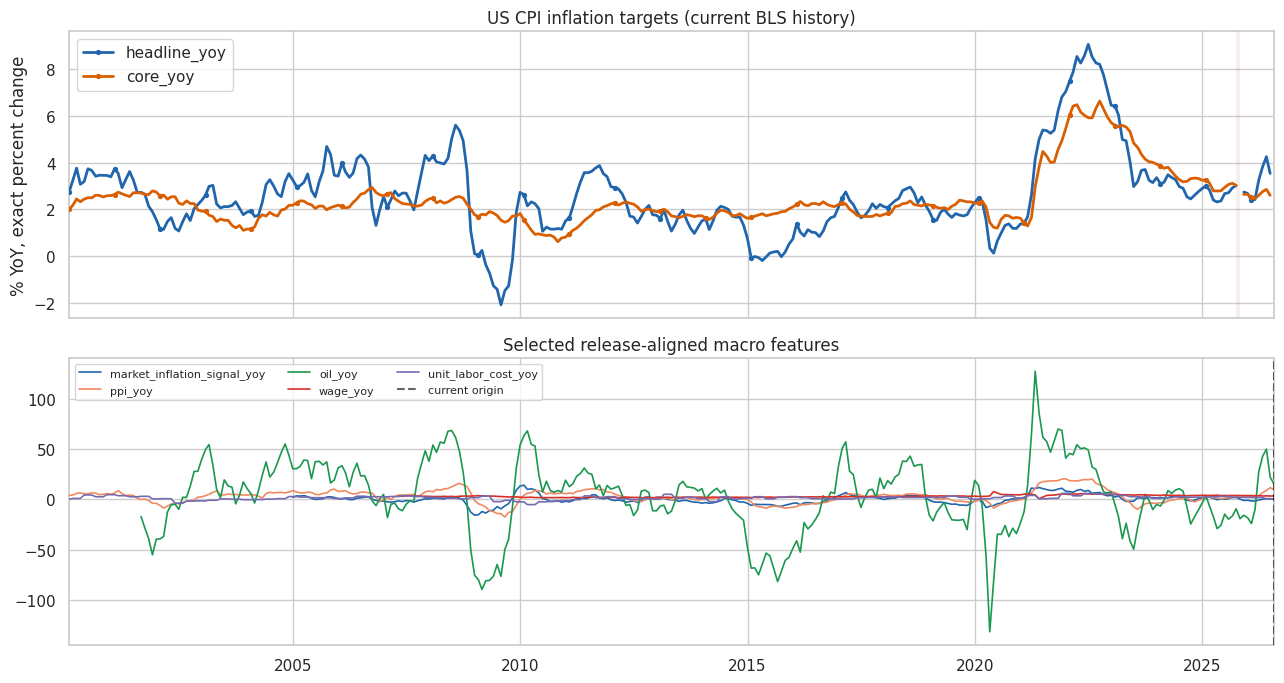

In [ ]:
# 현재 월의 일·주 자료가 부분월인지, 역사월에 몇 개 관측치를 허용했는지 명시한다.
partial_rows = []
current_period = AS_OF_DATE.to_period("M")
for spec in FEATURE_SPECS:
    if spec.key not in raw_series or spec.frequency not in ("daily", "weekly") or spec.release_lag_months != 0:
        continue
    last_obs = raw_series[spec.key].dropna().index.max()
    same_month = last_obs.to_period("M") == current_period
    month_end = AS_OF_DATE.to_period("M").to_timestamp("M")
    completed_observations = HIGH_FREQUENCY_SESSION_COUNT_BY_KEY.get(spec.key, 0)
    partial = bool(AS_OF_DATE < month_end or not same_month)
    calendar_coverage_fraction = (
        float(min(int(last_obs.day), month_end.day) / month_end.day)
        if same_month else 0.0
    )
    partial_rows.append({
        "key": spec.key,
        "last_raw_observation": str(last_obs.date()),
        "current_month_completed_observations": completed_observations,
        "historical_observations_allowed_per_month": completed_observations,
        "protocol_matches_live_information_count": True,
        "current_month_partial": partial,
        "calendar_coverage_fraction": min(calendar_coverage_fraction, 1.0),
    })

partial_month_audit = pd.DataFrame(partial_rows)
display(partial_month_audit)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
target_plot = targets.reindex(
    pd.date_range(max(pd.Timestamp("2000-01-31"), targets.index.min()),
                  last_target_month, freq="ME")
)[TARGET_COLUMNS]
target_colors = {"headline_yoy": "#2166ac", "core_yoy": "#d95f02"}
for target in TARGET_COLUMNS:
    y = target_plot[target].to_numpy(dtype=float)
    # Explicit masked-array rendering avoids silently compressing gaps and makes
    # isolated finite observations visible through sparse annual markers.
    axes[0].plot(
        target_plot.index.to_pydatetime(),
        np.ma.masked_invalid(y),
        color=target_colors[target],
        lw=2.0,
        marker="o",
        markevery=12,
        ms=2.8,
        label=target,
        zorder=5,
    )
for gap_month in target_gap_months:
    if gap_month >= target_plot.index.min():
        axes[0].axvspan(
            (gap_month - pd.offsets.MonthBegin(1)).to_pydatetime(),
            gap_month.to_pydatetime(),
            color="#b2182b",
            alpha=0.08,
            lw=0,
            zorder=1,
        )
axes[0].set_title("US CPI inflation targets (current BLS history)")
axes[0].set_ylabel("% YoY, exact percent change")
axes[0].legend()
axes[0].grid(True, zorder=0)
feature_plot_keys = [
    c for c in [
        "market_inflation_signal_yoy", "ppi_yoy", "oil_yoy",
        "wage_yoy", "unit_labor_cost_yoy",
    ]
    if c in feature_panel
]
feature_colors = {
    "market_inflation_signal_yoy": "#2166ac",
    "ppi_yoy": "#ef8a62",
    "oil_yoy": "#1a9850",
    "wage_yoy": "#d73027",
    "unit_labor_cost_yoy": "#756bb1",
}
if feature_plot_keys:
    for key in feature_plot_keys:
        series = feature_panel[key].loc["2000":]
        axes[1].plot(
            series.index.to_pydatetime(),
            np.ma.masked_invalid(series.to_numpy(dtype=float)),
            color=feature_colors[key],
            lw=1.2,
            label=key,
            zorder=3,
        )
else:
    axes[1].text(
        0.5, 0.5, "No optional macro series is available",
        ha="center", va="center", transform=axes[1].transAxes,
    )
axes[1].set_title("Selected release-aligned macro features")
axes[1].axvline(
    current_origin.to_pydatetime(),
    color="black", ls="--", alpha=.6, label="current origin", zorder=4,
)
feature_plot_start = max(pd.Timestamp("2000-01-31"), feature_panel.index.min())
shared_start = min(target_plot.index.min(), feature_plot_start)
shared_end = max(last_target_month, feature_panel.index.max(), current_origin)
axes[1].set_xlim(shared_start.to_pydatetime(), shared_end.to_pydatetime())
axes[1].xaxis.set_major_locator(mdates.YearLocator(base=5))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1].legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()


## 5. 인과적 feature와 Chronos의 결측·미래 공변량 정책

origin \(O\)에서 CPI 표적은 \(O-1\)까지만 사용하고, 설명변수는 발표달력상 \(O\)에
알 수 있는 값까지만 허용한다. Chronos-2 입력은 모든 origin에서 같은 360개월 달력과
같은 covariate key를 유지한다.

- 표적의 내부 결측은 `NaN`으로 보존해 Chronos-2 native mask에 전달
- 과거 covariate 결측도 중앙값으로 덮지 않고 mask로 보존
- 거시 covariate는 \(h=1\) issue-month의 실제 사용 가능값만 제공
- \(h=2\ldots13\) 거시값은 `NaN`; 미래 실현치나 AR 경로를 known-future로 위장하지 않음
- 월 sin/cos만 모든 horizon에서 실제로 알려진 future covariate

AR(1) 함수는 조건부 scenario 진단에만 남아 있으며 운영 Chronos 입력에는 쓰지 않는다.


In [ ]:
TARGET_LAGS = (1, 2, 3, 6, 12)


def origin_feature_row(
    origin: pd.Timestamp,
    target_df: pd.DataFrame,
    panel: pd.DataFrame,
    include_macro: bool,
) -> pd.Series:
    origin = pd.Timestamp(origin).to_period("M").to_timestamp(how="end").normalize()
    row = {}
    for target in TARGET_COLUMNS:
        for lag in TARGET_LAGS:
            row[f"{target}_lag{lag}"] = target_df[target].get(month_add(origin, -lag), np.nan)
    row["month_sin"] = math.sin(2 * math.pi * origin.month / 12)
    row["month_cos"] = math.cos(2 * math.pi * origin.month / 12)
    if include_macro:
        for col in panel.columns:
            row[col] = panel[col].get(origin, np.nan)
    return pd.Series(row, dtype=float)


def fit_causal_ar1_path(s: pd.Series, origin: pd.Timestamp, horizon: int) -> np.ndarray:
    # Scenario-only helper. Operational Chronos never treats this estimated path as known future.
    origin = pd.Timestamp(origin).to_period("M").to_timestamp(how="end").normalize()
    hist = calendarize_period_end(s.loc[:origin].astype(float), "monthly")
    finite = hist.dropna()
    if finite.empty:
        return np.full(horizon, np.nan)
    x0 = float(hist.get(origin, np.nan))
    if not np.isfinite(x0):
        return np.full(horizon, np.nan)
    if len(finite) < 24:
        return np.repeat(x0, horizon)
    aligned = pd.concat(
        [
            lag_by_calendar(hist, "monthly", 1).rename("lag"),
            hist.rename("now"),
        ],
        axis=1,
    ).dropna()
    if len(aligned) < 18:
        return np.repeat(x0, horizon)
    X = np.c_[np.ones(len(aligned)), aligned["lag"].to_numpy()]
    y = aligned["now"].to_numpy()
    intercept, phi = np.linalg.lstsq(X, y, rcond=None)[0]
    phi = float(np.clip(phi, -0.98, 0.98))
    lo, hi = finite.quantile([0.01, 0.99]).to_numpy()
    path = [x0]
    for _ in range(1, horizon):
        path.append(float(np.clip(intercept + phi * path[-1], lo, hi)))
    return np.asarray(path, dtype=np.float32)


CHRONOS_PANEL_FEATURES = tuple(sorted(map(str, feature_panel.columns)))
CHRONOS_CALENDAR_FEATURES = ("calendar_month_sin", "calendar_month_cos")
CHRONOS_PAST_KEYS = CHRONOS_PANEL_FEATURES + CHRONOS_CALENDAR_FEATURES
CHRONOS_FUTURE_KEYS = CHRONOS_PAST_KEYS
CHRONOS_FEATURE_SCHEMA_SHA = hashlib.sha256(
    json.dumps(
        {
            "past": CHRONOS_PAST_KEYS,
            "future": CHRONOS_FUTURE_KEYS,
            "target_gap_policy": "native_nan_mask",
            "future_policy": "macro_h1_issue_month_only_else_nan+calendar_known",
        },
        sort_keys=True,
    ).encode("utf-8")
).hexdigest()


def causal_robust_stats(values: np.ndarray) -> Tuple[float, float]:
    finite = np.asarray(values, dtype=float)
    finite = finite[np.isfinite(finite)]
    if finite.size == 0:
        return 0.0, 1.0
    center = float(np.median(finite))
    q25, q75 = np.quantile(finite, [0.25, 0.75])
    scale = float(q75 - q25)
    if not np.isfinite(scale) or scale < 1e-8:
        scale = float(np.std(finite))
    if not np.isfinite(scale) or scale < 1e-8:
        scale = 1.0
    return center, scale


def make_chronos_input(
    origin: pd.Timestamp,
    target_df: pd.DataFrame,
    panel: pd.DataFrame,
    horizon: int,
    context_length: int,
    min_observed: Optional[int] = None,
) -> Tuple[dict, dict]:
    origin = pd.Timestamp(origin).to_period("M").to_timestamp(how="end").normalize()
    min_observed = CFG.min_history if min_observed is None else int(min_observed)
    context_end = month_add(origin, -1)
    context_index = pd.date_range(end=context_end, periods=context_length, freq="ME")
    target_ctx = (
        target_df.reindex(context_index)[TARGET_COLUMNS]
        .replace([np.inf, -np.inf], np.nan)
        .astype(np.float32)
    )
    if not target_ctx.iloc[-1].notna().all():
        raise ValueError(f"Target incomplete at origin-1: {origin.date()}")
    observed_counts = target_ctx.notna().sum()
    insufficient = observed_counts[observed_counts < min_observed]
    if not insufficient.empty:
        raise ValueError(
            f"Insufficient observed target history at {origin.date()}: "
            f"{insufficient.astype(int).to_dict()}"
        )

    past_covariates: Dict[str, np.ndarray] = {}
    future_covariates: Dict[str, np.ndarray] = {}
    for col in CHRONOS_PANEL_FEATURES:
        if col in panel:
            raw_past = (
                pd.to_numeric(panel[col].reindex(context_index), errors="coerce")
                .replace([np.inf, -np.inf], np.nan)
                .to_numpy(dtype=float)
            )
            current_value = pd.to_numeric(
                pd.Series([panel[col].get(origin, np.nan)]), errors="coerce"
            ).iloc[0]
        else:
            raw_past = np.full(context_length, np.nan)
            current_value = np.nan
        center, scale = causal_robust_stats(raw_past)
        # Preserve internal missingness for the native Chronos mask.
        past_covariates[col] = ((raw_past - center) / scale).astype(np.float32)
        future = np.full(horizon, np.nan, dtype=np.float32)
        if np.isfinite(current_value):
            future[0] = np.float32((float(current_value) - center) / scale)
        future_covariates[col] = future

    past_month = context_index.month.to_numpy()
    future_index = pd.date_range(origin, periods=horizon, freq="ME")
    future_month = future_index.month.to_numpy()
    past_covariates["calendar_month_sin"] = np.sin(
        2 * np.pi * past_month / 12
    ).astype(np.float32)
    past_covariates["calendar_month_cos"] = np.cos(
        2 * np.pi * past_month / 12
    ).astype(np.float32)
    future_covariates["calendar_month_sin"] = np.sin(
        2 * np.pi * future_month / 12
    ).astype(np.float32)
    future_covariates["calendar_month_cos"] = np.cos(
        2 * np.pi * future_month / 12
    ).astype(np.float32)
    assert tuple(past_covariates) == CHRONOS_PAST_KEYS
    assert tuple(future_covariates) == CHRONOS_FUTURE_KEYS

    audit = {
        "origin": str(origin.date()),
        "context_start": str(context_index.min().date()),
        "context_end": str(context_index.max().date()),
        "context_months": int(len(context_index)),
        "observed_target_counts": observed_counts.astype(int).to_dict(),
        "missing_target_months": {
            col: [str(x.date()) for x in target_ctx.index[target_ctx[col].isna()]]
            for col in TARGET_COLUMNS
        },
        "feature_schema_sha256": CHRONOS_FEATURE_SCHEMA_SHA,
        "target_gap_policy": "native_nan_mask",
        "future_covariate_policy": (
            "macro_h1_issue_month_only_else_nan+calendar_known_all_horizons"
        ),
    }
    item = {
        "target": target_ctx.to_numpy(dtype=np.float32).T,
        "past_covariates": past_covariates,
        "future_covariates": future_covariates,
    }
    return item, audit


# Input-policy regression tests; synthetic data never enter forecast results.
toy_idx = pd.date_range("2000-01-31", periods=240, freq="ME")
toy_targets = pd.DataFrame(
    {
        "headline_yoy": 2 + np.sin(np.arange(240) / 12),
        "core_yoy": 2 + np.cos(np.arange(240) / 15),
    },
    index=toy_idx,
)
toy_targets.loc[toy_idx[-50], "headline_yoy"] = np.nan
toy_panel = pd.DataFrame(
    {
        col: np.sin(np.arange(240) / (7 + (i % 11)))
        for i, col in enumerate(CHRONOS_PANEL_FEATURES)
    },
    index=toy_idx,
)
toy_origin = toy_idx[-1]
_item, _audit = make_chronos_input(
    toy_origin, toy_targets, toy_panel, 12, 220, 180
)
assert _item["target"].shape == (2, 220)
assert np.isnan(_item["target"][0]).sum() == 1
assert tuple(_item["past_covariates"]) == CHRONOS_PAST_KEYS
assert tuple(_item["future_covariates"]) == CHRONOS_FUTURE_KEYS
for _key in CHRONOS_PANEL_FEATURES:
    assert np.isnan(_item["future_covariates"][_key][1:]).all()
for _key in CHRONOS_CALENDAR_FEATURES:
    assert np.isfinite(_item["future_covariates"][_key]).all()

_row = origin_feature_row(toy_origin, toy_targets, toy_panel, include_macro=True)
assert _row["headline_yoy_lag1"] == toy_targets.loc[month_add(toy_origin, -1), "headline_yoy"]
if CHRONOS_PANEL_FEATURES:
    _first = CHRONOS_PANEL_FEATURES[0]
    _before = fit_causal_ar1_path(toy_panel[_first], toy_origin, 12)
    _mutated = toy_panel.copy()
    _mutated.loc[_mutated.index > toy_origin, _first] = 1e9
    _after = fit_causal_ar1_path(_mutated[_first], toy_origin, 12)
    assert np.allclose(_before, _after, equal_nan=True)
print("Chronos fixed-grid/native-NaN input tests: PASS")


Chronos fixed-grid/native-NaN input tests: PASS


## 6. 순차적 고전 기준모형

- **Persistence**: 마지막 발표 YoY를 모든 horizon에 유지
- **AR-Ridge**: 두 CPI의 1·2·3·6·12개월 lag + 계절항
- **Macro-Ridge**: AR 정보 + 발표시차 정렬 거시패널
- **Coherent-MoM-Ridge**: 두 NSA CPI의 월별 로그변화를 함께 재귀예측해 가격지수 경로를 만든 뒤 \(P_t/P_{t-12}-1\)로 YoY를 재구성. 알려진 base effect와 가격지수 항등식을 강제한다.

각 origin·horizon에서 학습 label의 표적월이 반드시 origin보다 과거인 행만 쓴다. median과 RobustScaler는 그 fold의 학습행에만 적합한다.

백테스트 origin은 두 CPI 표적의 **13개월 실현창 전체가 유한한 경우에만** 사전 선택한다. 결측 실현치를 행 단위로 사후 삭제하지 않으며, 한 달이라도 비어 있으면 그 결측월을 가로지르는 origin 전체를 제외해 모델별 평가표본을 동일하게 유지한다.


In [ ]:
def _prediction_vector(raw_prediction) -> np.ndarray:
    """Normalize scalar, single-output, and multi-output predictions to (n_targets,)."""
    prediction = np.asarray(raw_prediction, dtype=float)
    if prediction.ndim == 0:
        return prediction.reshape(1)
    if prediction.ndim == 1:
        return prediction.reshape(-1)
    if prediction.shape[0] != 1:
        raise ValueError(
            f"Expected one prediction row, received shape {prediction.shape}"
        )
    return prediction[0].reshape(-1)


assert _prediction_vector(1.5).shape == (1,)
assert _prediction_vector(np.array([1.5])).shape == (1,)
assert _prediction_vector(np.array([[1.5]])).shape == (1,)
assert _prediction_vector(np.array([[1.5, 2.5]])).shape == (2,)


def fit_fold_ridge(
    X_train: pd.DataFrame,
    Y_train: pd.DataFrame,
    x_pred: pd.Series,
    alpha: float,
) -> np.ndarray:
    common_cols = X_train.columns
    x = x_pred.reindex(common_cols).to_numpy(dtype=float)[None, :]
    X = X_train.to_numpy(dtype=float)
    Y = Y_train.to_numpy(dtype=float)

    train_missing = ~np.isfinite(X)
    pred_missing = ~np.isfinite(x)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        med = np.nanmedian(X, axis=0)
    med[~np.isfinite(med)] = 0.0
    X = np.where(np.isfinite(X), X, med)
    x = np.where(np.isfinite(x), x, med)
    # Preserve the information that a vintage feature was absent; do not disguise it as an observation.
    # Always include a missingness indicator for every feature so a pattern
    # appearing only at prediction time still has a fixed, interpretable column.
    X = np.c_[X, train_missing.astype(float)]
    x = np.c_[x, pred_missing.astype(float)]

    scaler = RobustScaler(quantile_range=(25, 75))
    Xs = scaler.fit_transform(X)
    xs = scaler.transform(x)
    model = Ridge(alpha=alpha, fit_intercept=True)
    model.fit(Xs, Y)
    return _prediction_vector(model.predict(xs))


MOM_LAGS = (1, 2, 3, 6, 12)
CLASSICAL_MODELS = ("Persistence", "AR_Ridge", "Macro_Ridge", "Coherent_MoM_Ridge")
COHERENT_PATH_CACHE: Dict[pd.Timestamp, np.ndarray] = {}


def mom_feature_row(target_month: pd.Timestamp, mom_df: pd.DataFrame) -> pd.Series:
    row = {}
    for col in mom_df.columns:
        for lag in MOM_LAGS:
            row[f"{col}_lag{lag}"] = mom_df[col].get(month_add(target_month, -lag), np.nan)
    for month in range(1, 13):
        row[f"month_{month:02d}"] = float(pd.Timestamp(target_month).month == month)
    return pd.Series(row, dtype=float)


def coherent_mom_yoy_path(
    origin: pd.Timestamp,
    horizon: int,
    levels: pd.DataFrame,
) -> np.ndarray:
    # Forecast calendar-month CPI changes recursively, then reconstruct exact YoY.
    # A missing historical base invalidates only its affected target/horizon cell.
    origin = pd.Timestamp(origin).to_period("M").to_timestamp(how="end").normalize()
    level_cols = ["headline_level", "core_level"]
    lv = calendarize_period_end(levels[level_cols], "monthly")
    log_levels = np.log(lv.where(lv > 0))
    known_log = log_levels.loc[:month_add(origin, -1)].copy()
    mom = 100.0 * (
        known_log - lag_by_calendar(known_log, "monthly", 1)
    )
    mom = mom.rename(
        columns={"headline_level": "headline_mom", "core_level": "core_mom"}
    )

    X_rows, Y_rows, train_months = [], [], []
    for target_month in mom.index[mom.index < origin]:
        y = mom.loc[target_month, ["headline_mom", "core_mom"]]
        if y.notna().all():
            X_rows.append(mom_feature_row(target_month, mom))
            Y_rows.append(y)
            train_months.append(target_month)
    if len(X_rows) < 120:
        return np.full((horizon, len(TARGET_COLUMNS)), np.nan)

    X_train = pd.DataFrame(X_rows, index=train_months)
    Y_train = pd.DataFrame(
        Y_rows, index=train_months, columns=["headline_mom", "core_mom"]
    )
    recursive_mom = mom.copy()
    forecast_log = known_log.copy()
    yoy_path = []
    for step in range(horizon):
        target_month = month_add(origin, step)
        x = mom_feature_row(target_month, recursive_mom).reindex(X_train.columns)
        pred_mom = fit_fold_ridge(
            X_train, Y_train, x, alpha=CFG.ridge_alpha_ar
        )
        recursive_mom.loc[
            target_month, ["headline_mom", "core_mom"]
        ] = pred_mom

        previous_month = month_add(target_month, -1)
        previous_log = (
            forecast_log.reindex([previous_month])[level_cols]
            .iloc[0].to_numpy(dtype=float)
        )
        new_log = np.where(
            np.isfinite(previous_log) & np.isfinite(pred_mom),
            previous_log + pred_mom / 100.0,
            np.nan,
        )
        forecast_log.loc[target_month, level_cols] = new_log
        base_month = month_add(target_month, -12)
        base_log = (
            forecast_log.reindex([base_month])[level_cols]
            .iloc[0].to_numpy(dtype=float)
        )
        yoy = np.full(len(TARGET_COLUMNS), np.nan)
        ok = np.isfinite(new_log) & np.isfinite(base_log)
        yoy[ok] = 100.0 * (np.exp(new_log[ok] - base_log[ok]) - 1.0)
        yoy_path.append(yoy)

    out = np.asarray(yoy_path, dtype=float)
    assert out.shape == (horizon, len(TARGET_COLUMNS))
    return out


def classical_forecast_at_origin(
    origin: pd.Timestamp,
    horizon: int,
    model_name: str,
    target_df: pd.DataFrame,
    panel: pd.DataFrame,
) -> np.ndarray:
    origin = pd.Timestamp(origin).to_period("M").to_timestamp("M")
    if model_name == "Persistence":
        last = target_df.reindex([month_add(origin, -1)])[TARGET_COLUMNS].iloc[0].to_numpy(dtype=float)
        return last

    if model_name == "Coherent_MoM_Ridge":
        cache_key = pd.Timestamp(origin).to_period("M").to_timestamp("M")
        if cache_key not in COHERENT_PATH_CACHE:
            COHERENT_PATH_CACHE[cache_key] = coherent_mom_yoy_path(
                cache_key, CFG.horizon, target_levels
            )
        return COHERENT_PATH_CACHE[cache_key][horizon - 1]

    include_macro = model_name == "Macro_Ridge"
    alpha = CFG.ridge_alpha_macro if include_macro else CFG.ridge_alpha_ar
    earliest = max(target_df.dropna().index.min() + pd.offsets.MonthEnd(12),
                   panel.index.min() + pd.offsets.MonthEnd(12))
    latest_train_origin = month_add(origin, -horizon)
    if latest_train_origin < earliest:
        return np.full(len(TARGET_COLUMNS), np.nan)
    train_origins = pd.date_range(earliest, latest_train_origin, freq="ME")

    X_rows, Y_rows, used_origins = [], [], []
    for tau in train_origins:
        target_month = month_add(tau, horizon - 1)
        # Hard causal invariant: every fitted label was already realized before origin.
        assert target_month < origin
        y = target_df.reindex([target_month])[TARGET_COLUMNS].iloc[0]
        if not y.notna().all():
            continue
        X_rows.append(origin_feature_row(tau, target_df, panel, include_macro))
        Y_rows.append(y)
        used_origins.append(tau)

    if len(X_rows) < 72:
        return np.full(len(TARGET_COLUMNS), np.nan)
    X_train = pd.DataFrame(X_rows, index=used_origins)
    Y_train = pd.DataFrame(Y_rows, columns=TARGET_COLUMNS)
    x_pred = origin_feature_row(origin, target_df, panel, include_macro)
    return fit_fold_ridge(X_train, Y_train, x_pred, alpha=alpha)


def choose_backtest_origins(target_df: pd.DataFrame, n_origins: int, horizon: int) -> pd.DatetimeIndex:
    complete = target_df[TARGET_COLUMNS].dropna().index
    last_origin = month_add(complete.max(), -(horizon - 1))
    candidate = pd.date_range(complete.min() + pd.offsets.MonthEnd(CFG.min_history),
                              last_origin, freq="ME")
    eligible = []
    excluded = []
    for origin in candidate:
        realized_months = pd.date_range(
            origin, month_add(origin, horizon - 1), freq="ME"
        )
        realized = target_df.reindex(realized_months)[TARGET_COLUMNS]
        realized_finite = pd.Series(
            np.isfinite(realized.to_numpy(dtype=float)).all(axis=1),
            index=realized_months,
        )
        actuals_complete = (
            len(realized) == horizon
            and bool(realized_finite.all())
        )
        history = target_df.loc[:month_add(origin, -1), TARGET_COLUMNS]
        complete_history_months = int(
            np.isfinite(history.to_numpy(dtype=float)).all(axis=1).sum()
        )
        enough_history = complete_history_months >= CFG.min_history
        if actuals_complete and enough_history:
            eligible.append(origin)
        else:
            reasons = []
            if not actuals_complete:
                reasons.append("incomplete_realized_window")
            if not enough_history:
                reasons.append("insufficient_history")
            excluded.append({
                "origin": origin,
                "reason": "+".join(reasons),
                "missing_realized_months": ",".join(
                    stamp.strftime("%Y-%m")
                    for stamp in realized_finite.index[~realized_finite]
                ),
                "complete_history_months": complete_history_months,
            })
    eligible = pd.DatetimeIndex(eligible)
    if excluded:
        print(
            f"Excluded {len(excluded)} candidate origin(s) with an incomplete "
            "realized target window or insufficient complete history."
        )
        display(pd.DataFrame(excluded).tail(20))
    if len(eligible) < n_origins:
        raise RuntimeError(
            f"Only {len(eligible)} fully evaluable origins, need {n_origins}. "
            "Inspect target_gap_months or lower N_ORIGINS explicitly; incomplete "
            "actuals are never silently admitted."
        )
    selected = eligible[-n_origins:]
    for origin in selected:
        realized_months = pd.date_range(origin, month_add(origin, horizon - 1), freq="ME")
        assert np.isfinite(
            target_df.reindex(realized_months)[TARGET_COLUMNS].to_numpy(dtype=float)
        ).all()
    return selected


backtest_origins = choose_backtest_origins(targets, N_ORIGINS, CFG.horizon)
print("Backtest:", backtest_origins.min().date(), "through", backtest_origins.max().date())


def run_classical_backtest(origins: Sequence[pd.Timestamp]) -> pd.DataFrame:
    records = []
    for origin in tqdm(origins, desc="Classical expanding-window backtest"):
        for h in range(1, CFG.horizon + 1):
            target_month = month_add(origin, h - 1)
            actual = targets.reindex([target_month])[TARGET_COLUMNS].iloc[0]
            for model_name in CLASSICAL_MODELS:
                pred = classical_forecast_at_origin(origin, h, model_name, targets, feature_panel)
                for j, target in enumerate(TARGET_COLUMNS):
                    records.append({
                        "origin": origin,
                        "target_month": target_month,
                        "horizon": h,
                        "target": target,
                        "model": model_name,
                        "actual": float(actual[target]),
                        "prediction": float(pred[j]),
                        "q10": np.nan,
                        "q50": float(pred[j]),
                        "q90": np.nan,
                    })
    return pd.DataFrame(records)


bt_classical = run_classical_backtest(backtest_origins)
if not (bt_classical["target_month"] < current_origin).all():
    raise RuntimeError("Backtest leakage: at least one target month is not strictly historical.")
bad_actuals = bt_classical.loc[
    ~np.isfinite(bt_classical["actual"]),
    ["origin", "target_month", "horizon", "target", "actual"],
].drop_duplicates()
if not bad_actuals.empty:
    display(bad_actuals.head(30))
    raise RuntimeError(
        "Non-finite realized CPI entered the backtest despite the eligibility audit. "
        "Inspect the displayed origin/target months and rerun the target-data cells."
    )
display(bt_classical.head())


# Coherent-path gap propagation test: one missing base must not erase the full path.
_ci = pd.date_range("2000-01-31", periods=250, freq="ME")
_coherent_levels = pd.DataFrame(
    {
        "headline_level": 100 * np.exp(0.0020 * np.arange(250)),
        "core_level": 110 * np.exp(0.0015 * np.arange(250)),
    },
    index=_ci,
)
_coherent_origin = _ci[220]
_base_gap = month_add(_coherent_origin, -9)  # affects h=4 target via t-12
_coherent_levels.loc[_base_gap, :] = np.nan
_coherent_test_path = coherent_mom_yoy_path(
    _coherent_origin, CFG.horizon, _coherent_levels
)
assert _coherent_test_path.shape == (CFG.horizon, 2)
assert np.isnan(_coherent_test_path[3]).all()
assert np.isfinite(_coherent_test_path[4]).all()
print("Classical calendar-gap propagation tests: PASS")


Excluded 9 candidate origin(s) with an incomplete realized target window or insufficient complete history.


,origin,reason,missing_realized_months,complete_history_months
0,2024-10-31,incomplete_realized_window,2025-10,405
1,2024-11-30,incomplete_realized_window,2025-10,406
2,2024-12-31,incomplete_realized_window,2025-10,407
3,2025-01-31,incomplete_realized_window,2025-10,408
4,2025-02-28,incomplete_realized_window,2025-10,409
5,2025-03-31,incomplete_realized_window,2025-10,410
6,2025-04-30,incomplete_realized_window,2025-10,411
7,2025-05-31,incomplete_realized_window,2025-10,412
8,2025-06-30,incomplete_realized_window,2025-10,413


Backtest: 2017-10-31 through 2024-09-30


Classical expanding-window backtest:   0%|          | 0/84 [00:00<?, ?it/s]

,origin,target_month,horizon,target,model,actual,prediction,q10,q50,q90
0,2017-10-31,2017-10-31,1,headline_yoy,Persistence,2.041129,2.232964,NaN,2.232964,NaN
1,2017-10-31,2017-10-31,1,core_yoy,Persistence,1.773548,1.692592,NaN,1.692592,NaN
2,2017-10-31,2017-10-31,1,headline_yoy,AR_Ridge,2.041129,2.256492,NaN,2.256492,NaN
3,2017-10-31,2017-10-31,1,core_yoy,AR_Ridge,1.773548,1.726728,NaN,1.726728,NaN
4,2017-10-31,2017-10-31,1,headline_yoy,Macro_Ridge,2.041129,2.155909,NaN,2.155909,NaN


Classical calendar-gap propagation tests: PASS


## 7. Chronos-2 zero-shot 다변량 후보

Chronos-2는 headline/core를 2변량 표적으로 함께 예측하고 동일한 인과적 covariate
schema를 공유한다. 작은 거시표본에서 foundation model 전체를 fine-tune하지 않고
zero-shot 후보로만 평가한다.

검증한 model commit `29ec3766d36d6f73f0696f85560a422f50e8498c`를 고정한다.
실제 모델을 불러온 직후 내부 target `NaN`과 future-covariate `NaN` mask를 처리해
유한하고 정렬된 quantile을 반환하는지 runtime probe한다. 호출 실패는 0이나 합성값으로
바꾸지 않고 고정 schema의 빈 결과와 오류 로그로 남긴다.

Chronos를 승자로 가정하지 않는다. DEV common grid의 각 horizon band에서 단순모형보다
사전 임계값 이상 개선되고, origin-block bootstrap과 100% coverage를 통과해야만 채택된다.
또한 live 결측 패턴을 모사한 historical gap-stress 결과를 배포 robustness 감사로 남긴다.


In [ ]:
CHRONOS_MODEL_SHA = CFG.model_revision
chronos_pipeline = None
chronos_load_error = None

if CFG.run_chronos:
    try:
        from chronos import BaseChronosPipeline, Chronos2Pipeline

        # Verify that the pinned revision exists before loading.
        remote_sha = model_info(CFG.model_id, revision=CFG.model_revision).sha
        if remote_sha != CFG.model_revision:
            print("Resolved model commit:", remote_sha, "| requested revision:", CFG.model_revision)
        device_map = "cuda" if torch.cuda.is_available() else "cpu"
        chronos_pipeline: Chronos2Pipeline = BaseChronosPipeline.from_pretrained(
            CFG.model_id,
            revision=CFG.model_revision,
            device_map=device_map,
        )
        print("Chronos-2 loaded | pinned revision:", CHRONOS_MODEL_SHA, "| device:", device_map)
    except Exception as exc:
        chronos_load_error = f"{type(exc).__name__}: {exc}"
        print("Chronos-2 load FAILED. Results remain unavailable; no synthetic fallback.")
        print(chronos_load_error)


config.json:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  478MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Chronos-2 loaded | pinned revision: 29ec3766d36d6f73f0696f85560a422f50e8498c | device: cuda


In [ ]:
CHRONOS_RECORD_COLUMNS = [
    "origin", "target_month", "horizon", "target", "model",
    "actual", "prediction", "q10", "q50", "q90",
]
CHRONOS_ERROR_COLUMNS = ["origin", "stage", "retry_depth", "error"]


def empty_chronos_records() -> pd.DataFrame:
    return pd.DataFrame(columns=CHRONOS_RECORD_COLUMNS)


def empty_chronos_errors() -> pd.DataFrame:
    return pd.DataFrame(columns=CHRONOS_ERROR_COLUMNS)


def tensor_to_numpy(x) -> np.ndarray:
    if hasattr(x, "detach"):
        x = x.detach().float().cpu().numpy()
    return np.asarray(x)


def normalize_quantile_shape(
    q: np.ndarray,
    n_targets: int,
    horizon: int,
    n_q: int,
) -> np.ndarray:
    q = np.asarray(q)
    if q.ndim == 2 and n_targets == 1:
        q = q[None, :, :]
    if q.shape == (n_targets, horizon, n_q):
        return q
    if q.shape == (n_targets, n_q, horizon):
        return np.transpose(q, (0, 2, 1))
    raise ValueError(f"Unexpected Chronos quantile shape {q.shape}")


def clone_chronos_item(item: dict) -> dict:
    return {
        "target": item["target"].copy(),
        "past_covariates": {
            k: v.copy() for k, v in item["past_covariates"].items()
        },
        "future_covariates": {
            k: v.copy() for k, v in item["future_covariates"].items()
        },
    }


def probe_chronos_native_nan(origin: pd.Timestamp) -> Tuple[bool, str]:
    if chronos_pipeline is None:
        return False, chronos_load_error or "pipeline unavailable"
    try:
        item, _ = make_chronos_input(
            origin, targets, feature_panel,
            CFG.horizon, CFG.context_length, CFG.min_history,
        )
        probe = clone_chronos_item(item)
        observed = np.flatnonzero(np.isfinite(probe["target"][0]))
        observed = observed[observed < probe["target"].shape[1] - 1]
        if len(observed) < 24:
            return False, "not enough observed points for internal-gap probe"
        probe["target"][0, observed[-24]] = np.nan
        q_batch, _ = chronos_pipeline.predict_quantiles(
            [probe],
            prediction_length=CFG.horizon,
            quantile_levels=list(CFG.quantiles),
        )
        q = normalize_quantile_shape(
            tensor_to_numpy(q_batch[0]),
            len(TARGET_COLUMNS), CFG.horizon, len(CFG.quantiles),
        )
        if not np.isfinite(q).all():
            return False, "non-finite output from native-NaN probe"
        if np.any(q[..., 0] > q[..., 1]) or np.any(q[..., 1] > q[..., 2]):
            return False, "crossed quantiles in native-NaN probe"
        return True, "native internal-NaN mask probe passed"
    except Exception as exc:
        return False, f"{type(exc).__name__}: {exc}"


CHRONOS_NATIVE_NAN_SUPPORTED, CHRONOS_NAN_PROBE_MESSAGE = (
    probe_chronos_native_nan(backtest_origins[-1])
)
print("Chronos native-NaN compatibility:", CHRONOS_NATIVE_NAN_SUPPORTED)
print(CHRONOS_NAN_PROBE_MESSAGE)


def run_chronos_for_origins(
    origins: Sequence[pd.Timestamp],
    include_actual: bool = True,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    if chronos_pipeline is None or not CHRONOS_NATIVE_NAN_SUPPORTED:
        err = empty_chronos_errors()
        err.loc[len(err)] = {
            "origin": None,
            "stage": "availability",
            "retry_depth": 0,
            "error": chronos_load_error or CHRONOS_NAN_PROBE_MESSAGE,
        }
        return empty_chronos_records(), err

    prepared, prep_meta, errors = [], [], []
    for origin in origins:
        try:
            item, audit = make_chronos_input(
                origin, targets, feature_panel,
                CFG.horizon, CFG.context_length, CFG.min_history,
            )
            prepared.append(item)
            prep_meta.append({"origin": pd.Timestamp(origin), "audit": audit})
        except Exception as exc:
            errors.append({
                "origin": str(pd.Timestamp(origin).date()),
                "stage": "prepare",
                "retry_depth": 0,
                "error": f"{type(exc).__name__}: {exc}",
            })

    records = []

    def consume_batch(batch: list, meta_batch: list, retry_depth: int = 0):
        try:
            q_batch, _ = chronos_pipeline.predict_quantiles(
                batch,
                prediction_length=CFG.horizon,
                quantile_levels=list(CFG.quantiles),
            )
            staged = []
            for j, meta in enumerate(meta_batch):
                origin = meta["origin"]
                q = normalize_quantile_shape(
                    tensor_to_numpy(q_batch[j]),
                    len(TARGET_COLUMNS), CFG.horizon, len(CFG.quantiles),
                )
                if not np.isfinite(q).all():
                    raise ValueError(f"Non-finite Chronos quantiles at {origin.date()}")
                if np.any(q[..., 0] > q[..., 1]) or np.any(q[..., 1] > q[..., 2]):
                    raise ValueError(f"Crossed Chronos quantiles at {origin.date()}")
                for target_idx, target in enumerate(TARGET_COLUMNS):
                    for h in range(1, CFG.horizon + 1):
                        target_month = month_add(origin, h - 1)
                        actual = (
                            targets[target].get(target_month, np.nan)
                            if include_actual else np.nan
                        )
                        staged.append({
                            "origin": origin,
                            "target_month": target_month,
                            "horizon": h,
                            "target": target,
                            "model": "Chronos2",
                            "actual": float(actual) if np.isfinite(actual) else np.nan,
                            "prediction": float(q[target_idx, h - 1, 1]),
                            "q10": float(q[target_idx, h - 1, 0]),
                            "q50": float(q[target_idx, h - 1, 1]),
                            "q90": float(q[target_idx, h - 1, 2]),
                        })
            records.extend(staged)
        except Exception as exc:
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            if len(batch) > 1:
                mid = len(batch) // 2
                consume_batch(batch[:mid], meta_batch[:mid], retry_depth + 1)
                consume_batch(batch[mid:], meta_batch[mid:], retry_depth + 1)
            elif meta_batch:
                errors.append({
                    "origin": str(meta_batch[0]["origin"].date()),
                    "stage": "predict_after_recursive_retry",
                    "retry_depth": retry_depth,
                    "error": f"{type(exc).__name__}: {exc}",
                })

    for start in tqdm(
        range(0, len(prepared), CFG.chronos_batch_size),
        desc="Chronos-2 batches",
    ):
        consume_batch(
            prepared[start:start + CFG.chronos_batch_size],
            prep_meta[start:start + CFG.chronos_batch_size],
        )

    record_frame = (
        pd.DataFrame(records, columns=CHRONOS_RECORD_COLUMNS)
        if records else empty_chronos_records()
    )
    error_frame = (
        pd.DataFrame(errors, columns=CHRONOS_ERROR_COLUMNS)
        if errors else empty_chronos_errors()
    )
    return record_frame, error_frame


bt_chronos, chronos_errors = run_chronos_for_origins(
    backtest_origins, include_actual=True
)
CHRONOS_BACKTEST_SUCCESS_RATE = (
    bt_chronos["origin"].nunique() / len(backtest_origins)
    if not bt_chronos.empty else 0.0
)
if not chronos_errors.empty:
    print("Chronos error log:")
    display(chronos_errors)
if not bt_chronos.empty:
    print(f"Chronos origin success rate: {CHRONOS_BACKTEST_SUCCESS_RATE:.1%}")
    display(bt_chronos.head())
else:
    print("No Chronos backtest predictions. Classical pipeline remains available.")


def run_gap_stress_test(origins: Sequence[pd.Timestamp]) -> pd.DataFrame:
    if chronos_pipeline is None or bt_chronos.empty:
        return pd.DataFrame(columns=[
            "origin", "target", "horizon", "abs_q50_shift",
            "interval_width_ratio", "gap_offset_months", "error",
        ])
    rows = []
    # Live gap 2025-10 is eight months behind a 2026-06 context end.
    gap_offset_from_context_end = 8
    for origin in origins:
        try:
            item, _ = make_chronos_input(
                origin, targets, feature_panel,
                CFG.horizon, CFG.context_length, CFG.min_history,
            )
            stressed = clone_chronos_item(item)
            gap_position = stressed["target"].shape[1] - 1 - gap_offset_from_context_end
            stressed["target"][:, gap_position] = np.nan
            q_batch, _ = chronos_pipeline.predict_quantiles(
                [stressed],
                prediction_length=CFG.horizon,
                quantile_levels=list(CFG.quantiles),
            )
            q = normalize_quantile_shape(
                tensor_to_numpy(q_batch[0]),
                len(TARGET_COLUMNS), CFG.horizon, len(CFG.quantiles),
            )
            base = bt_chronos.loc[bt_chronos["origin"].eq(pd.Timestamp(origin))]
            for ti, target in enumerate(TARGET_COLUMNS):
                for h in range(1, CFG.horizon + 1):
                    ref = base.loc[
                        base["target"].eq(target) & base["horizon"].eq(h)
                    ]
                    if ref.empty:
                        continue
                    ref = ref.iloc[0]
                    ref_width = float(ref["q90"] - ref["q10"])
                    stress_width = float(q[ti, h - 1, 2] - q[ti, h - 1, 0])
                    rows.append({
                        "origin": pd.Timestamp(origin),
                        "target": target,
                        "horizon": h,
                        "abs_q50_shift": abs(float(q[ti, h - 1, 1]) - float(ref["q50"])),
                        "interval_width_ratio": (
                            stress_width / ref_width if ref_width > 0 else np.nan
                        ),
                        "gap_offset_months": gap_offset_from_context_end,
                    })
        except Exception as exc:
            rows.append({
                "origin": pd.Timestamp(origin),
                "target": None,
                "horizon": np.nan,
                "abs_q50_shift": np.nan,
                "interval_width_ratio": np.nan,
                "gap_offset_months": gap_offset_from_context_end,
                "error": f"{type(exc).__name__}: {exc}",
            })
    return pd.DataFrame(rows)


_stress_origins = list(backtest_origins[-CFG.gap_stress_origins:])
chronos_gap_stress_audit = run_gap_stress_test(_stress_origins)
if not chronos_gap_stress_audit.empty:
    _stress_shift = chronos_gap_stress_audit["abs_q50_shift"].median()
    _stress_ratio = chronos_gap_stress_audit["interval_width_ratio"].median()
    CHRONOS_GAP_STRESS_PASSED = bool(
        chronos_gap_stress_audit["origin"].nunique() == len(_stress_origins)
        and np.isfinite(_stress_shift)
        and _stress_shift <= CFG.gap_stress_max_median_shift_pp
        and np.isfinite(_stress_ratio)
        and CFG.gap_stress_min_width_ratio <= _stress_ratio <= CFG.gap_stress_max_width_ratio
    )
else:
    _stress_shift = _stress_ratio = np.nan
    CHRONOS_GAP_STRESS_PASSED = False
print(
    "Chronos missing-gap stress:",
    CHRONOS_GAP_STRESS_PASSED,
    "| median |Δq50|=", _stress_shift,
    "| median width ratio=", _stress_ratio,
)


Chronos native-NaN compatibility: True
native internal-NaN mask probe passed


Chronos-2 batches:   0%|          | 0/11 [00:00<?, ?it/s]

Chronos origin success rate: 100.0%


,origin,target_month,horizon,target,model,actual,prediction,q10,q50,q90
0,2017-10-31,2017-10-31,1,headline_yoy,Chronos2,2.041129,2.224841,2.011139,2.224841,2.436990
1,2017-10-31,2017-11-30,2,headline_yoy,Chronos2,2.202583,1.934743,1.658699,1.934743,2.216876
2,2017-10-31,2017-12-31,3,headline_yoy,Chronos2,2.109082,1.901385,1.588832,1.901385,2.234088
3,2017-10-31,2018-01-31,4,headline_yoy,Chronos2,2.070508,1.907619,1.554252,1.907619,2.266014
4,2017-10-31,2018-02-28,5,headline_yoy,Chronos2,2.211795,1.936946,1.540686,1.936946,2.346909


Chronos missing-gap stress: True | median |Δq50|= 0.01213061809539795 | median width ratio= 0.9918979018715413


## 8. Purged split과 DEV-only horizon-band 선택

하나의 전체 평균이 nowcast와 중기전망의 차이를 가리지 않도록 다음 세 band를 분리한다.

- nowcast: \(h=1\)
- near term: \(h=2\ldots6\)
- medium term: \(h=7\ldots13\)

먼저 각 band에서 DEV 동일 grid를 100% 채운 고전모형을 origin 내부 평균 후 origin 간
동일 가중 MAE로 순위화한다. Chronos와 50:50 blend도 같은 셀에서만 비교하며,
Chronos는 1% 개선·bootstrap 승리확률 75%, blend는 0.5%·65%를 넘어야 채택된다.
후보 한 셀이라도 빠지면 쉬운 부분집합에서 이기는 것을 막기 위해 탈락한다.

locked actual을 바꾸거나 행 순서를 섞어도 선택이 변하지 않는 회귀시험을 코드에 포함한다.
locked 결과는 보고만 하며 safety gate나 사후 모형 전환에 쓰지 않는다.


In [ ]:
def assign_time_splits(
    origins: Sequence[pd.Timestamp],
    embargo_origins: int,
) -> Dict[pd.Timestamp, str]:
    unique = pd.DatetimeIndex(sorted(pd.unique(pd.to_datetime(origins))))
    n = len(unique)
    effective_n = n - 2 * embargo_origins
    if effective_n < 15:
        raise ValueError(
            f"Need at least {2 * embargo_origins + 15} origins; got {n}"
        )
    n_dev = max(1, int(np.floor(0.60 * effective_n)))
    n_cal = max(1, int(np.floor(0.20 * effective_n)))
    n_test = effective_n - n_dev - n_cal
    if n_test < 1:
        raise ValueError("No locked-test origins remain")
    dev_end = n_dev
    cal_start = dev_end + embargo_origins
    cal_end = cal_start + n_cal
    test_start = cal_end + embargo_origins
    test_end = test_start + n_test
    assert test_end == n
    out = {origin: "purged" for origin in unique}
    for origin in unique[:dev_end]:
        out[origin] = "dev"
    for origin in unique[cal_start:cal_end]:
        out[origin] = "calibration"
    for origin in unique[test_start:test_end]:
        out[origin] = "locked_test"

    def outcome_months(selected_origins):
        return {
            month_add(origin, h - 1)
            for origin in selected_origins
            for h in range(1, CFG.horizon + 1)
        }

    dev_months = outcome_months(unique[:dev_end])
    cal_months = outcome_months(unique[cal_start:cal_end])
    test_months = outcome_months(unique[test_start:test_end])
    assert dev_months.isdisjoint(cal_months)
    assert dev_months.isdisjoint(test_months)
    assert cal_months.isdisjoint(test_months)
    return out


split_map = assign_time_splits(
    backtest_origins, embargo_origins=CFG.horizon - 1
)
split_counts = pd.Series(split_map).value_counts()
print(split_counts)
split_origin_audit = (
    pd.DataFrame({
        "origin": pd.to_datetime(list(split_map.keys())),
        "split": list(split_map.values()),
    })
    .assign(
        first_outcome_month=lambda x: x["origin"],
        last_outcome_month=lambda x: x["origin"].map(
            lambda stamp: month_add(stamp, CFG.horizon - 1)
        ),
    )
    .groupby("split", as_index=False)
    .agg(
        n_origins=("origin", "nunique"),
        first_origin=("origin", "min"),
        last_origin=("origin", "max"),
        first_outcome_month=("first_outcome_month", "min"),
        last_outcome_month=("last_outcome_month", "max"),
    )
)
display(split_origin_audit)

bt = pd.concat([bt_classical, bt_chronos], ignore_index=True, sort=False)
bt["origin"] = pd.to_datetime(bt["origin"])
bt["target_month"] = pd.to_datetime(bt["target_month"])
bt["split"] = bt["origin"].map(split_map)
bt["error"] = bt["prediction"] - bt["actual"]
bt["abs_error"] = bt["error"].abs()
bt["sq_error"] = bt["error"] ** 2

HORIZON_BANDS = {
    "nowcast": (1,),
    "near_term": tuple(range(2, 7)),
    "medium_term": tuple(range(7, CFG.horizon + 1)),
}
CELL_KEYS = ["origin", "target_month", "horizon", "target"]


def expected_band_grid(
    frame: pd.DataFrame,
    split: str,
    horizons: Sequence[int],
) -> pd.DataFrame:
    ref = frame.loc[
        frame["split"].eq(split)
        & frame["model"].eq("Persistence")
        & frame["horizon"].isin(horizons),
        CELL_KEYS + ["actual"],
    ].copy()
    if ref.duplicated(CELL_KEYS).any():
        raise RuntimeError("Duplicate cells in Persistence reference grid")
    if ref.empty or not np.isfinite(ref["actual"].to_numpy(dtype=float)).all():
        raise RuntimeError(f"Incomplete reference grid: split={split}, horizons={horizons}")
    return ref.sort_values(CELL_KEYS).reset_index(drop=True)


def evaluate_model_band(
    frame: pd.DataFrame,
    model: str,
    split: str,
    horizons: Sequence[int],
) -> dict:
    expected = expected_band_grid(frame, split, horizons)
    candidate = frame.loc[
        frame["split"].eq(split)
        & frame["model"].eq(model)
        & frame["horizon"].isin(horizons),
        CELL_KEYS + ["prediction"],
    ].copy()
    if candidate.duplicated(CELL_KEYS).any():
        return {
            "model": model, "coverage": 0.0, "score": np.nan,
            "eligible": False, "reason": "duplicate_cells",
            "n_cells": 0, "n_origins": 0,
        }
    merged = expected.merge(candidate, on=CELL_KEYS, how="left")
    finite = np.isfinite(
        pd.to_numeric(merged["prediction"], errors="coerce").to_numpy(dtype=float)
    )
    coverage = float(finite.mean())
    if coverage < CFG.min_candidate_coverage:
        return {
            "model": model, "coverage": coverage, "score": np.nan,
            "eligible": False, "reason": "incomplete_common_grid",
            "n_cells": int(finite.sum()),
            "n_origins": int(merged.loc[finite, "origin"].nunique()),
        }
    merged["abs_error_eval"] = (
        merged["prediction"] - merged["actual"]
    ).abs()
    # Equal weight within each origin, then equal weight across origins.
    origin_loss = merged.groupby("origin", sort=True)["abs_error_eval"].mean()
    return {
        "model": model,
        "coverage": coverage,
        "score": float(origin_loss.mean()),
        "eligible": True,
        "reason": "complete_common_grid",
        "n_cells": int(len(merged)),
        "n_origins": int(merged["origin"].nunique()),
    }


def rank_classical_models(
    frame: pd.DataFrame,
) -> Tuple[Dict[str, List[str]], pd.DataFrame]:
    rows, rankings = [], {}
    for band, horizons in HORIZON_BANDS.items():
        eligible = []
        for model in CLASSICAL_MODELS:
            row = evaluate_model_band(frame, model, "dev", horizons)
            row["band"] = band
            rows.append(row)
            if row["eligible"]:
                eligible.append(row)
        if not eligible:
            raise RuntimeError(f"No complete DEV classical model for {band}")
        ordered = sorted(eligible, key=lambda x: (x["score"], x["model"]))
        rankings[band] = [x["model"] for x in ordered]
    return rankings, pd.DataFrame(rows)


def assemble_band_composite(
    frame: pd.DataFrame,
    component_by_band: Dict[str, str],
    label: str,
) -> pd.DataFrame:
    pieces = []
    for band, horizons in HORIZON_BANDS.items():
        component = component_by_band[band]
        sub = frame.loc[
            frame["model"].eq(component) & frame["horizon"].isin(horizons)
        ].copy()
        sub["source_model"] = component
        sub["band"] = band
        sub["model"] = label
        pieces.append(sub)
    if not pieces:
        return pd.DataFrame()
    out = pd.concat(pieces, ignore_index=True, sort=False)
    duplicate_keys = CELL_KEYS + (["split"] if "split" in out else [])
    if out.duplicated(duplicate_keys).any():
        raise RuntimeError(f"Duplicate rows in composite {label}")
    return out


CLASSICAL_RANKING_BY_BAND, classical_selection_audit = rank_classical_models(bt)
BEST_CLASSICAL_BY_BAND = {
    band: ranking[0] for band, ranking in CLASSICAL_RANKING_BY_BAND.items()
}
classical_band_records = assemble_band_composite(
    bt, BEST_CLASSICAL_BY_BAND, "Classical_Band_Selected"
)
bt = pd.concat([bt, classical_band_records], ignore_index=True, sort=False)


def add_blend_records(
    frame: pd.DataFrame,
    classical_model: str,
) -> pd.DataFrame:
    keys = CELL_KEYS + ["split"]
    c = frame.loc[
        frame["model"].eq(classical_model),
        keys + ["actual", "prediction"],
    ].rename(
        columns={
            "actual": "actual_classical",
            "prediction": "classical_prediction",
        }
    )
    z = frame.loc[
        frame["model"].eq("Chronos2"),
        keys + ["actual", "prediction", "q10", "q50", "q90"],
    ].rename(
        columns={
            "actual": "actual_chronos",
            "prediction": "chronos_prediction",
        }
    )
    merged = c.merge(z, on=keys, how="inner")
    if merged.empty:
        return pd.DataFrame(columns=frame.columns)
    assert np.allclose(
        merged["actual_classical"], merged["actual_chronos"],
        equal_nan=True,
    )
    out = pd.DataFrame({
        **{key: merged[key] for key in keys},
        "actual": merged["actual_classical"],
        "model": "Blend_50_50",
        "prediction": 0.5 * (
            merged["classical_prediction"] + merged["chronos_prediction"]
        ),
        "q10": 0.5 * (merged["classical_prediction"] + merged["q10"]),
        "q50": 0.5 * (
            merged["classical_prediction"] + merged["chronos_prediction"]
        ),
        "q90": 0.5 * (merged["classical_prediction"] + merged["q90"]),
    })
    out["error"] = out["prediction"] - out["actual"]
    out["abs_error"] = out["error"].abs()
    out["sq_error"] = out["error"] ** 2
    return out


blend_records = add_blend_records(bt, "Classical_Band_Selected")
if not blend_records.empty:
    bt = pd.concat([bt, blend_records], ignore_index=True, sort=False)


def paired_band_cells(
    frame: pd.DataFrame,
    baseline: str,
    candidate: str,
    split: str,
    horizons: Sequence[int],
) -> pd.DataFrame:
    expected = expected_band_grid(frame, split, horizons)

    def predictions(model: str, name: str) -> pd.DataFrame:
        x = frame.loc[
            frame["split"].eq(split)
            & frame["model"].eq(model)
            & frame["horizon"].isin(horizons),
            CELL_KEYS + ["prediction"],
        ].copy()
        if x.duplicated(CELL_KEYS).any():
            return pd.DataFrame(columns=CELL_KEYS + [name])
        return x.rename(columns={"prediction": name})

    paired = (
        expected
        .merge(predictions(baseline, "prediction_base"), on=CELL_KEYS, how="left")
        .merge(predictions(candidate, "prediction_candidate"), on=CELL_KEYS, how="left")
    )
    finite = np.isfinite(
        paired[["actual", "prediction_base", "prediction_candidate"]]
        .to_numpy(dtype=float)
    ).all(axis=1)
    paired = paired.loc[finite].copy()
    paired["abs_error_base"] = (
        paired["prediction_base"] - paired["actual"]
    ).abs()
    paired["abs_error_candidate"] = (
        paired["prediction_candidate"] - paired["actual"]
    ).abs()
    paired["loss_improvement"] = (
        paired["abs_error_base"] - paired["abs_error_candidate"]
    )
    return paired


def band_bootstrap_pwin(
    frame: pd.DataFrame,
    baseline: str,
    candidate: str,
    horizons: Sequence[int],
    reps: int,
    block: int,
    seed: int,
) -> float:
    cells = paired_band_cells(
        frame, baseline, candidate, "dev", horizons
    )
    origin_loss = (
        cells.groupby("origin", sort=True)["loss_improvement"].mean().dropna()
    )
    if len(origin_loss) < max(8, block + 2):
        return np.nan
    values = origin_loss.to_numpy(dtype=float)
    n = len(values)
    rng = np.random.default_rng(seed)
    wins = np.empty(reps, dtype=float)
    for b in range(reps):
        selected = []
        while len(selected) < n:
            start = int(rng.integers(0, n))
            selected.extend((start + k) % n for k in range(block))
        wins[b] = np.mean(values[np.asarray(selected[:n])]) > 0
    return float(wins.mean())


RESEARCH_BAND_COMPONENTS = {}
band_selection_rows = []
for band_index, (band, horizons) in enumerate(HORIZON_BANDS.items()):
    baseline = "Classical_Band_Selected"
    expected_n = len(expected_band_grid(bt, "dev", horizons))
    passing = []
    for candidate in ("Chronos2", "Blend_50_50"):
        candidate_eval = evaluate_model_band(bt, candidate, "dev", horizons)
        paired = paired_band_cells(bt, baseline, candidate, "dev", horizons)
        if len(paired) == expected_n:
            base_origin = paired.groupby("origin", sort=True)["abs_error_base"].mean()
            cand_origin = paired.groupby("origin", sort=True)["abs_error_candidate"].mean()
            base_mae = float(base_origin.mean())
            candidate_mae = float(cand_origin.mean())
            improvement = (
                (base_mae - candidate_mae) / base_mae
                if base_mae > 0 else np.nan
            )
        else:
            base_mae = candidate_mae = improvement = np.nan
        pwin = band_bootstrap_pwin(
            bt, baseline, candidate, horizons,
            CFG.bootstrap_reps, CFG.bootstrap_block,
            SEED + 100 * band_index,
        )
        min_improvement = (
            CFG.chronos_min_improvement
            if candidate == "Chronos2" else CFG.blend_min_improvement
        )
        min_pwin = (
            CFG.chronos_min_pwin
            if candidate == "Chronos2" else CFG.blend_min_pwin
        )
        passed = bool(
            candidate_eval["coverage"] >= CFG.min_candidate_coverage
            and np.isfinite(improvement)
            and improvement >= min_improvement
            and np.isfinite(pwin)
            and pwin >= min_pwin
        )
        row = {
            "audit_type": "advanced_candidate",
            "band": band,
            "candidate": candidate,
            "coverage": candidate_eval["coverage"],
            "base_mae": base_mae,
            "candidate_mae": candidate_mae,
            "relative_improvement": improvement,
            "block_bootstrap_pwin": pwin,
            "passed": passed,
            "expected_cells": expected_n,
            "matched_cells": len(paired),
        }
        band_selection_rows.append(row)
        if passed:
            passing.append(row)
    if passing:
        winner = min(
            passing, key=lambda x: (x["candidate_mae"], x["candidate"])
        )
        RESEARCH_BAND_COMPONENTS[band] = winner["candidate"]
    else:
        RESEARCH_BAND_COMPONENTS[band] = baseline

band_selection_table = pd.DataFrame(band_selection_rows)
research_band_records = assemble_band_composite(
    bt, RESEARCH_BAND_COMPONENTS, "Band_Selected"
)
bt = pd.concat([bt, research_band_records], ignore_index=True, sort=False)

BEST_CLASSICAL = "Classical_Band_Selected"
RESEARCH_RECIPE = "Band_Selected"
OPERATIONAL_RECIPE = RESEARCH_RECIPE
LOCKED_USED_FOR_MODEL_SELECTION = False
LOCKED_USED_FOR_MODEL_SWITCHING = False

classical_selection_export = classical_selection_audit.rename(
    columns={"model": "candidate", "score": "candidate_mae"}
).copy()
classical_selection_export["audit_type"] = "classical_ranking"
selection_table = pd.concat(
    [classical_selection_export, band_selection_table],
    ignore_index=True,
    sort=False,
)

CHRONOS_CELL_COVERAGE_BY_SPLIT = {}
for split_name in ("dev", "calibration", "locked_test", "purged"):
    base_n = bt.loc[
        bt["split"].eq(split_name)
        & bt["model"].eq(BEST_CLASSICAL)
        & bt["actual"].notna()
        & bt["prediction"].notna()
    ].shape[0]
    chronos_n = bt.loc[
        bt["split"].eq(split_name)
        & bt["model"].eq("Chronos2")
        & bt["actual"].notna()
        & bt["prediction"].notna()
    ].shape[0]
    CHRONOS_CELL_COVERAGE_BY_SPLIT[split_name] = (
        chronos_n / base_n if base_n else np.nan
    )

# Selection invariants.
_rank_a, _ = rank_classical_models(bt)
_rank_b, _ = rank_classical_models(bt.sample(frac=1.0, random_state=SEED))
assert _rank_a == _rank_b, "Classical ranking depends on row order"
_locked_mutation = bt.copy()
_locked_mask = _locked_mutation["split"].eq("locked_test")
_locked_mutation.loc[_locked_mask, "actual"] = 1e9
_rank_c, _ = rank_classical_models(_locked_mutation)
assert _rank_c == _rank_a, "Locked actuals leaked into DEV selection"
_probe_row = bt.index[
    bt["split"].eq("dev")
    & bt["model"].eq(BEST_CLASSICAL)
    & bt["horizon"].eq(1)
][0]
_incomplete = bt.drop(index=_probe_row)
_probe_eval = evaluate_model_band(
    _incomplete, BEST_CLASSICAL, "dev", HORIZON_BANDS["nowcast"]
)
assert not _probe_eval["eligible"] and _probe_eval["coverage"] < 1.0

print("Best classical components by horizon band:", BEST_CLASSICAL_BY_BAND)
print("DEV-selected research components:", RESEARCH_BAND_COMPONENTS)
print("Locked data used for selection/switching:", False, "/", False)
display(selection_table)
print("Selection coverage, row-order, and locked-isolation tests: PASS")


dev            36
purged         24
calibration    12
locked_test    12
Name: count, dtype: int64


,split,n_origins,first_origin,last_origin,first_outcome_month,last_outcome_month
0,calibration,12,2021-10-31,2022-09-30,2021-10-31,2023-09-30
1,dev,36,2017-10-31,2020-09-30,2017-10-31,2021-09-30
2,locked_test,12,2023-10-31,2024-09-30,2023-10-31,2025-09-30
3,purged,24,2020-10-31,2023-09-30,2020-10-31,2024-09-30


Best classical components by horizon band: {'nowcast': 'Coherent_MoM_Ridge', 'near_term': 'Coherent_MoM_Ridge', 'medium_term': 'AR_Ridge'}
DEV-selected research components: {'nowcast': 'Blend_50_50', 'near_term': 'Blend_50_50', 'medium_term': 'Classical_Band_Selected'}
Locked data used for selection/switching: False / False


,candidate,coverage,candidate_mae,eligible,reason,n_cells,n_origins,band,audit_type,base_mae,relative_improvement,block_bootstrap_pwin,passed,expected_cells,matched_cells
0,Persistence,1.0,0.173572,True,complete_common_grid,72.0,36.0,nowcast,classical_ranking,NaN,NaN,NaN,NaN,NaN,NaN
1,AR_Ridge,1.0,0.171554,True,complete_common_grid,72.0,36.0,nowcast,classical_ranking,NaN,NaN,NaN,NaN,NaN,NaN
2,Macro_Ridge,1.0,0.165976,True,complete_common_grid,72.0,36.0,nowcast,classical_ranking,NaN,NaN,NaN,NaN,NaN,NaN
3,Coherent_MoM_Ridge,1.0,0.119339,True,complete_common_grid,72.0,36.0,nowcast,classical_ranking,NaN,NaN,NaN,NaN,NaN,NaN
4,Persistence,1.0,0.402168,True,complete_common_grid,360.0,36.0,near_term,classical_ranking,NaN,NaN,NaN,NaN,NaN,NaN
5,AR_Ridge,1.0,0.331464,True,complete_common_grid,360.0,36.0,near_term,classical_ranking,NaN,NaN,NaN,NaN,NaN,NaN
6,Macro_Ridge,1.0,0.461232,True,complete_common_grid,360.0,36.0,near_term,classical_ranking,NaN,NaN,NaN,NaN,NaN,NaN
7,Coherent_MoM_Ridge,1.0,0.307883,True,complete_common_grid,360.0,36.0,near_term,classical_ranking,NaN,NaN,NaN,NaN,NaN,NaN
8,Persistence,1.0,0.778309,True,complete_common_grid,504.0,36.0,medium_term,classical_ranking,NaN,NaN,NaN,NaN,NaN,NaN
9,AR_Ridge,1.0,0.578774,True,complete_common_grid,504.0,36.0,medium_term,classical_ranking,NaN,NaN,NaN,NaN,NaN,NaN


Selection coverage, row-order, and locked-isolation tests: PASS


In [ ]:
def metric_table(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    evaluable = frame.loc[frame["split"].ne("purged")].dropna(
        subset=["prediction", "actual"]
    )
    for keys, g in evaluable.groupby(
        ["split", "model", "target", "horizon"], sort=True
    ):
        split, model, target, horizon = keys
        error = g["prediction"] - g["actual"]
        row = {
            "split": split,
            "model": model,
            "target": target,
            "horizon": int(horizon),
            "n": len(g),
            "MAE": float(error.abs().mean()),
            "RMSE": float(np.sqrt(np.mean(error ** 2))),
            "bias": float(error.mean()),
        }
        ok = g[["actual", "q10", "q90"]].dropna()
        if not ok.empty:
            alpha = CFG.conformal_alpha
            row["raw_80_coverage"] = float(
                ((ok["actual"] >= ok["q10"]) & (ok["actual"] <= ok["q90"])).mean()
            )
            row["raw_interval_score"] = float((
                (ok["q90"] - ok["q10"])
                + (2 / alpha) * (ok["q10"] - ok["actual"]).clip(lower=0)
                + (2 / alpha) * (ok["actual"] - ok["q90"]).clip(lower=0)
            ).mean())
        rows.append(row)
    return pd.DataFrame(rows)


metrics = metric_table(bt)
aggregate_metrics = (
    bt.loc[bt["split"].ne("purged")]
    .dropna(subset=["prediction", "actual"])
    .groupby(["split", "model"], sort=True)
    .agg(
        MAE=("abs_error", "mean"),
        RMSE=("sq_error", lambda x: float(np.sqrt(np.mean(x)))),
        bias=("error", "mean"),
        n=("error", "size"),
        n_origins=("origin", "nunique"),
    )
    .reset_index()
)


def descriptive_paired_summary(
    frame: pd.DataFrame,
    baseline: str,
    candidate: str,
    split: str,
) -> dict:
    pieces = []
    for horizons in HORIZON_BANDS.values():
        pieces.append(
            paired_band_cells(frame, baseline, candidate, split, horizons)
        )
    paired = pd.concat(pieces, ignore_index=True) if pieces else pd.DataFrame()
    expected = frame.loc[
        frame["split"].eq(split) & frame["model"].eq(baseline)
    ].dropna(subset=["actual", "prediction"])
    return {
        "split": split,
        "baseline": baseline,
        "candidate": candidate,
        "n_expected_cells": int(len(expected)),
        "n_matched_cells": int(len(paired)),
        "availability": len(paired) / len(expected) if len(expected) else np.nan,
        "baseline_mae": (
            float(paired["abs_error_base"].mean()) if not paired.empty else np.nan
        ),
        "candidate_mae": (
            float(paired["abs_error_candidate"].mean()) if not paired.empty else np.nan
        ),
        "used_for_selection_or_switching": False,
    }


LOCKED_GATE_SUMMARY = descriptive_paired_summary(
    bt, BEST_CLASSICAL, RESEARCH_RECIPE, "locked_test"
)
SAFETY_GATE_TRIGGERED = False
CALIBRATION_GATE_TRIGGERED = False
DEPLOYMENT_STATUS = "amended_protocol_prospective_validation_pending"

print("Research recipe:", RESEARCH_RECIPE)
print("Operational recipe before live-availability fallback:", OPERATIONAL_RECIPE)
print("Locked test is descriptive only; no safety-gate model switching.")
display(pd.DataFrame([LOCKED_GATE_SUMMARY]))
display(aggregate_metrics)
display(
    metrics.loc[
        metrics["split"].eq("locked_test")
        & metrics["model"].isin([BEST_CLASSICAL, RESEARCH_RECIPE, "Chronos2"])
    ].head(60)
)


Research recipe: Band_Selected
Operational recipe before live-availability fallback: Band_Selected
Locked test is descriptive only; no safety-gate model switching.


,split,baseline,candidate,n_expected_cells,n_matched_cells,availability,baseline_mae,candidate_mae,used_for_selection_or_switching
0,locked_test,Classical_Band_Selected,Band_Selected,312,312,1.0,0.286505,0.288368,False


,split,model,MAE,RMSE,bias,n,n_origins
0,calibration,AR_Ridge,2.279314,3.037722,-2.227574,312,12
1,calibration,Band_Selected,2.160720,2.899295,-2.100790,312,12
2,calibration,Blend_50_50,1.508999,2.085675,-1.315476,312,12
3,calibration,Chronos2,1.448075,1.901769,-0.572443,312,12
4,calibration,Classical_Band_Selected,2.120670,2.870912,-2.058508,312,12
5,calibration,Coherent_MoM_Ridge,1.404979,1.927820,-1.255132,312,12
6,calibration,Macro_Ridge,1.841145,2.620955,-1.501731,312,12
7,calibration,Persistence,1.311011,1.800190,0.205907,312,12
8,dev,AR_Ridge,0.452330,0.716947,0.064633,936,36
9,dev,Band_Selected,0.435493,0.698657,0.055704,936,36


,split,model,target,horizon,n,MAE,RMSE,bias,raw_80_coverage,raw_interval_score
442,locked_test,Band_Selected,core_yoy,1,12,0.095099,0.110258,-0.064892,0.416667,0.553583
443,locked_test,Band_Selected,core_yoy,2,12,0.160205,0.177208,-0.098699,0.250000,0.886906
444,locked_test,Band_Selected,core_yoy,3,12,0.198869,0.219050,-0.109247,0.250000,1.084375
445,locked_test,Band_Selected,core_yoy,4,12,0.205966,0.233185,-0.108053,0.416667,1.079730
446,locked_test,Band_Selected,core_yoy,5,12,0.202637,0.233108,-0.106125,0.333333,0.982001
447,locked_test,Band_Selected,core_yoy,6,12,0.189359,0.215325,-0.094951,0.500000,0.783968
448,locked_test,Band_Selected,core_yoy,7,12,0.209776,0.276994,-0.191528,NaN,NaN
449,locked_test,Band_Selected,core_yoy,8,12,0.180110,0.224934,-0.175249,NaN,NaN
450,locked_test,Band_Selected,core_yoy,9,12,0.172451,0.199288,-0.161857,NaN,NaN
451,locked_test,Band_Selected,core_yoy,10,12,0.198774,0.247994,-0.169310,NaN,NaN


## 9. 확증용과 운영용 불확실성의 분리

calibration split의 절대잔차로 target·horizon별 대칭 80% 폭을 만들고
\(k=\lceil(n+1)(1-\alpha)\rceil\) 유한표본 order statistic을 사용한다.
표본이 부족해도 서로 다른 horizon의 raw residual을 합치는 pooled fallback은 쓰지 않는다.
DEV scale로 정규화한 origin별 최대오차를 이용한 동시 path band도 감사용으로 함께 계산한다.

이 calibration-only 폭은 고정한 뒤 locked 구간의 `n_total`, `n_evaluable`,
availability, conditional coverage, conservative coverage, 폭을 함께 보고한다.
live 예측에는 현재 origin 이전에 실제로 실현된 최근 residual만 사용하는 별도의 rolling
past-only 폭을 쓴다. 시계열 교환가능성이 보장되지 않으므로 어느 쪽도 무조건적 coverage
보장이라고 부르지 않으며 live coverage는 prospective outcome을 기다린다.


In [ ]:
def finite_sample_conformal_quantile(
    scores: Sequence[float],
    alpha: float,
) -> float:
    values = np.asarray(scores, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan
    k = min(
        len(values),
        math.ceil((len(values) + 1) * (1 - alpha)),
    )
    return float(np.sort(values)[k - 1])


def marginal_conformal_widths(
    frame: pd.DataFrame,
    recipe: str,
    split: str,
    alpha: float,
    min_scores: int = 8,
) -> pd.DataFrame:
    sub = frame.loc[
        frame["split"].eq(split) & frame["model"].eq(recipe)
    ].copy()
    rows = []
    for target in TARGET_COLUMNS:
        for horizon in range(1, CFG.horizon + 1):
            scores = sub.loc[
                sub["target"].eq(target)
                & sub["horizon"].eq(horizon),
                "abs_error",
            ].dropna()
            enough = len(scores) >= min_scores
            rows.append({
                "target": target,
                "horizon": horizon,
                "conformal_width80": (
                    finite_sample_conformal_quantile(scores, alpha)
                    if enough else np.nan
                ),
                "n_scores": int(len(scores)),
                "n_calibration": int(len(scores)),
                "interval_source": f"{split}_only",
                "pooled_fallback": False,
                "sufficient_scores": enough,
            })
    return pd.DataFrame(rows)


def rolling_past_only_widths(
    frame: pd.DataFrame,
    recipe: str,
    live_origin: pd.Timestamp,
    alpha: float,
    lookback_origins: int = 36,
    min_scores: int = 12,
) -> pd.DataFrame:
    live_origin = pd.Timestamp(live_origin).to_period("M").to_timestamp(how="end").normalize()
    sub = frame.loc[
        frame["model"].eq(recipe)
        & (pd.to_datetime(frame["origin"]) < live_origin)
        & (pd.to_datetime(frame["target_month"]) < live_origin)
        & frame["actual"].notna()
        & frame["prediction"].notna()
    ].copy()
    rows = []
    for target in TARGET_COLUMNS:
        for horizon in range(1, CFG.horizon + 1):
            g = sub.loc[
                sub["target"].eq(target)
                & sub["horizon"].eq(horizon)
            ].sort_values("origin")
            origins = pd.DatetimeIndex(g["origin"].drop_duplicates())
            keep = origins[-lookback_origins:]
            scores = g.loc[g["origin"].isin(keep), "abs_error"].dropna()
            enough = len(scores) >= min_scores
            rows.append({
                "target": target,
                "horizon": horizon,
                "conformal_width80": (
                    finite_sample_conformal_quantile(scores, alpha)
                    if enough else np.nan
                ),
                "n_scores": int(len(scores)),
                "n_calibration": int(len(scores)),
                "first_residual_origin": keep.min() if len(keep) else pd.NaT,
                "last_residual_origin": keep.max() if len(keep) else pd.NaT,
                "interval_source": "rolling_past_only_residuals_post_evaluation",
                "pooled_fallback": False,
                "sufficient_scores": enough,
            })
    return pd.DataFrame(rows)


research_conformal = marginal_conformal_widths(
    bt, RESEARCH_RECIPE, "calibration",
    CFG.conformal_alpha, CFG.min_conformal_scores,
)
research_conformal["recipe"] = RESEARCH_RECIPE
research_conformal["purpose"] = "confirmatory_locked_audit_only"

# Origin-block simultaneous path band, normalized by DEV target/horizon scale.
_dev_scale = (
    bt.loc[
        bt["split"].eq("dev") & bt["model"].eq(RESEARCH_RECIPE)
    ]
    .groupby(["target", "horizon"])["abs_error"]
    .median()
    .replace(0, np.nan)
)
_cal_path = bt.loc[
    bt["split"].eq("calibration") & bt["model"].eq(RESEARCH_RECIPE)
].copy()
_cal_path["scale"] = [
    _dev_scale.get((target, horizon), np.nan)
    for target, horizon in zip(_cal_path["target"], _cal_path["horizon"])
]
_cal_path["normalized_error"] = _cal_path["abs_error"] / _cal_path["scale"]
_origin_scores = (
    _cal_path.groupby("origin")["normalized_error"]
    .apply(lambda x: x.max() if np.isfinite(x).all() else np.nan)
    .dropna()
)
_path_multiplier = finite_sample_conformal_quantile(
    _origin_scores, CFG.conformal_alpha
)
research_conformal["simultaneous_path_width80"] = [
    (
        _path_multiplier * _dev_scale.get((target, horizon), np.nan)
        if np.isfinite(_path_multiplier) else np.nan
    )
    for target, horizon in zip(
        research_conformal["target"], research_conformal["horizon"]
    )
]
research_conformal["n_calibration_path_origins"] = int(len(_origin_scores))

locked_expected = bt.loc[
    bt["split"].eq("locked_test") & bt["model"].eq(RESEARCH_RECIPE)
].copy()
locked_interval_audit = locked_expected.merge(
    research_conformal[
        ["target", "horizon", "conformal_width80"]
    ],
    on=["target", "horizon"],
    how="left",
)
locked_interval_audit["evaluable"] = np.isfinite(
    locked_interval_audit[
        ["actual", "prediction", "conformal_width80"]
    ].to_numpy(dtype=float)
).all(axis=1)
locked_interval_audit["covered80"] = (
    locked_interval_audit["evaluable"]
    & (
        locked_interval_audit["actual"]
        >= locked_interval_audit["prediction"]
        - locked_interval_audit["conformal_width80"]
    )
    & (
        locked_interval_audit["actual"]
        <= locked_interval_audit["prediction"]
        + locked_interval_audit["conformal_width80"]
    )
)
locked_conformal_coverage = (
    locked_interval_audit.groupby(["target", "horizon"], sort=True)
    .agg(
        n_total=("covered80", "size"),
        n_evaluable=("evaluable", "sum"),
        n_covered=("covered80", "sum"),
        mean_half_width80=("conformal_width80", "mean"),
    )
    .reset_index()
)
locked_conformal_coverage["availability"] = (
    locked_conformal_coverage["n_evaluable"]
    / locked_conformal_coverage["n_total"]
)
locked_conformal_coverage["conditional_coverage80"] = (
    locked_conformal_coverage["n_covered"]
    / locked_conformal_coverage["n_evaluable"].replace(0, np.nan)
)
locked_conformal_coverage["conservative_coverage80"] = (
    locked_conformal_coverage["n_covered"]
    / locked_conformal_coverage["n_total"]
)
locked_conformal_coverage["mean_full_width80"] = (
    2 * locked_conformal_coverage["mean_half_width80"]
)
locked_conformal_coverage["recipe"] = RESEARCH_RECIPE
locked_conformal_coverage["used_for_selection_or_switching"] = False

conformal_export = research_conformal.copy()
operational_conformal = pd.DataFrame()
conformal = pd.DataFrame()

_scores_test = np.arange(1, 13, dtype=float)
assert finite_sample_conformal_quantile(_scores_test, 0.2) == 11.0
print("Finite-sample conformal order-statistic test: PASS")
print("Calibration-only locked audit (availability and width reported separately):")
display(locked_conformal_coverage)


Finite-sample conformal order-statistic test: PASS
Calibration-only locked audit (availability and width reported separately):


,target,horizon,n_total,n_evaluable,n_covered,mean_half_width80,availability,conditional_coverage80,conservative_coverage80,mean_full_width80,recipe,used_for_selection_or_switching
0,core_yoy,1,12,12,12,0.407758,1.0,1.0,1.0,0.815515,Band_Selected,False
1,core_yoy,2,12,12,12,1.139631,1.0,1.0,1.0,2.279262,Band_Selected,False
2,core_yoy,3,12,12,12,1.449899,1.0,1.0,1.0,2.899799,Band_Selected,False
3,core_yoy,4,12,12,12,1.790259,1.0,1.0,1.0,3.580519,Band_Selected,False
4,core_yoy,5,12,12,12,1.897159,1.0,1.0,1.0,3.794317,Band_Selected,False
5,core_yoy,6,12,12,12,1.810318,1.0,1.0,1.0,3.620636,Band_Selected,False
6,core_yoy,7,12,12,12,2.949814,1.0,1.0,1.0,5.899629,Band_Selected,False
7,core_yoy,8,12,12,12,2.992972,1.0,1.0,1.0,5.985944,Band_Selected,False
8,core_yoy,9,12,12,12,3.442082,1.0,1.0,1.0,6.884164,Band_Selected,False
9,core_yoy,10,12,12,12,3.441873,1.0,1.0,1.0,6.883746,Band_Selected,False


## 10. 현재 nowcast와 향후 12개월의 공식 표적

현재 origin은 마지막으로 완전하게 관측된 두 CPI 표적의 다음 달이다. \(h=1\)은 nowcast,
나머지는 향후 12개월 forecast다. DEV에서 고정한 band component가 현재 추론 또는
rolling residual 요건을 충족하지 못하면, 그 band의 사전 DEV 고전모형 순위로만 fallback한다.

모형의 수치 출력 `model_output_yoy`와 향후 공식적으로 점수화할 수 있는
`forecast_yoy`를 분리한다. 정확한 12개월 전 CPI level이 영구 결측인 target month는
공식 forecast와 구간을 `NaN`으로 두고 `structural_gap_missing_exact_12m_base`로 표시한다.


In [ ]:
def current_classical_forecasts(origin: pd.Timestamp) -> pd.DataFrame:
    rows = []
    for h in range(1, CFG.horizon + 1):
        target_month = month_add(origin, h - 1)
        for model_name in CLASSICAL_MODELS:
            pred = classical_forecast_at_origin(
                origin, h, model_name, targets, feature_panel
            )
            for j, target in enumerate(TARGET_COLUMNS):
                rows.append({
                    "origin": origin,
                    "target_month": target_month,
                    "horizon": h,
                    "target": target,
                    "model": model_name,
                    "prediction": float(pred[j]),
                    "q10": np.nan,
                    "q50": float(pred[j]),
                    "q90": np.nan,
                })
    return pd.DataFrame(rows)


def add_live_blend(
    frame: pd.DataFrame,
    classical_model: str,
) -> pd.DataFrame:
    keys = ["origin", "target_month", "horizon", "target"]
    c = frame.loc[
        frame["model"].eq(classical_model),
        keys + ["prediction"],
    ].rename(columns={"prediction": "classical_prediction"})
    z = frame.loc[
        frame["model"].eq("Chronos2"),
        keys + ["prediction", "q10", "q50", "q90"],
    ].rename(columns={"prediction": "chronos_prediction"})
    merged = c.merge(z, on=keys, how="inner")
    if merged.empty:
        return pd.DataFrame(columns=frame.columns)
    out = merged[keys].copy()
    out["model"] = "Blend_50_50"
    out["prediction"] = 0.5 * (
        merged["classical_prediction"] + merged["chronos_prediction"]
    )
    out["q10"] = 0.5 * (merged["classical_prediction"] + merged["q10"])
    out["q50"] = out["prediction"]
    out["q90"] = 0.5 * (merged["classical_prediction"] + merged["q90"])
    return out


def validate_live_band(
    frame: pd.DataFrame,
    model: str,
    horizons: Sequence[int],
) -> Tuple[bool, str]:
    required_columns = {"model", "target", "horizon", "prediction"}
    if frame.empty or not required_columns.issubset(frame.columns):
        return False, "empty live frame or missing required columns"
    required = {
        (target, h) for target in TARGET_COLUMNS for h in horizons
    }
    sub = frame.loc[
        frame["model"].eq(model) & frame["horizon"].isin(horizons)
    ].copy()
    if sub.empty:
        return False, f"no rows for {model}"
    if sub.duplicated(["target", "horizon"]).any():
        return False, "duplicate target-horizon rows"
    observed = set(
        sub[["target", "horizon"]].itertuples(index=False, name=None)
    )
    if observed != required:
        return False, f"incomplete grid: got {len(observed)}, expected {len(required)}"
    point = pd.to_numeric(sub["prediction"], errors="coerce").to_numpy(dtype=float)
    if not np.isfinite(point).all():
        return False, "non-finite point predictions"
    if model in ("Chronos2", "Blend_50_50"):
        if not {"q10", "q50", "q90"}.issubset(sub.columns):
            return False, "missing predictive quantile columns"
        q = sub[["q10", "q50", "q90"]].apply(
            pd.to_numeric, errors="coerce"
        ).to_numpy(dtype=float)
        if not np.isfinite(q).all():
            return False, "non-finite predictive quantiles"
        if np.any(q[:, 0] > q[:, 1]) or np.any(q[:, 1] > q[:, 2]):
            return False, "crossed predictive quantiles"
    return True, "complete finite target-horizon grid"


def validate_live_recipe(
    frame: pd.DataFrame,
    recipe: str,
) -> Tuple[bool, str]:
    return validate_live_band(
        frame, recipe, tuple(range(1, CFG.horizon + 1))
    )


def history_interval_ready(
    frame: pd.DataFrame,
    model: str,
    horizons: Sequence[int],
    live_origin: pd.Timestamp,
    min_scores: int,
) -> Tuple[bool, str]:
    sub = frame.loc[
        frame["model"].eq(model)
        & frame["horizon"].isin(horizons)
        & (pd.to_datetime(frame["origin"]) < live_origin)
        & (pd.to_datetime(frame["target_month"]) < live_origin)
    ].dropna(subset=["actual", "prediction"])
    counts = sub.groupby(["target", "horizon"]).size()
    missing = []
    for target in TARGET_COLUMNS:
        for h in horizons:
            n = int(counts.get((target, h), 0))
            if n < min_scores:
                missing.append(f"{target}/h{h}:n={n}")
    return (
        (not missing),
        "enough past-only residuals" if not missing else "; ".join(missing),
    )


live_classical = current_classical_forecasts(current_origin)
live_chronos, live_chronos_errors = run_chronos_for_origins(
    [current_origin], include_actual=False
)
if not live_chronos_errors.empty:
    display(live_chronos_errors)
live_all = pd.concat(
    [live_classical, live_chronos], ignore_index=True, sort=False
)

live_classical_band = assemble_band_composite(
    live_all, BEST_CLASSICAL_BY_BAND, "Classical_Band_Selected"
)
live_all = pd.concat(
    [live_all, live_classical_band], ignore_index=True, sort=False
)
live_blend = add_live_blend(live_all, "Classical_Band_Selected")
if not live_blend.empty:
    live_all = pd.concat([live_all, live_blend], ignore_index=True, sort=False)

LIVE_CHRONOS_AVAILABLE, LIVE_CHRONOS_VALIDATION_MESSAGE = validate_live_recipe(
    live_all, "Chronos2"
)
if not CHRONOS_NATIVE_NAN_SUPPORTED:
    LIVE_CHRONOS_AVAILABLE = False
    LIVE_CHRONOS_VALIDATION_MESSAGE += f"; {CHRONOS_NAN_PROBE_MESSAGE}"

LIVE_DEPLOYED_COMPONENTS = {}
LIVE_FALLBACK_REASONS = {}
for band, horizons in HORIZON_BANDS.items():
    requested = RESEARCH_BAND_COMPONENTS[band]
    live_ok, live_msg = validate_live_band(live_all, requested, horizons)
    history_ok, history_msg = history_interval_ready(
        bt, requested, horizons, current_origin, min_scores=12
    )
    robustness_ok = True
    robustness_msg = "not applicable"
    if requested in ("Chronos2", "Blend_50_50"):
        robustness_ok = CHRONOS_GAP_STRESS_PASSED
        robustness_msg = (
            "gap stress passed" if robustness_ok else "gap stress failed/unavailable"
        )
    if live_ok and history_ok and robustness_ok:
        LIVE_DEPLOYED_COMPONENTS[band] = requested
        LIVE_FALLBACK_REASONS[band] = None
        continue

    selected_fallback = None
    for fallback in CLASSICAL_RANKING_BY_BAND[band]:
        fallback_live_ok, fallback_live_msg = validate_live_band(
            live_all, fallback, horizons
        )
        fallback_history_ok, fallback_history_msg = history_interval_ready(
            bt, fallback, horizons, current_origin, min_scores=12
        )
        if fallback_live_ok and fallback_history_ok:
            selected_fallback = fallback
            LIVE_FALLBACK_REASONS[band] = (
                f"requested={requested}; live={live_msg}; "
                f"history={history_msg}; robustness={robustness_msg}; "
                f"fallback={fallback}"
            )
            break
    if selected_fallback is None:
        raise RuntimeError(
            f"No valid live model for band={band}. "
            f"requested live={live_msg}; history={history_msg}; robustness={robustness_msg}"
        )
    LIVE_DEPLOYED_COMPONENTS[band] = selected_fallback

LIVE_MODEL_FALLBACK_TRIGGERED = (
    LIVE_DEPLOYED_COMPONENTS != RESEARCH_BAND_COMPONENTS
)
LIVE_REQUESTED_RECIPE = RESEARCH_RECIPE
LIVE_DEPLOYED_RECIPE = "Live_Deployed_Band_Composite"

selected_live = assemble_band_composite(
    live_all, LIVE_DEPLOYED_COMPONENTS, LIVE_DEPLOYED_RECIPE
)
live_deployed_history = assemble_band_composite(
    bt, LIVE_DEPLOYED_COMPONENTS, "Live_Deployed_Backtest"
)
bt_operational = pd.concat(
    [bt, live_deployed_history], ignore_index=True, sort=False
)
operational_conformal = rolling_past_only_widths(
    bt_operational,
    "Live_Deployed_Backtest",
    current_origin,
    CFG.conformal_alpha,
    CFG.operational_interval_lookback,
    min_scores=12,
)
if (
    len(operational_conformal) != len(TARGET_COLUMNS) * CFG.horizon
    or not operational_conformal["sufficient_scores"].all()
    or not np.isfinite(
        operational_conformal["conformal_width80"].to_numpy(dtype=float)
    ).all()
):
    display(operational_conformal)
    raise RuntimeError("Operational rolling past-only interval grid is incomplete")
operational_conformal["recipe"] = LIVE_DEPLOYED_RECIPE
operational_conformal["purpose"] = "live_operational_prospective_coverage_pending"
conformal = operational_conformal.copy()
conformal_export = pd.concat(
    [research_conformal, operational_conformal],
    ignore_index=True,
    sort=False,
)

chronos_q = live_all.loc[
    live_all["model"].eq("Chronos2"),
    ["target_month", "horizon", "target", "q10", "q50", "q90"],
].rename(
    columns={
        "q10": "chronos_q10",
        "q50": "chronos_q50",
        "q90": "chronos_q90",
    }
)
best_classical_live = live_all.loc[
    live_all["model"].eq("Classical_Band_Selected"),
    ["target_month", "horizon", "target", "prediction"],
].rename(columns={"prediction": "best_classical_prediction"})

final_forecast = (
    selected_live[
        [
            "origin", "target_month", "horizon", "target",
            "model", "source_model", "band", "prediction",
        ]
    ]
    .rename(
        columns={
            "model": "deployed_recipe",
            "source_model": "deployed_component",
            "prediction": "model_output_yoy",
        }
    )
    .merge(
        operational_conformal[
            [
                "target", "horizon", "conformal_width80",
                "n_calibration", "interval_source", "pooled_fallback",
                "first_residual_origin", "last_residual_origin",
            ]
        ],
        on=["target", "horizon"],
        how="left",
    )
    .merge(
        forecast_observability,
        on=["target_month", "horizon", "target"],
        how="left",
    )
    .merge(
        chronos_q,
        on=["target_month", "horizon", "target"],
        how="left",
    )
    .merge(
        best_classical_live,
        on=["target_month", "horizon", "target"],
        how="left",
    )
)
final_forecast["requested_recipe"] = LIVE_REQUESTED_RECIPE
final_forecast["requested_component"] = [
    RESEARCH_BAND_COMPONENTS[band] for band in final_forecast["band"]
]
final_forecast["forecast_yoy"] = final_forecast["model_output_yoy"].where(
    final_forecast["official_target_observable"]
)
final_forecast["lower80_conformal"] = (
    final_forecast["forecast_yoy"] - final_forecast["conformal_width80"]
)
final_forecast["upper80_conformal"] = (
    final_forecast["forecast_yoy"] + final_forecast["conformal_width80"]
)
final_forecast["forecast_status"] = np.where(
    final_forecast["official_target_observable"],
    "official_exact_yoy_forecast",
    "structural_gap_missing_exact_12m_base",
)
final_forecast["score_eligible"] = final_forecast["official_target_observable"]
final_forecast["forecast_type"] = np.where(
    final_forecast["horizon"].eq(1),
    "current_nowcast",
    "future_forecast",
)
final_forecast["interval_method"] = (
    "rolling_past_only_marginal_conformal; prospective_coverage_pending"
)
final_forecast["live_chronos_available"] = LIVE_CHRONOS_AVAILABLE
final_forecast["live_fallback_triggered"] = LIVE_MODEL_FALLBACK_TRIGGERED
final_forecast["target_protocol_version"] = CFG.target_protocol_version
final_forecast["run_id"] = RUN_ID
final_forecast["as_of_date"] = AS_OF_DATE
final_forecast = final_forecast.sort_values(
    ["target", "horizon"]
).reset_index(drop=True)

if (
    len(final_forecast) != len(TARGET_COLUMNS) * CFG.horizon
    or final_forecast.duplicated(["target", "horizon"]).any()
    or not np.isfinite(final_forecast["model_output_yoy"]).all()
):
    raise RuntimeError("Final model-output grid is incomplete")
_official = final_forecast["official_target_observable"].fillna(False)
if not np.isfinite(
    final_forecast.loc[
        _official,
        ["forecast_yoy", "lower80_conformal", "upper80_conformal"],
    ].to_numpy(dtype=float)
).all():
    raise RuntimeError("Observable official forecast cells have incomplete intervals")
if final_forecast.loc[~_official, [
    "forecast_yoy", "lower80_conformal", "upper80_conformal"
]].notna().any().any():
    raise RuntimeError("Structurally unscorable official target was not masked")

_empty_ok, _empty_msg = validate_live_band(
    pd.DataFrame(), "Chronos2", HORIZON_BANDS["nowcast"]
)
assert not _empty_ok

live_validation_message = "complete model-output grid; official structural gaps explicitly masked"
print("Requested DEV recipe/components:", RESEARCH_BAND_COMPONENTS)
print("Live deployed components:", LIVE_DEPLOYED_COMPONENTS)
print("Live inference/robustness fallback triggered:", LIVE_MODEL_FALLBACK_TRIGGERED)
print("Fallback reasons:", LIVE_FALLBACK_REASONS)
print("Live Chronos-2 available:", LIVE_CHRONOS_AVAILABLE)
print("Live validation:", live_validation_message)
display(
    final_forecast[
        [
            "forecast_type", "target_month", "target", "horizon", "band",
            "requested_component", "deployed_component", "model_output_yoy",
            "official_target_observable", "forecast_status", "forecast_yoy",
            "lower80_conformal", "upper80_conformal", "n_calibration",
            "interval_method", "chronos_q50", "best_classical_prediction",
        ]
    ]
)


Chronos-2 batches:   0%|          | 0/1 [00:00<?, ?it/s]

Requested DEV recipe/components: {'nowcast': 'Blend_50_50', 'near_term': 'Blend_50_50', 'medium_term': 'Classical_Band_Selected'}
Live deployed components: {'nowcast': 'Blend_50_50', 'near_term': 'AR_Ridge', 'medium_term': 'Classical_Band_Selected'}
Live inference/robustness fallback triggered: True
Fallback reasons: {'nowcast': None, 'near_term': 'requested=Blend_50_50; live=non-finite point predictions; history=enough past-only residuals; robustness=gap stress passed; fallback=AR_Ridge', 'medium_term': None}
Live Chronos-2 available: True
Live validation: complete model-output grid; official structural gaps explicitly masked


,forecast_type,target_month,target,horizon,band,requested_component,deployed_component,model_output_yoy,official_target_observable,forecast_status,forecast_yoy,lower80_conformal,upper80_conformal,n_calibration,interval_method,chronos_q50,best_classical_prediction
0,current_nowcast,2026-07-31,core_yoy,1,nowcast,Blend_50_50,Blend_50_50,2.507258,True,official_exact_yoy_forecast,2.507258,2.285936,2.728581,36,rolling_past_only_marginal_conformal; prospect...,2.552030,2.462487
1,future_forecast,2026-08-31,core_yoy,2,near_term,Blend_50_50,AR_Ridge,2.493464,True,official_exact_yoy_forecast,2.493464,1.891106,3.095821,36,rolling_past_only_marginal_conformal; prospect...,2.521802,2.364021
2,future_forecast,2026-09-30,core_yoy,3,near_term,Blend_50_50,AR_Ridge,2.494302,True,official_exact_yoy_forecast,2.494302,1.852862,3.135743,36,rolling_past_only_marginal_conformal; prospect...,2.534511,2.357489
3,future_forecast,2026-10-31,core_yoy,4,near_term,Blend_50_50,AR_Ridge,2.542686,False,structural_gap_missing_exact_12m_base,NaN,NaN,NaN,36,rolling_past_only_marginal_conformal; prospect...,2.560724,NaN
4,future_forecast,2026-11-30,core_yoy,5,near_term,Blend_50_50,AR_Ridge,2.622993,True,official_exact_yoy_forecast,2.622993,1.955057,3.290929,36,rolling_past_only_marginal_conformal; prospect...,2.611696,3.185058
5,future_forecast,2026-12-31,core_yoy,6,near_term,Blend_50_50,AR_Ridge,2.680028,True,official_exact_yoy_forecast,2.680028,2.052229,3.307828,36,rolling_past_only_marginal_conformal; prospect...,2.658444,3.183762
6,future_forecast,2027-01-31,core_yoy,7,medium_term,Classical_Band_Selected,Classical_Band_Selected,2.710989,True,official_exact_yoy_forecast,2.710989,2.033729,3.388248,36,rolling_past_only_marginal_conformal; prospect...,2.679210,2.710989
7,future_forecast,2027-02-28,core_yoy,8,medium_term,Classical_Band_Selected,Classical_Band_Selected,2.683202,True,official_exact_yoy_forecast,2.683202,1.673512,3.692892,36,rolling_past_only_marginal_conformal; prospect...,2.666359,2.683202
8,future_forecast,2027-03-31,core_yoy,9,medium_term,Classical_Band_Selected,Classical_Band_Selected,2.621565,True,official_exact_yoy_forecast,2.621565,1.301118,3.942011,36,rolling_past_only_marginal_conformal; prospect...,2.645239,2.621565
9,future_forecast,2027-04-30,core_yoy,10,medium_term,Classical_Band_Selected,Classical_Band_Selected,2.551028,True,official_exact_yoy_forecast,2.551028,0.944632,4.157423,36,rolling_past_only_marginal_conformal; prospect...,2.615297,2.551028


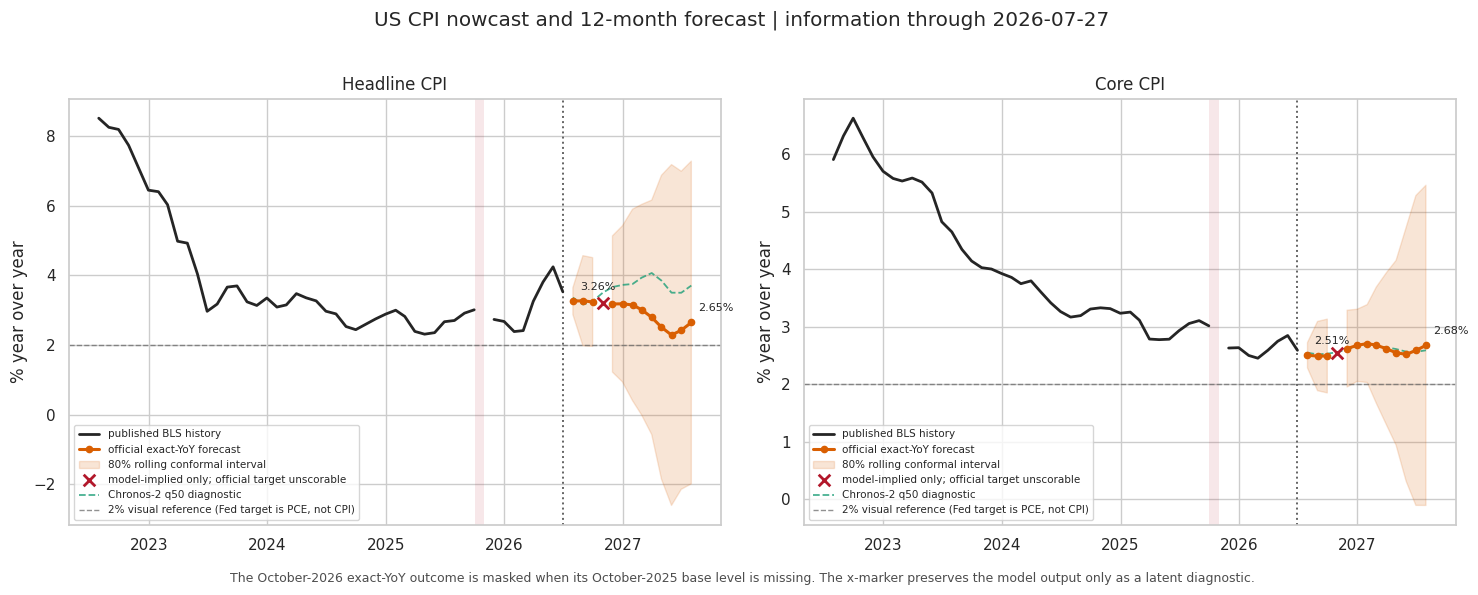

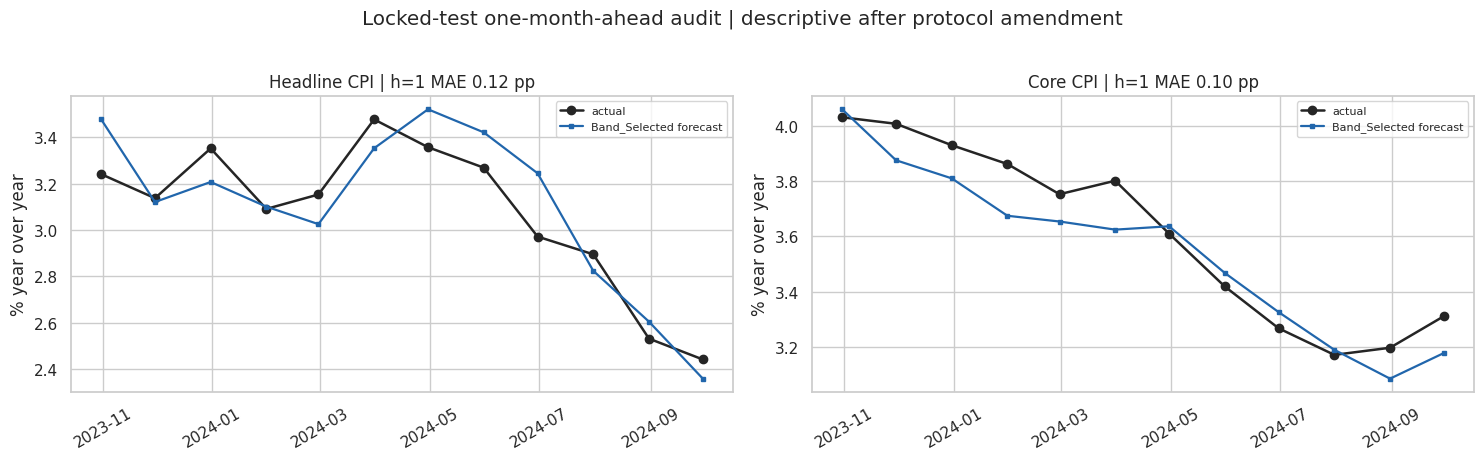

In [ ]:
presentation_figures = {}


def save_presentation_figure(fig: plt.Figure, filename: str) -> None:
    raster_path = ARTIFACT_DIR / filename
    vector_path = raster_path.with_suffix(".svg")
    fig.savefig(raster_path, dpi=180, bbox_inches="tight", facecolor="white")
    fig.savefig(vector_path, bbox_inches="tight", facecolor="white")
    presentation_figures[raster_path.name] = str(raster_path)
    presentation_figures[vector_path.name] = str(vector_path)


# Figure 1 — live official forecast, with structural unscorable cells shown separately.
history_index = pd.date_range(
    month_add(last_target_month, -47), last_target_month, freq="ME"
)
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=False)
for ax, target in zip(axes, TARGET_COLUMNS):
    hist = targets.reindex(history_index)[target]
    fc = final_forecast.loc[
        final_forecast["target"].eq(target)
    ].sort_values("target_month")
    ax.plot(
        hist.index.to_pydatetime(),
        np.ma.masked_invalid(hist.to_numpy(dtype=float)),
        color="#252525", lw=2.0, label="published BLS history", zorder=4,
    )
    official = fc["official_target_observable"].fillna(False).to_numpy()
    x = pd.DatetimeIndex(fc["target_month"])
    ax.plot(
        x.to_pydatetime(),
        np.ma.masked_invalid(fc["forecast_yoy"].to_numpy(dtype=float)),
        marker="o", ms=4.5, color="#d95f02", lw=2.2,
        label="official exact-YoY forecast", zorder=5,
    )
    if official.any():
        ax.fill_between(
            x.to_pydatetime(),
            fc["lower80_conformal"].to_numpy(dtype=float),
            fc["upper80_conformal"].to_numpy(dtype=float),
            where=official,
            color="#d95f02", alpha=.16,
            label="80% rolling conformal interval", zorder=2,
        )
    structural = fc.loc[~fc["official_target_observable"].fillna(False)]
    if not structural.empty:
        ax.scatter(
            pd.DatetimeIndex(structural["target_month"]).to_pydatetime(),
            structural["model_output_yoy"].to_numpy(dtype=float),
            marker="x", s=70, color="#b2182b", lw=2,
            label="model-implied only; official target unscorable", zorder=6,
        )
    if fc["chronos_q50"].notna().any():
        ax.plot(
            x.to_pydatetime(),
            fc["chronos_q50"].to_numpy(dtype=float),
            color="#1b9e77", ls="--", lw=1.3, alpha=.8,
            label="Chronos-2 q50 diagnostic",
        )
    for gap_month in target_gap_months:
        if history_index.min() <= gap_month <= last_target_month:
            ax.axvspan(
                (gap_month - pd.offsets.MonthBegin(1)).to_pydatetime(),
                gap_month.to_pydatetime(),
                color="#b2182b", alpha=.10, lw=0, zorder=1,
            )
    ax.axhline(
        2.0, color="#636363", ls="--", lw=1.0, alpha=.7,
        label="2% visual reference (Fed target is PCE, not CPI)",
    )
    ax.axvline(last_target_month.to_pydatetime(), color="#636363", ls=":", lw=1.4)
    finite_fc = fc.loc[fc["forecast_yoy"].notna()]
    for _, point in pd.concat(
        [finite_fc.head(1), finite_fc.tail(1)]
    ).drop_duplicates("target_month").iterrows():
        ax.annotate(
            f"{point['forecast_yoy']:.2f}%",
            (pd.Timestamp(point["target_month"]).to_pydatetime(), point["forecast_yoy"]),
            xytext=(5, 8), textcoords="offset points", fontsize=8,
        )
    ax.set_title("Headline CPI" if target == "headline_yoy" else "Core CPI")
    ax.set_ylabel("% year over year")
    ax.legend(fontsize=7.5, loc="best")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.suptitle(
    f"US CPI nowcast and 12-month forecast | information through {AS_OF_DATE.date()}",
    y=1.02,
)
fig.text(
    0.5, -0.02,
    "The October-2026 exact-YoY outcome is masked when its October-2025 base level is missing. "
    "The x-marker preserves the model output only as a latent diagnostic.",
    ha="center", fontsize=9, color="#4d4d4d",
)
fig.tight_layout()
save_presentation_figure(fig, "presentation_01_live_forecast_corrected.png")
plt.show()


# Figure 2 — deployment-like h=1 locked audit, explicitly descriptive.
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), sharey=False)
for ax, target in zip(axes, TARGET_COLUMNS):
    sub = bt.loc[
        bt["split"].eq("locked_test")
        & bt["horizon"].eq(1)
        & bt["target"].eq(target)
        & bt["model"].eq(RESEARCH_RECIPE)
    ].sort_values("target_month")
    if sub.empty:
        ax.text(.5, .5, "No evaluable locked h=1 rows", ha="center", va="center")
        ax.set_axis_off()
        continue
    ax.plot(
        pd.DatetimeIndex(sub["target_month"]).to_pydatetime(),
        sub["actual"].to_numpy(dtype=float),
        color="#252525", marker="o", lw=1.8, label="actual",
    )
    ax.plot(
        pd.DatetimeIndex(sub["target_month"]).to_pydatetime(),
        sub["prediction"].to_numpy(dtype=float),
        color="#2166ac", marker="s", ms=3.5, lw=1.6,
        label=f"{RESEARCH_RECIPE} forecast",
    )
    h1_mae = float(sub["abs_error"].mean())
    ax.set_title(
        ("Headline CPI" if target == "headline_yoy" else "Core CPI")
        + f" | h=1 MAE {h1_mae:.2f} pp"
    )
    ax.set_ylabel("% year over year")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", rotation=30)
fig.suptitle(
    "Locked-test one-month-ahead audit | descriptive after protocol amendment",
    y=1.02,
)
fig.tight_layout()
save_presentation_figure(fig, "presentation_02_locked_h1_descriptive.png")
plt.show()


### 결과 소개용 모형·불확실성 감사 그림

아래 그림은 “어느 모형이 이겼는가”보다 **어느 시기·horizon에서 결과가 바뀌는가**를 보여준다. 13 horizons를 서로 독립인 13개 표본처럼 세지 않고, 표제의 `n`은 독립에 가까운 origin block 수를 뜻한다. 잠금시험 결과는 사후 재선택에 사용하지 않는다.


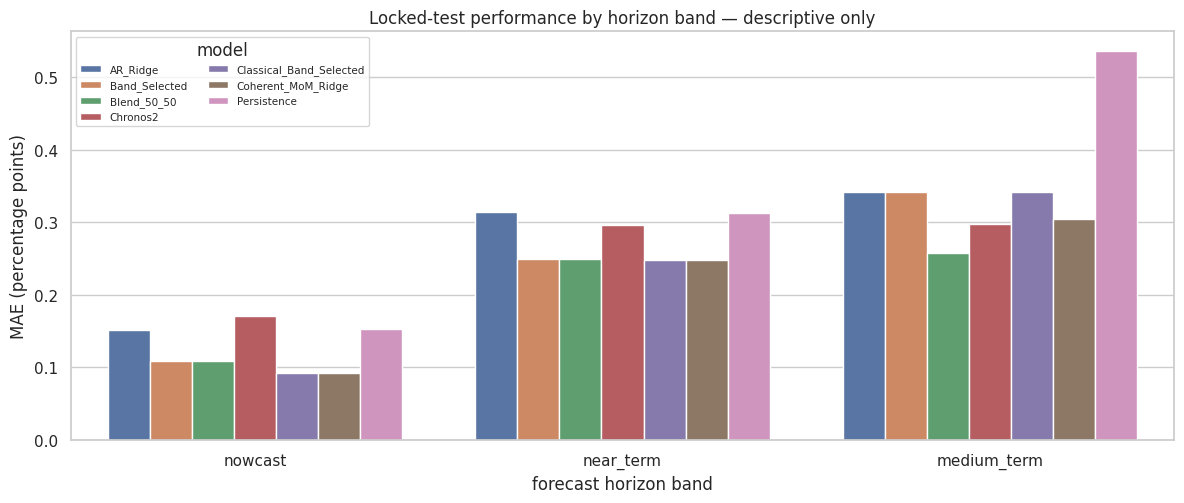

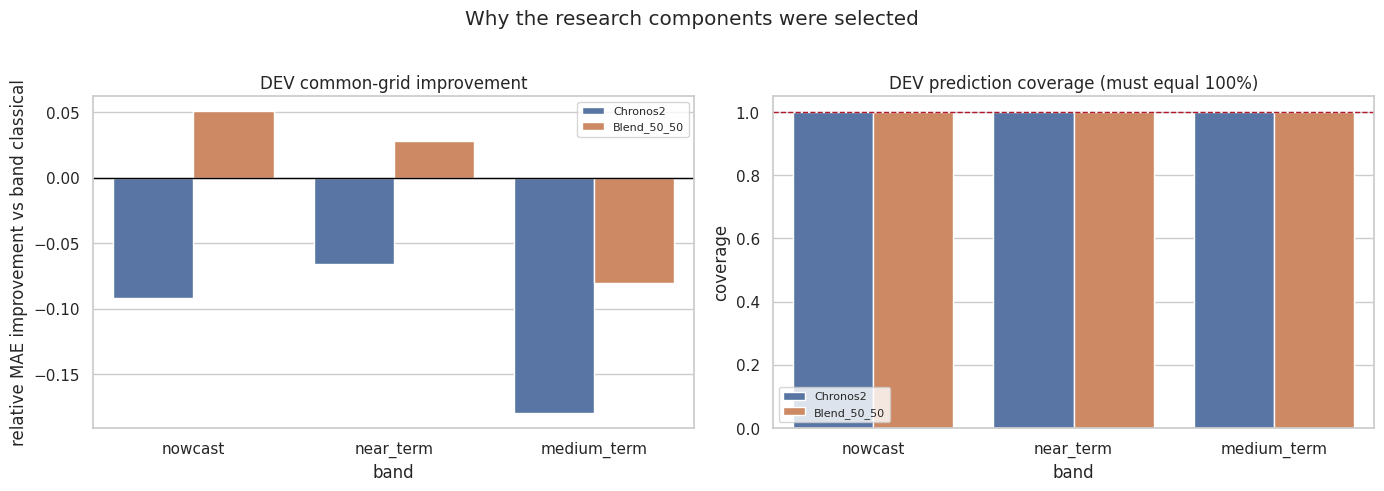

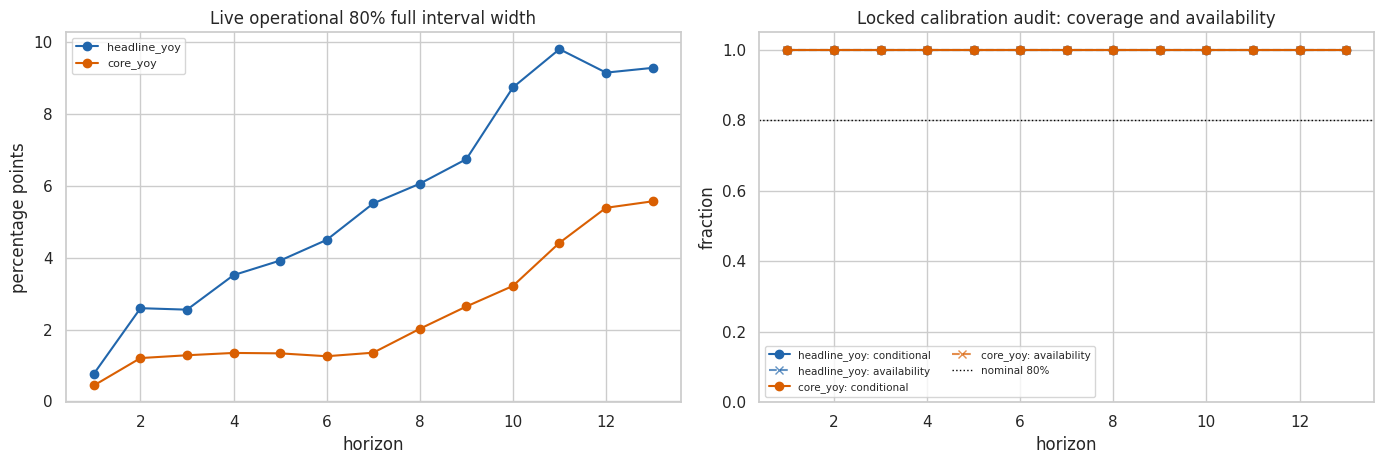

/tmp/ipykernel_2557/328571449.py:122: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


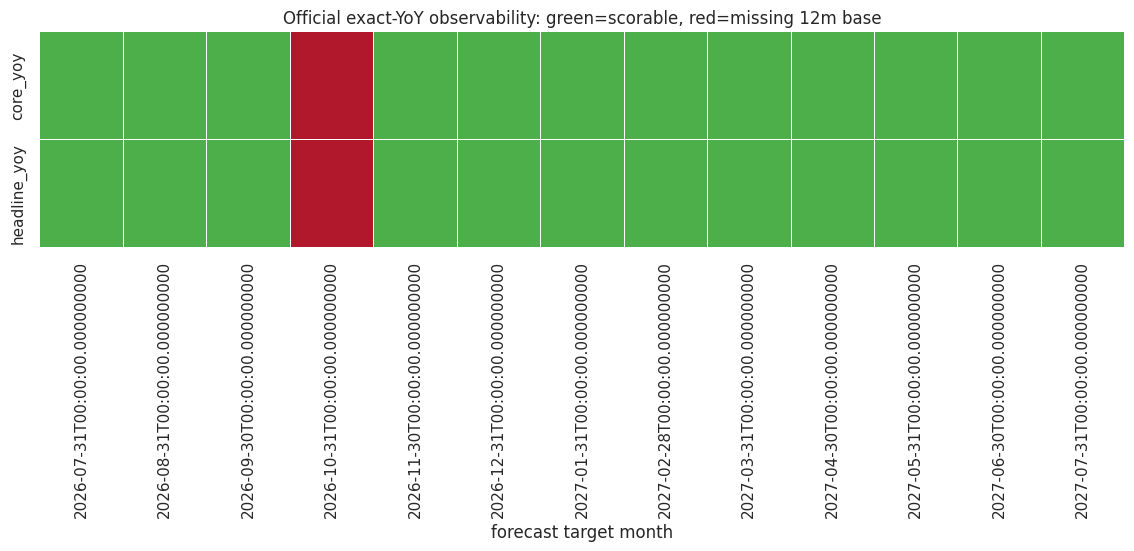

In [ ]:
presentation_models = list(dict.fromkeys([
    "Persistence",
    *BEST_CLASSICAL_BY_BAND.values(),
    "Classical_Band_Selected",
    "Chronos2",
    "Blend_50_50",
    RESEARCH_RECIPE,
]))

# Figure 3 — locked MAE by horizon band. This is an audit, not a selection chart.
_locked = bt.loc[
    bt["split"].eq("locked_test")
    & bt["model"].isin(presentation_models)
].dropna(subset=["actual", "prediction"]).copy()
_h_to_band = {
    h: band for band, hs in HORIZON_BANDS.items() for h in hs
}
_locked["band"] = _locked["horizon"].map(_h_to_band)
_locked_band = (
    _locked.groupby(["model", "band"], sort=True)["abs_error"]
    .mean().reset_index()
)
fig, ax = plt.subplots(figsize=(12, 5.2))
if not _locked_band.empty:
    sns.barplot(
        data=_locked_band, x="band", y="abs_error", hue="model",
        order=list(HORIZON_BANDS), ax=ax,
    )
    ax.legend(title="model", fontsize=7.5, ncol=2)
else:
    ax.text(.5, .5, "No locked metrics", ha="center", va="center")
ax.set_ylabel("MAE (percentage points)")
ax.set_xlabel("forecast horizon band")
ax.set_title("Locked-test performance by horizon band — descriptive only")
fig.tight_layout()
save_presentation_figure(fig, "presentation_03_locked_band_mae.png")
plt.show()


# Figure 4 — the actual DEV-only advanced-model decision.
_decision = band_selection_table.copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
if not _decision.empty:
    sns.barplot(
        data=_decision, x="band", y="relative_improvement",
        hue="candidate", order=list(HORIZON_BANDS), ax=axes[0],
    )
    axes[0].axhline(0, color="black", lw=1)
    axes[0].set_ylabel("relative MAE improvement vs band classical")
    axes[0].set_title("DEV common-grid improvement")
    sns.barplot(
        data=_decision, x="band", y="coverage",
        hue="candidate", order=list(HORIZON_BANDS), ax=axes[1],
    )
    axes[1].axhline(1.0, color="#b2182b", ls="--", lw=1)
    axes[1].set_ylim(0, 1.05)
    axes[1].set_title("DEV prediction coverage (must equal 100%)")
    for ax in axes:
        ax.legend(fontsize=8)
else:
    for ax in axes:
        ax.text(.5, .5, "No advanced candidate completed DEV", ha="center", va="center")
fig.suptitle("Why the research components were selected", y=1.02)
fig.tight_layout()
save_presentation_figure(fig, "presentation_04_dev_selection_audit.png")
plt.show()


# Figure 5 — uncertainty must be read as coverage together with width.
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for target, color in zip(TARGET_COLUMNS, ("#2166ac", "#d95f02")):
    live_width = operational_conformal.loc[
        operational_conformal["target"].eq(target)
    ].sort_values("horizon")
    axes[0].plot(
        live_width["horizon"],
        2 * live_width["conformal_width80"],
        marker="o", color=color, label=target,
    )
    cov = locked_conformal_coverage.loc[
        locked_conformal_coverage["target"].eq(target)
    ].sort_values("horizon")
    axes[1].plot(
        cov["horizon"], cov["conditional_coverage80"],
        marker="o", color=color, label=f"{target}: conditional",
    )
    axes[1].plot(
        cov["horizon"], cov["availability"],
        marker="x", ls="--", color=color, alpha=.7,
        label=f"{target}: availability",
    )
axes[0].set_title("Live operational 80% full interval width")
axes[0].set_xlabel("horizon")
axes[0].set_ylabel("percentage points")
axes[0].legend(fontsize=8)
axes[1].axhline(.8, color="black", ls=":", lw=1, label="nominal 80%")
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Locked calibration audit: coverage and availability")
axes[1].set_xlabel("horizon")
axes[1].set_ylabel("fraction")
axes[1].legend(fontsize=7.5, ncol=2)
fig.tight_layout()
save_presentation_figure(fig, "presentation_05_uncertainty_audit.png")
plt.show()


# Figure 6 — data/definition status, including permanently unscorable cells.
_status = forecast_observability.copy()
_status["value"] = _status["official_target_observable"].astype(int)
_status_pivot = _status.pivot(
    index="target", columns="target_month", values="value"
)
fig, ax = plt.subplots(figsize=(14, 2.8))
sns.heatmap(
    _status_pivot,
    cmap=sns.color_palette(["#b2182b", "#4daf4a"], as_cmap=True),
    vmin=0, vmax=1, cbar=False, linewidths=.5, ax=ax,
)
ax.set_title("Official exact-YoY observability: green=scorable, red=missing 12m base")
ax.set_xlabel("forecast target month")
ax.set_ylabel("")
fig.tight_layout()
save_presentation_figure(fig, "presentation_06_target_observability.png")
plt.show()


## 11. 경제적 relaxation 진단 — strict primary와 bridge sensitivity

양–밀스와 연결할 수 있는 조심스러운 비유는 “돈에 질량이 생긴다”가 아니라 교란 뒤
상태가 얼마나 빨리 감쇠하는가이다. 표준화한 고정 5차원 상태의 Ridge-VAR(1)

\[
z_{t+1}=A_tz_t+\epsilon_{t+1},\qquad
\rho_t=\max_i|\lambda_i(A_t)|,\qquad
r_t=-\log\rho_t
\]

를 계산한다. \(\rho<1\)이면 \(r>0\)인 수축, \(\rho=1\)이면 단위근 경계,
\(\rho>1\)이면 \(r<0\)인 폭발 동학이다. 불안정한 경우를 gap 0으로 바꾸지 않는다.
양의 relaxation-gap proxy와 e-folding time은 수축할 때만 정의한다.

primary 결과는 결측을 보간하지 않은 headline, core, PPI, oil, unemployment의 고정
5차원 상태이며 불완전 window를 건너뛴다. 인접 level의 기하평균 bridge는 별도 sensitivity
variant일 뿐이다. bridge level \(L_g\)가 YoY의 분자 \(g\)와 분모 \(g+12\) 모두에
영향을 준다는 dependency mask를 기록하고, 예측 label·선택·scoring에는 절대 사용하지 않는다.
window 84/120/180개월과 ridge 0.1/1/10 격자 및 moving-block bootstrap을 함께 보고한다.

이 값은 물리적 질량간극, 양–밀스 증명, 구조적 인과계수가 아니다.


Signed relaxation and bridge-dependency tests: PASS


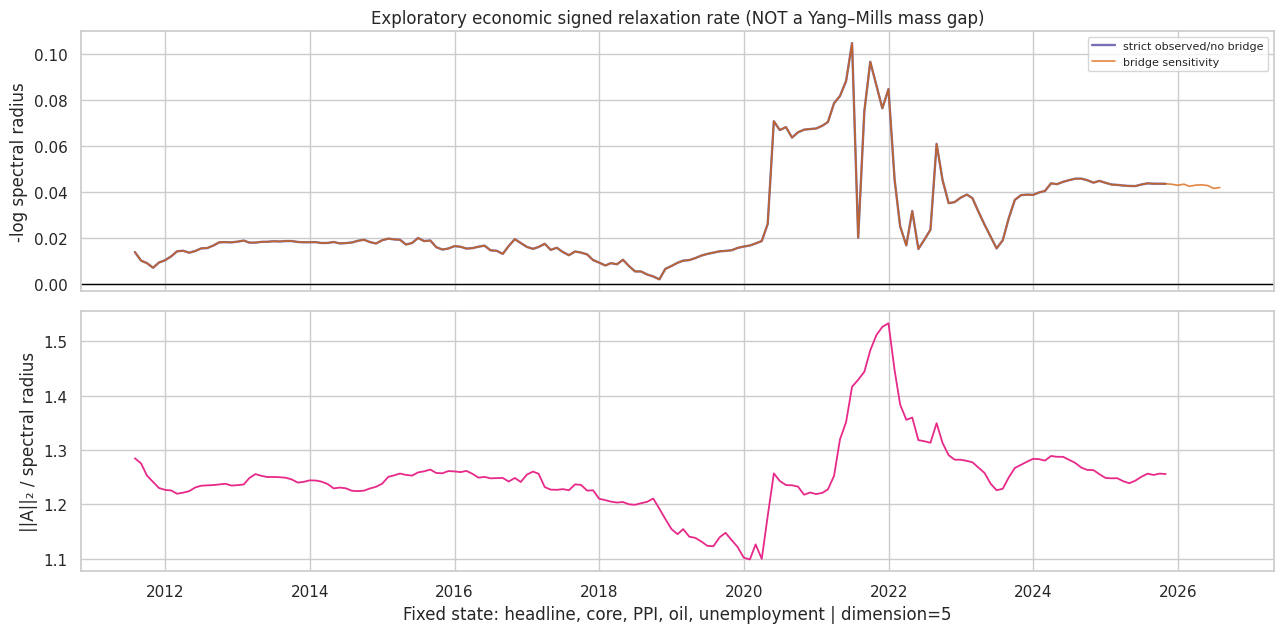

,variant,window_months,ridge_alpha,endpoint,spectral_radius,signed_decay_rate,positive_relaxation_gap_proxy,e_folding_months,doubling_months,stable_linearization,dynamics_status,nonnormality_proxy,state_dimension,bridge_dependent_state_cells,uses_bridge_dependency
0,strict_observed_targets_no_bridge,84,0.1,2025-10-31,0.968976,0.031515,0.031515,31.730912,NaN,True,contractive,1.619111,5,0,False
1,strict_observed_targets_no_bridge,84,1.0,2025-10-31,0.954041,0.047049,0.047049,21.254637,NaN,True,contractive,1.267111,5,0,False
2,strict_observed_targets_no_bridge,84,10.0,2025-10-31,0.872404,0.136503,0.136503,7.325849,NaN,True,contractive,1.149888,5,0,False
3,strict_observed_targets_no_bridge,120,0.1,2025-10-31,0.969878,0.030585,0.030585,32.696231,NaN,True,contractive,1.482335,5,0,False
4,strict_observed_targets_no_bridge,120,1.0,2025-10-31,0.957533,0.043396,0.043396,23.043854,NaN,True,contractive,1.255763,5,0,False
5,strict_observed_targets_no_bridge,120,10.0,2025-10-31,0.893048,0.113115,0.113115,8.840552,NaN,True,contractive,1.123524,5,0,False
6,strict_observed_targets_no_bridge,180,0.1,2025-10-31,0.960977,0.039805,0.039805,25.122388,NaN,True,contractive,1.513130,5,0,False
7,strict_observed_targets_no_bridge,180,1.0,2025-10-31,0.956620,0.044349,0.044349,22.548644,NaN,True,contractive,1.352494,5,0,False
8,strict_observed_targets_no_bridge,180,10.0,2025-10-31,0.926085,0.076790,0.076790,13.022591,NaN,True,contractive,1.109276,5,0,False
9,bridge_sensitivity_only,84,0.1,2026-07-31,0.969297,0.031184,0.031184,32.067633,NaN,True,contractive,1.580927,5,2,True


Strict latest bootstrap audit: {'n_bootstrap': 300, 'signed_rate_ci_low': -0.0007149709693822895, 'signed_rate_ci_high': 0.11367416054447926, 'bootstrap_method': 'moving-block resampling of adjacent VAR transition pairs'}


In [ ]:
LEVEL_TO_TARGET = {
    "headline_level": "headline_yoy",
    "core_level": "core_yoy",
}
RELAXATION_FEATURES = ["ppi_yoy", "oil_yoy", "unemployment"]
RELAXATION_STATE = TARGET_COLUMNS + RELAXATION_FEATURES
RELAXATION_WINDOWS = (84, 120, 180)
RELAXATION_RIDGE_ALPHAS = (0.1, 1.0, 10.0)


def relaxation_metrics_from_matrix(A: np.ndarray) -> dict:
    eigvals = np.linalg.eigvals(A)
    rho = float(np.max(np.abs(eigvals)))
    if not np.isfinite(rho) or rho <= 0:
        return {
            "spectral_radius": rho,
            "signed_decay_rate": np.nan,
            "positive_relaxation_gap_proxy": np.nan,
            "e_folding_months": np.nan,
            "doubling_months": np.nan,
            "stable_linearization": False,
            "dynamics_status": "degenerate_or_invalid",
            "nonnormality_proxy": np.nan,
        }
    signed_rate = float(-np.log(rho))
    stable = bool(rho < 1.0 and not np.isclose(rho, 1.0))
    if np.isclose(rho, 1.0):
        status = "unit_root_boundary"
    elif rho < 1.0:
        status = "contractive"
    else:
        status = "expansive"
    return {
        "spectral_radius": rho,
        "signed_decay_rate": signed_rate,
        "positive_relaxation_gap_proxy": signed_rate if stable else np.nan,
        "e_folding_months": 1.0 / signed_rate if signed_rate > 0 else np.nan,
        "doubling_months": (
            np.log(2.0) / (-signed_rate) if signed_rate < 0 else np.nan
        ),
        "stable_linearization": stable,
        "dynamics_status": status,
        "nonnormality_proxy": float(norm(A, 2) / rho),
    }


def exact_yoy_from_level_panel(level_df: pd.DataFrame) -> pd.DataFrame:
    levels = calendarize_period_end(
        level_df[list(LEVEL_TO_TARGET)], "monthly"
    )
    lag12 = lag_by_calendar(levels, "monthly", 12)
    return pd.DataFrame(
        {
            target: 100.0 * (levels[level] / lag12[level] - 1.0)
            for level, target in LEVEL_TO_TARGET.items()
        },
        index=levels.index,
    )


def isolated_geometric_bridge(
    level_df: pd.DataFrame,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    original = calendarize_period_end(
        level_df[list(LEVEL_TO_TARGET)], "monthly"
    )
    bridged = original.copy()
    imputed = pd.DataFrame(False, index=original.index, columns=original.columns)
    for column in original:
        for stamp in original.index[original[column].isna()]:
            previous_stamp = month_add(stamp, -1)
            next_stamp = month_add(stamp, 1)
            previous_value = original[column].get(previous_stamp, np.nan)
            next_value = original[column].get(next_stamp, np.nan)
            if (
                np.isfinite(previous_value)
                and np.isfinite(next_value)
                and previous_value > 0
                and next_value > 0
            ):
                bridged.loc[stamp, column] = float(
                    np.sqrt(previous_value * next_value)
                )
                imputed.loc[stamp, column] = True
    return bridged, imputed


def bridge_dependency_mask(
    imputed_level_mask: pd.DataFrame,
) -> pd.DataFrame:
    end = month_add(imputed_level_mask.index.max(), 12)
    index = pd.date_range(imputed_level_mask.index.min(), end, freq="ME")
    dependency = pd.DataFrame(
        False, index=index, columns=list(LEVEL_TO_TARGET.values())
    )
    for level_column, target_column in LEVEL_TO_TARGET.items():
        for gap_month in imputed_level_mask.index[
            imputed_level_mask[level_column]
        ]:
            dependency.loc[gap_month, target_column] = True
            dependency.loc[month_add(gap_month, 12), target_column] = True
    return dependency


def shift_targets_to_information_clock(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    result.index = pd.DatetimeIndex(result.index) + pd.offsets.MonthEnd(1)
    return result


def fit_relaxation_block(block: pd.DataFrame, alpha: float) -> dict:
    if (
        block.empty
        or not np.isfinite(block.to_numpy(dtype=float)).all()
        or block.shape[1] != len(RELAXATION_STATE)
    ):
        return {}
    mu = block.mean()
    sigma = block.std(ddof=0).replace(0, np.nan)
    z = (block - mu) / sigma
    if not np.isfinite(z.to_numpy(dtype=float)).all():
        return {}
    X, Y = z.iloc[:-1].to_numpy(), z.iloc[1:].to_numpy()
    model = Ridge(alpha=alpha, fit_intercept=True).fit(X, Y)
    A = np.asarray(model.coef_, dtype=float)
    return {
        **relaxation_metrics_from_matrix(A),
        "state_dimension": int(A.shape[0]),
        "A": A,
        "X": X,
        "Y": Y,
    }


def rolling_relaxation_gap(
    state: pd.DataFrame,
    window: int = 120,
    alpha: float = 1.0,
    dependency_mask: Optional[pd.DataFrame] = None,
    variant: str = "strict_observed_targets_no_bridge",
) -> pd.DataFrame:
    rows = []
    fixed = state.reindex(columns=RELAXATION_STATE).sort_index()
    for end_i in range(window, len(fixed) + 1):
        block = fixed.iloc[end_i - window:end_i]
        fitted = fit_relaxation_block(block, alpha)
        if not fitted:
            continue
        dep_count = 0
        if dependency_mask is not None:
            dep_count = int(
                dependency_mask.reindex(
                    block.index, fill_value=False
                ).to_numpy(dtype=bool).sum()
            )
        rows.append({
            "date": block.index[-1],
            "variant": variant,
            "window_months": window,
            "ridge_alpha": alpha,
            **{k: v for k, v in fitted.items() if k not in ("A", "X", "Y")},
            "bridge_dependent_state_cells": dep_count,
            "uses_bridge_dependency": dep_count > 0,
        })
    return (
        pd.DataFrame(rows).set_index("date") if rows else pd.DataFrame()
    )


def latest_relaxation_gap(
    state: pd.DataFrame,
    window: int,
    alpha: float,
    dependency_mask: Optional[pd.DataFrame],
    variant: str,
) -> dict:
    fixed = state.reindex(columns=RELAXATION_STATE).sort_index()
    for end_i in range(len(fixed), window - 1, -1):
        block = fixed.iloc[end_i - window:end_i]
        fitted = fit_relaxation_block(block, alpha)
        if not fitted:
            continue
        dep_count = (
            int(
                dependency_mask.reindex(
                    block.index, fill_value=False
                ).to_numpy(dtype=bool).sum()
            )
            if dependency_mask is not None else 0
        )
        return {
            "variant": variant,
            "window_months": window,
            "ridge_alpha": alpha,
            "endpoint": block.index[-1],
            **{k: v for k, v in fitted.items() if k not in ("A", "X", "Y")},
            "bridge_dependent_state_cells": dep_count,
            "uses_bridge_dependency": dep_count > 0,
        }
    return {
        "variant": variant,
        "window_months": window,
        "ridge_alpha": alpha,
        "endpoint": pd.NaT,
        "dynamics_status": "no_complete_window",
    }


strict_targets = exact_yoy_from_level_panel(target_levels)
bridged_levels, imputed_level_mask = isolated_geometric_bridge(target_levels)
bridged_targets = exact_yoy_from_level_panel(bridged_levels)
bridge_dependency = bridge_dependency_mask(imputed_level_mask)
strict_info_targets = shift_targets_to_information_clock(strict_targets)
bridged_info_targets = shift_targets_to_information_clock(bridged_targets)
bridge_dependency_info = shift_targets_to_information_clock(bridge_dependency)

if all(col in feature_panel for col in RELAXATION_FEATURES):
    strict_state = pd.concat(
        [strict_info_targets, feature_panel[RELAXATION_FEATURES]], axis=1
    ).sort_index().reindex(columns=RELAXATION_STATE)
    bridge_state = pd.concat(
        [bridged_info_targets, feature_panel[RELAXATION_FEATURES]], axis=1
    ).sort_index().reindex(columns=RELAXATION_STATE)
else:
    strict_state = bridge_state = pd.DataFrame(columns=RELAXATION_STATE)

if CFG.run_spectral_diagnostic and not strict_state.empty:
    spectral_proxy_strict = rolling_relaxation_gap(
        strict_state, 120, 1.0, None,
        "strict_observed_targets_no_bridge",
    )
    spectral_proxy_bridge = rolling_relaxation_gap(
        bridge_state, 120, 1.0, bridge_dependency_info,
        "bridge_sensitivity_only",
    )
    _sensitivity_rows = []
    for _variant, _state, _dependency in [
        ("strict_observed_targets_no_bridge", strict_state, None),
        ("bridge_sensitivity_only", bridge_state, bridge_dependency_info),
    ]:
        for _window in RELAXATION_WINDOWS:
            for _alpha in RELAXATION_RIDGE_ALPHAS:
                _sensitivity_rows.append(
                    latest_relaxation_gap(
                        _state, _window, _alpha, _dependency, _variant
                    )
                )
    relaxation_sensitivity_grid = pd.DataFrame(_sensitivity_rows)
else:
    spectral_proxy_strict = pd.DataFrame()
    spectral_proxy_bridge = pd.DataFrame()
    relaxation_sensitivity_grid = pd.DataFrame()

# Compatibility alias: primary is strict/no-bridge only.
spectral_proxy = spectral_proxy_strict
bridge_dependency_audit = (
    bridge_dependency.stack()
    .rename("depends_on_imputed_level")
    .reset_index()
    .rename(columns={"level_0": "target_month", "level_1": "target"})
)
bridge_dependency_audit = bridge_dependency_audit.loc[
    bridge_dependency_audit["depends_on_imputed_level"]
]


def block_bootstrap_latest_signed_rate(
    state: pd.DataFrame,
    window: int,
    alpha: float,
    reps: int,
    block_length: int = 12,
) -> dict:
    fixed = state.reindex(columns=RELAXATION_STATE).sort_index()
    chosen = None
    for end_i in range(len(fixed), window - 1, -1):
        block = fixed.iloc[end_i - window:end_i]
        fitted = fit_relaxation_block(block, alpha)
        if fitted:
            chosen = fitted
            break
    if chosen is None:
        return {"n_bootstrap": 0, "signed_rate_ci_low": np.nan, "signed_rate_ci_high": np.nan}
    X, Y = chosen["X"], chosen["Y"]
    n = len(X)
    rng = np.random.default_rng(SEED + 991)
    rates = []
    for _ in range(reps):
        indices = []
        while len(indices) < n:
            start = int(rng.integers(0, n))
            indices.extend((start + j) % n for j in range(block_length))
        idx = np.asarray(indices[:n])
        model = Ridge(alpha=alpha, fit_intercept=True).fit(X[idx], Y[idx])
        metric = relaxation_metrics_from_matrix(np.asarray(model.coef_, dtype=float))
        if np.isfinite(metric["signed_decay_rate"]):
            rates.append(metric["signed_decay_rate"])
    if not rates:
        return {"n_bootstrap": 0, "signed_rate_ci_low": np.nan, "signed_rate_ci_high": np.nan}
    low, high = np.quantile(rates, [0.025, 0.975])
    return {
        "n_bootstrap": len(rates),
        "signed_rate_ci_low": float(low),
        "signed_rate_ci_high": float(high),
        "bootstrap_method": "moving-block resampling of adjacent VAR transition pairs",
    }


relaxation_bootstrap_audit = (
    block_bootstrap_latest_signed_rate(
        strict_state, 120, 1.0, CFG.relaxation_bootstrap_reps
    )
    if CFG.run_spectral_diagnostic and not strict_state.empty
    else {}
)

# Mathematical and bridge-dependency regression tests.
_m09 = relaxation_metrics_from_matrix(np.array([[0.9]]))
assert _m09["signed_decay_rate"] > 0 and _m09["stable_linearization"]
assert np.isfinite(_m09["positive_relaxation_gap_proxy"])
assert np.isfinite(_m09["e_folding_months"])
_m105 = relaxation_metrics_from_matrix(np.array([[1.05]]))
assert _m105["signed_decay_rate"] < 0 and not _m105["stable_linearization"]
assert np.isnan(_m105["positive_relaxation_gap_proxy"])
assert np.isnan(_m105["e_folding_months"])
assert np.isfinite(_m105["doubling_months"])

_test_index = pd.date_range("2020-01-31", periods=36, freq="ME")
_test_gap = _test_index[15]
_test_levels = pd.DataFrame(
    {
        "headline_level": 100 * np.exp(0.002 * np.arange(36)),
        "core_level": 110 * np.exp(0.0015 * np.arange(36)),
    },
    index=_test_index,
)
_test_levels.loc[_test_gap, :] = np.nan
_strict_test = exact_yoy_from_level_panel(_test_levels)
_bridge_test_levels, _test_imputed = isolated_geometric_bridge(_test_levels)
_bridge_test = exact_yoy_from_level_panel(_bridge_test_levels)
_test_dependency = bridge_dependency_mask(_test_imputed)
_gap_plus_12 = month_add(_test_gap, 12)
assert _strict_test.loc[[_test_gap, _gap_plus_12]].isna().all().all()
assert _bridge_test.loc[[_test_gap, _gap_plus_12]].notna().all().all()
assert _test_dependency.loc[_test_gap].all()
assert _test_dependency.loc[_gap_plus_12].all()
assert _test_dependency.sum().eq(2).all()
print("Signed relaxation and bridge-dependency tests: PASS")

if not spectral_proxy_strict.empty:
    assert spectral_proxy_strict["state_dimension"].nunique() == 1
    fig, axes = plt.subplots(2, 1, figsize=(13, 6.5), sharex=True)
    axes[0].plot(
        spectral_proxy_strict.index,
        spectral_proxy_strict["signed_decay_rate"],
        color="#7570b3", lw=1.7, label="strict observed/no bridge",
    )
    if not spectral_proxy_bridge.empty:
        axes[0].plot(
            spectral_proxy_bridge.index,
            spectral_proxy_bridge["signed_decay_rate"],
            color="#d95f02", lw=1.2, alpha=.75,
            label="bridge sensitivity",
        )
    axes[0].axhline(0, color="black", lw=1)
    axes[0].set_ylabel("-log spectral radius")
    axes[0].set_title(
        "Exploratory economic signed relaxation rate (NOT a Yang–Mills mass gap)"
    )
    axes[0].legend(fontsize=8)
    axes[1].plot(
        spectral_proxy_strict.index,
        spectral_proxy_strict["nonnormality_proxy"],
        color="#e7298a", lw=1.3,
    )
    axes[1].set_ylabel("||A||₂ / spectral radius")
    axes[1].set_xlabel(
        "Fixed state: headline, core, PPI, oil, unemployment | dimension=5"
    )
    fig.tight_layout()
    save_presentation_figure(fig, "presentation_07_signed_relaxation_proxy.png")
    plt.show()
    display(relaxation_sensitivity_grid)
    print("Strict latest bootstrap audit:", relaxation_bootstrap_audit)


## 12. 경제·금융시장의 대칭을 검정 가능한 가설로 바꾸기

순수 Yang–Mills의 고전 작용은 별도의 질량척도를 갖지 않지만, 양자 beta function의
running을 통해 차원 있는 \(\Lambda_{\rm YM}\)가 생긴다. 개념적으로

\[
\beta(g)=\mu\frac{dg}{d\mu}<0,\qquad
\Lambda_{\rm YM}\sim \mu\exp\!\left[-\frac{1}{2b_0g^2(\mu)}\right],
\qquad m_a=c_a\Lambda_{\rm YM}
\]

이다. 경제에는 quantum anomaly나 국소 게이지장이 확인되어 있지 않으므로 이 수식을
그대로 옮기지 않는다. 대신 다음 세 객체를 분리한다.

1. **대칭변환 \(G\)**: 명목단위 재척도, 부문 label 교환, 시간 이동, 시간 반전,
   관측시간 척도 변경.
2. **order parameter \(B_t\)**: 대칭 null에서 0 또는 정상범위이고, 부문 분산·분포 이동·
   비가역성·scale beta가 커질수록 증가하는 통계량.
3. **유한 완화척도**: 전이연산자 \(K_t\)의 두 번째 고유값으로

\[
m_{\rm econ}(t)=-\frac{1}{\Delta t}\log|\lambda_2(K_t)|,\qquad
\tau_{\rm mix}(t)=m_{\rm econ}(t)^{-1}.
\]

따라서 가장 방어적인 대응은 **인플레이션율 = 질량간극**이 아니다. 인플레이션은 상태
\(x_t\)에서 관측한 \(h(x_t)\)이고, 질량간극에 가장 가까운 경제량은 인플레이션 상태의
가장 느린 비정상 모드가 소멸하는 역시간 \(m_{\rm econ}\)이다. 여러 유한 모드
\(m_a=-\log|\lambda_a|\)는 “glueball”의 입자 대응이 아니라 집단적 인플레이션 regime의
완화 spectrum으로만 해석한다.


In [ ]:
SYMMETRY_SECTOR_SPECS = SYMMETRY_DIAGNOSTIC_SPECS
SYMMETRY_MIN_SECTORS = 5
SYMMETRY_COV_WINDOW = 60
SYMMETRY_DISTRIBUTION_WINDOW = 36
SYMMETRY_IRREVERSIBILITY_WINDOW = 120

symmetry_dictionary = pd.DataFrame([
    {
        "symmetry": "constant nominal-unit / numeraire scale",
        "transformation": "P_i(t) -> c P_i(t), c>0 constant",
        "invariant": "Delta log P_i and exact YoY inflation",
        "breaking_statistic": "none: exact algebraic invariance test",
        "economic_interpretation": "inflation is already invariant; it cannot be this symmetry's order parameter",
        "claim_status": "exact identity",
    },
    {
        "symmetry": "sector exchangeability",
        "transformation": "pi_i(t) -> pi_sigma(i)(t)",
        "invariant": "cross-sectional spectrum under label permutation",
        "breaking_statistic": "sector dispersion, common-mode share, effective rank",
        "economic_interpretation": "heterogeneous relative-price adjustment versus collective inflation mode",
        "claim_status": "diagnostic, not spontaneous symmetry breaking",
    },
    {
        "symmetry": "time translation / stationarity",
        "transformation": "law(x_t,...,x_t+k) invariant under t -> t+s",
        "invariant": "adjacent-window state distribution",
        "breaking_statistic": "RBF-MMD between adjacent windows",
        "economic_interpretation": "regime or policy/supply distribution shift",
        "claim_status": "statistical null",
    },
    {
        "symmetry": "time reversal / detailed balance",
        "transformation": "path (x_t,...,x_t+k) -> reversed path",
        "invariant": "stationary transition flux i->j equals j->i",
        "breaking_statistic": "discrete entropy-production rate",
        "economic_interpretation": "irreversible propagation, hysteresis, asymmetric adjustment",
        "claim_status": "coarse-grained diagnostic",
    },
    {
        "symmetry": "scale / coarse-graining",
        "transformation": "monthly scale tau -> a tau",
        "invariant": "dimensionless cross-sector coupling g_econ(tau)",
        "breaking_statistic": "beta_econ = d g_econ / d log(tau)",
        "economic_interpretation": "a crossover time tau_star emerges when coupling runs with scale",
        "claim_status": "empirical RG analogy only",
    },
    {
        "symmetry": "financial numeraire / no-arbitrage",
        "transformation": "asset prices and discount factors change with numeraire",
        "invariant": "properly transformed relative values; zero loop curvature under no arbitrage",
        "breaking_statistic": "tradable-loop curvature at synchronized high frequency",
        "economic_interpretation": "arbitrage/market-friction diagnostic",
        "claim_status": "not estimated from asynchronous monthly proxies here",
    },
])
display(symmetry_dictionary)


def exact_yoy_panel_from_levels(level_panel: pd.DataFrame) -> pd.DataFrame:
    regular = calendarize_period_end(level_panel.astype(float), "monthly")
    lag12 = lag_by_calendar(regular, "monthly", 12)
    return 100.0 * (regular / lag12 - 1.0)


sector_levels_dict = {}
sector_label_by_key = {}
for spec in SYMMETRY_SECTOR_SPECS:
    if spec.key not in raw_series:
        continue
    sector_levels_dict[spec.key] = aggregate_to_period_end(
        raw_series[spec.key], spec
    )
    sector_label_by_key[spec.key] = spec.label.replace("CPI ", "").replace(", NSA", "")

if len(sector_levels_dict) < SYMMETRY_MIN_SECTORS:
    raise RuntimeError(
        f"Only {len(sector_levels_dict)} BLS major-group CPI series are available; "
        f"need at least {SYMMETRY_MIN_SECTORS}. No synthetic sector fallback."
    )

sector_levels = calendarize_period_end(
    pd.DataFrame(sector_levels_dict), "monthly"
)
sector_yoy = exact_yoy_panel_from_levels(sector_levels)
sector_yoy = sector_yoy.rename(columns=sector_label_by_key)
sector_observed_count = sector_yoy.notna().sum(axis=1)
sector_common_mean = sector_yoy.mean(axis=1).where(
    sector_observed_count >= SYMMETRY_MIN_SECTORS
).rename("sector_unweighted_common_mean")
sector_dispersion = sector_yoy.std(axis=1, ddof=0).where(
    sector_observed_count >= SYMMETRY_MIN_SECTORS
).rename("sector_dispersion")
sector_skewness = sector_yoy.skew(axis=1).where(
    sector_observed_count >= SYMMETRY_MIN_SECTORS
).rename("sector_skewness")


def rolling_sector_modes(
    frame: pd.DataFrame,
    window: int = 60,
    min_fraction: float = 0.90,
) -> pd.DataFrame:
    rows = []
    for end_i in range(window, len(frame) + 1):
        block = frame.iloc[end_i - window:end_i]
        complete = block.dropna(how="any")
        if len(complete) < math.ceil(window * min_fraction):
            continue
        std = complete.std(ddof=0).replace(0, np.nan)
        z = (complete - complete.mean()) / std
        if not np.isfinite(z.to_numpy(dtype=float)).all():
            continue
        cov = np.cov(z.to_numpy(dtype=float), rowvar=False, ddof=0)
        eigenvalues = np.linalg.eigvalsh(cov)
        eigenvalues = np.clip(np.real(eigenvalues), 0, None)
        total = float(eigenvalues.sum())
        if total <= 0:
            continue
        probabilities = eigenvalues / total
        positive = probabilities[probabilities > 0]
        rows.append({
            "date": block.index[-1],
            "common_mode_share": float(eigenvalues[-1] / total),
            "effective_rank": float(np.exp(-(positive * np.log(positive)).sum())),
            "n_complete_months": int(len(complete)),
            "n_sectors": int(frame.shape[1]),
        })
    return pd.DataFrame(rows).set_index("date") if rows else pd.DataFrame()


sector_mode_metrics = rolling_sector_modes(
    sector_yoy, SYMMETRY_COV_WINDOW
)


def rbf_mmd2(x: np.ndarray, y: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    pooled = np.vstack([x, y])
    squared = (
        np.sum(pooled ** 2, axis=1)[:, None]
        + np.sum(pooled ** 2, axis=1)[None, :]
        - 2 * pooled @ pooled.T
    )
    positive = squared[np.triu_indices_from(squared, k=1)]
    positive = positive[positive > 0]
    bandwidth2 = float(np.median(positive)) if len(positive) else 1.0
    bandwidth2 = max(bandwidth2, 1e-8)

    def kernel(a, b):
        distance2 = (
            np.sum(a ** 2, axis=1)[:, None]
            + np.sum(b ** 2, axis=1)[None, :]
            - 2 * a @ b.T
        )
        return np.exp(-distance2 / (2 * bandwidth2))

    return float(kernel(x, x).mean() + kernel(y, y).mean() - 2 * kernel(x, y).mean())


def rolling_time_translation_break(
    state: pd.DataFrame,
    window: int = 36,
    min_fraction: float = 0.85,
) -> pd.Series:
    values = []
    for end_i in range(2 * window, len(state) + 1):
        left = state.iloc[end_i - 2 * window:end_i - window].dropna(how="any")
        right = state.iloc[end_i - window:end_i].dropna(how="any")
        if (
            len(left) < math.ceil(window * min_fraction)
            or len(right) < math.ceil(window * min_fraction)
        ):
            continue
        pooled = pd.concat([left, right])
        center = pooled.median()
        scale = (pooled.quantile(.75) - pooled.quantile(.25)).replace(0, np.nan)
        z_left = (left - center) / scale
        z_right = (right - center) / scale
        if (
            not np.isfinite(z_left.to_numpy(dtype=float)).all()
            or not np.isfinite(z_right.to_numpy(dtype=float)).all()
        ):
            continue
        values.append((state.index[end_i - 1], rbf_mmd2(z_left, z_right)))
    return pd.Series(
        dict(values), name="time_translation_mmd", dtype=float
    ).sort_index()


def rolling_entropy_production(
    series: pd.Series,
    window: int = 120,
    n_states: int = 4,
    smoothing: float = 0.5,
) -> pd.Series:
    regular = calendarize_period_end(series.astype(float), "monthly")
    rows = []
    for end_i in range(window, len(regular) + 1):
        block = regular.iloc[end_i - window:end_i]
        # Adjacency matters: never compress an internal missing month.
        if not np.isfinite(block.to_numpy(dtype=float)).all():
            continue
        edges = np.unique(
            np.quantile(block.to_numpy(dtype=float), np.linspace(0, 1, n_states + 1))
        )
        if len(edges) != n_states + 1:
            continue
        states = np.clip(
            np.digitize(block.to_numpy(dtype=float), edges[1:-1]),
            0,
            n_states - 1,
        )
        counts = np.full((n_states, n_states), smoothing, dtype=float)
        for left, right in zip(states[:-1], states[1:]):
            counts[left, right] += 1.0
        flux = counts / counts.sum()
        reverse = flux.T
        entropy = float(np.sum(flux * np.log(flux / reverse)))
        rows.append((block.index[-1], max(entropy, 0.0)))
    return pd.Series(
        dict(rows), name="time_reversal_entropy", dtype=float
    ).sort_index()


symmetry_state_for_distribution = pd.concat(
    [
        targets["headline_yoy"],
        targets["core_yoy"],
        sector_common_mean,
        sector_dispersion,
    ],
    axis=1,
)
time_translation_mmd = rolling_time_translation_break(
    symmetry_state_for_distribution,
    SYMMETRY_DISTRIBUTION_WINDOW,
)
time_reversal_entropy = rolling_entropy_production(
    sector_common_mean,
    SYMMETRY_IRREVERSIBILITY_WINDOW,
)

symmetry_base_metrics = pd.concat(
    [
        sector_dispersion,
        sector_skewness,
        sector_mode_metrics,
        time_translation_mmd,
        time_reversal_entropy,
    ],
    axis=1,
).sort_index()

# Constant unit-rescaling is an exact symmetry of log changes and YoY ratios.
_numeraire_scale_test = 7.3
_original_yoy = exact_yoy_panel_from_levels(sector_levels)
_rescaled_yoy = exact_yoy_panel_from_levels(
    _numeraire_scale_test * sector_levels
)
_numeraire_ok = _original_yoy.notna() & _rescaled_yoy.notna()
NUMERAIRE_INVARIANCE_MAX_ERROR = float(
    (_original_yoy.where(_numeraire_ok) - _rescaled_yoy.where(_numeraire_ok))
    .abs().max().max()
)
assert NUMERAIRE_INVARIANCE_MAX_ERROR < 1e-10
print("Constant nominal-unit invariance test: PASS | max error =", NUMERAIRE_INVARIANCE_MAX_ERROR)
display(sector_yoy.tail(18))
display(symmetry_base_metrics.tail(12))


,symmetry,transformation,invariant,breaking_statistic,economic_interpretation,claim_status
0,constant nominal-unit / numeraire scale,"P_i(t) -> c P_i(t), c>0 constant",Delta log P_i and exact YoY inflation,none: exact algebraic invariance test,inflation is already invariant; it cannot be t...,exact identity
1,sector exchangeability,pi_i(t) -> pi_sigma(i)(t),cross-sectional spectrum under label permutation,"sector dispersion, common-mode share, effectiv...",heterogeneous relative-price adjustment versus...,"diagnostic, not spontaneous symmetry breaking"
2,time translation / stationarity,"law(x_t,...,x_t+k) invariant under t -> t+s",adjacent-window state distribution,RBF-MMD between adjacent windows,regime or policy/supply distribution shift,statistical null
3,time reversal / detailed balance,"path (x_t,...,x_t+k) -> reversed path",stationary transition flux i->j equals j->i,discrete entropy-production rate,"irreversible propagation, hysteresis, asymmetr...",coarse-grained diagnostic
4,scale / coarse-graining,monthly scale tau -> a tau,dimensionless cross-sector coupling g_econ(tau),beta_econ = d g_econ / d log(tau),a crossover time tau_star emerges when couplin...,empirical RG analogy only
5,financial numeraire / no-arbitrage,asset prices and discount factors change with ...,properly transformed relative values; zero loo...,tradable-loop curvature at synchronized high f...,arbitrage/market-friction diagnostic,not estimated from asynchronous monthly proxie...


Constant nominal-unit invariance test: PASS | max error = 2.4868995751603507e-14


,food and beverages,housing,apparel,transportation,medical care,recreation,education and communication,other goods and services
2025-01-31,2.436711,3.855013,0.404858,3.156690,2.635249,1.639332,0.489785,2.373807
2025-02-28,2.554814,3.850120,0.597795,1.650927,2.886389,1.782797,0.330899,3.275878
2025-03-31,2.896854,3.702675,0.330739,-0.889590,2.643878,1.850445,0.547928,3.810962
2025-04-30,2.701874,3.953414,-0.717592,-1.512178,2.737833,1.600295,0.215010,3.578167
2025-05-31,2.799614,3.954901,-0.913670,-1.329246,2.481351,1.818735,0.301463,3.818260
2025-06-30,2.876715,4.042660,-0.517772,-0.068719,2.773213,2.060602,0.472920,3.722655
2025-07-31,2.781166,3.925911,-0.213183,0.046099,3.513410,2.393746,0.346811,3.873327
2025-08-31,3.111325,3.972840,0.232376,0.928181,3.449284,2.300780,0.347101,3.873488
2025-09-30,3.043559,3.859242,-0.083372,1.742185,3.283263,3.033759,0.389987,4.129654
2025-10-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,sector_dispersion,sector_skewness,common_mode_share,effective_rank,n_complete_months,n_sectors,time_translation_mmd,time_reversal_entropy
2025-07-31,1.645731,-0.368062,0.544639,3.647694,60.0,8.0,0.229873,0.00316
2025-08-31,1.467134,-0.347916,0.542322,3.650940,60.0,8.0,0.257141,0.00865
2025-09-30,1.472759,-0.757391,0.540912,3.644733,60.0,8.0,0.292506,0.00865
2025-10-31,NaN,NaN,0.538699,3.629402,59.0,8.0,0.322211,NaN
2025-11-30,1.151607,-0.257717,0.537392,3.616672,59.0,8.0,0.358159,NaN
2025-12-31,1.457822,-0.388681,0.534258,3.612140,59.0,8.0,0.395122,NaN
2026-01-31,1.930639,-0.065572,0.528703,3.643716,59.0,8.0,0.437748,NaN
2026-02-28,1.712104,-0.478812,0.526583,3.626366,59.0,8.0,0.482285,NaN
2026-03-31,1.329850,-1.024452,0.526218,3.603115,59.0,8.0,0.516459,NaN
2026-04-30,1.854264,0.304050,0.529175,3.635845,59.0,8.0,0.552411,NaN


In [ ]:
from sklearn.cluster import KMeans

ECONOMIC_SCALES_MONTHS = np.array([1, 2, 3, 6, 12, 24], dtype=int)
ECONOMIC_RG_WINDOW = 144
ECONOMIC_MARKOV_WINDOW = 120
ECONOMIC_MARKOV_STATES = 4


def multiscale_coupling_curve(
    sector_frame: pd.DataFrame,
    scales: Sequence[int] = ECONOMIC_SCALES_MONTHS,
    min_complete: int = 72,
) -> pd.DataFrame:
    regular = calendarize_period_end(sector_frame.astype(float), "monthly")
    rows = []
    for scale in scales:
        increments = regular - lag_by_calendar(regular, "monthly", int(scale))
        complete = increments.dropna(how="any")
        if len(complete) < min_complete:
            rows.append({
                "scale_months": int(scale),
                "coupling": np.nan,
                "n_complete": int(len(complete)),
            })
            continue
        corr = complete.corr().to_numpy(dtype=float)
        upper = corr[np.triu_indices_from(corr, k=1)]
        rows.append({
            "scale_months": int(scale),
            "coupling": float(np.nanmean(upper)),
            "n_complete": int(len(complete)),
        })
    curve = pd.DataFrame(rows)
    if curve["coupling"].notna().sum() >= 4:
        ok = curve["coupling"].notna()
        beta = np.gradient(
            curve.loc[ok, "coupling"].to_numpy(dtype=float),
            np.log(curve.loc[ok, "scale_months"].to_numpy(dtype=float)),
        )
        curve.loc[ok, "beta_econ"] = beta
    else:
        curve["beta_econ"] = np.nan
    return curve


def rolling_multiscale_coupling(
    sector_frame: pd.DataFrame,
    window: int = ECONOMIC_RG_WINDOW,
    scales: Sequence[int] = ECONOMIC_SCALES_MONTHS,
) -> pd.DataFrame:
    regular = calendarize_period_end(sector_frame.astype(float), "monthly")
    rows = []
    for end_i in range(window, len(regular) + 1):
        block = regular.iloc[end_i - window:end_i]
        curve = multiscale_coupling_curve(
            block, scales=scales, min_complete=max(48, window // 2)
        )
        if not np.isfinite(curve["coupling"]).all():
            continue
        beta = curve["beta_econ"].to_numpy(dtype=float)
        if not np.isfinite(beta).all():
            continue
        scales_array = curve["scale_months"].to_numpy(dtype=float)
        crossover_i = int(np.argmax(np.abs(beta)))
        tau_star = float(scales_array[crossover_i])
        row = {
            "date": block.index[-1],
            "scale_break_strength": float(np.sqrt(np.mean(beta ** 2))),
            "crossover_scale_months": tau_star,
            "lambda_econ_per_month": 1.0 / tau_star,
            "coupling_short_scale": float(curve["coupling"].iloc[0]),
            "coupling_long_scale": float(curve["coupling"].iloc[-1]),
            "beta_peak_abs": float(np.max(np.abs(beta))),
        }
        for _, point in curve.iterrows():
            scale = int(point["scale_months"])
            row[f"g_tau_{scale}"] = float(point["coupling"])
            row[f"beta_tau_{scale}"] = float(point["beta_econ"])
        rows.append(row)
    return pd.DataFrame(rows).set_index("date") if rows else pd.DataFrame()


def markov_gap_from_transition(transition: np.ndarray) -> dict:
    eigenvalues = np.linalg.eigvals(np.asarray(transition, dtype=float))
    magnitude = np.sort(np.abs(eigenvalues))[::-1]
    if len(magnitude) < 2 or not np.isclose(magnitude[0], 1.0, atol=1e-6):
        return {
            "lambda2_abs": np.nan,
            "mass_gap_analog_per_month": np.nan,
            "mixing_time_months": np.nan,
            "mode_rates": [],
        }
    nontrivial = np.clip(magnitude[1:], 1e-12, 1 - 1e-12)
    rates = -np.log(nontrivial)
    mass_gap = float(rates[0])
    return {
        "lambda2_abs": float(nontrivial[0]),
        "mass_gap_analog_per_month": mass_gap,
        "mixing_time_months": 1.0 / mass_gap if mass_gap > 0 else np.nan,
        "mode_rates": [float(x) for x in rates],
    }


def rolling_markov_spectrum(
    state: pd.DataFrame,
    window: int = ECONOMIC_MARKOV_WINDOW,
    n_states: int = ECONOMIC_MARKOV_STATES,
    smoothing: float = 0.5,
) -> pd.DataFrame:
    regular = calendarize_period_end(state.astype(float), "monthly")
    rows = []
    for end_i in range(window, len(regular) + 1):
        block = regular.iloc[end_i - window:end_i]
        # Transition adjacency is physical to this analogy; never drop an internal month.
        if not np.isfinite(block.to_numpy(dtype=float)).all():
            continue
        scale = block.std(ddof=0).replace(0, np.nan)
        z = (block - block.mean()) / scale
        if not np.isfinite(z.to_numpy(dtype=float)).all():
            continue
        labels = KMeans(
            n_clusters=n_states,
            random_state=SEED,
            n_init=20,
        ).fit_predict(z.to_numpy(dtype=float))
        counts = np.full((n_states, n_states), smoothing, dtype=float)
        for left, right in zip(labels[:-1], labels[1:]):
            counts[left, right] += 1.0
        transition = counts / counts.sum(axis=1, keepdims=True)
        gap = markov_gap_from_transition(transition)
        rates = gap.pop("mode_rates")
        rows.append({
            "date": block.index[-1],
            **gap,
            "mode_1_rate": rates[0] if len(rates) > 0 else np.nan,
            "mode_2_rate": rates[1] if len(rates) > 1 else np.nan,
            "mode_3_rate": rates[2] if len(rates) > 2 else np.nan,
            "n_states": n_states,
            "window_months": window,
            "transition_entropy": float(
                -np.mean(np.sum(
                    transition * np.log(np.clip(transition, 1e-12, None)),
                    axis=1,
                ))
            ),
        })
    return pd.DataFrame(rows).set_index("date") if rows else pd.DataFrame()


multiscale_coupling_metrics = rolling_multiscale_coupling(sector_yoy)
markov_state = pd.concat(
    [
        targets["headline_yoy"],
        targets["core_yoy"],
        sector_common_mean,
        sector_dispersion,
    ],
    axis=1,
).rename(columns={
    "headline_yoy": "headline_yoy",
    "core_yoy": "core_yoy",
    "sector_unweighted_common_mean": "sector_common_mean",
    "sector_dispersion": "sector_dispersion",
})
markov_spectrum = rolling_markov_spectrum(markov_state)
economic_scales = pd.concat(
    [multiscale_coupling_metrics, markov_spectrum], axis=1
).sort_index()
economic_scales["gap_to_crossover_ratio"] = (
    economic_scales["mass_gap_analog_per_month"]
    / economic_scales["lambda_econ_per_month"]
)


def causal_robust_zscore(
    series: pd.Series,
    window: int = 120,
    min_periods: int = 60,
) -> pd.Series:
    s = series.astype(float)
    median = s.rolling(window, min_periods=min_periods).median()
    q25 = s.rolling(window, min_periods=min_periods).quantile(.25)
    q75 = s.rolling(window, min_periods=min_periods).quantile(.75)
    scale = (q75 - q25).replace(0, np.nan)
    return ((s - median) / scale).rename(series.name)


order_parameter_raw = pd.concat(
    [
        symmetry_base_metrics.get("sector_dispersion"),
        symmetry_base_metrics.get("common_mode_share"),
        symmetry_base_metrics.get("time_translation_mmd"),
        symmetry_base_metrics.get("time_reversal_entropy"),
        economic_scales.get("scale_break_strength"),
    ],
    axis=1,
)
order_parameter_raw.columns = [
    "sector_heterogeneity",
    "collective_mode_concentration",
    "time_translation_break",
    "time_reversal_break",
    "scale_symmetry_break",
]
order_parameter_z = order_parameter_raw.apply(causal_robust_zscore)
positive_break = order_parameter_z.clip(lower=0)
available_components = positive_break.notna().sum(axis=1)
symmetry_breaking_index = (
    np.sqrt((positive_break ** 2).sum(axis=1) / available_components)
    .where(available_components >= 3)
    .rename("symmetry_breaking_index")
)
symmetry_metrics = pd.concat(
    [
        order_parameter_raw,
        order_parameter_z.add_suffix("_z"),
        symmetry_breaking_index,
        economic_scales,
    ],
    axis=1,
).sort_index()

# A simple transition matrix with lambda_2=.8 validates the inverse-time definition.
_transition_test = np.array([[.9, .1], [.1, .9]])
_gap_test = markov_gap_from_transition(_transition_test)
assert np.isclose(_gap_test["lambda2_abs"], .8)
assert np.isclose(_gap_test["mass_gap_analog_per_month"], -np.log(.8))
assert _gap_test["mixing_time_months"] > 0
print("Markov spectral-gap definition test: PASS")
print(
    "Interpretation: CPI inflation is an observable; mass_gap_analog_per_month "
    "is the slowest nonstationary regime-decay rate."
)
display(economic_scales.tail(12))
display(symmetry_metrics.tail(12))


Markov spectral-gap definition test: PASS
Interpretation: CPI inflation is an observable; mass_gap_analog_per_month is the slowest nonstationary regime-decay rate.


,scale_break_strength,crossover_scale_months,lambda_econ_per_month,coupling_short_scale,coupling_long_scale,beta_peak_abs,g_tau_1,beta_tau_1,g_tau_2,beta_tau_2,g_tau_3,beta_tau_3,g_tau_6,beta_tau_6,g_tau_12,beta_tau_12,g_tau_24,beta_tau_24,lambda2_abs,mass_gap_analog_per_month,mixing_time_months,mode_1_rate,mode_2_rate,mode_3_rate,n_states,window_months,transition_entropy,gap_to_crossover_ratio
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-07-31,0.082588,24.0,0.041667,0.077437,0.337286,0.108906,0.077437,0.048264,0.110891,0.059687,0.137802,0.077313,0.204359,0.089444,0.261798,0.095886,0.337286,0.108906,0.901743,0.103426,9.668730,0.103426,0.203459,0.320237,4.0,120.0,0.509667,2.482229
2025-08-31,0.081406,24.0,0.041667,0.077304,0.334230,0.104552,0.077304,0.048410,0.110859,0.060954,0.138549,0.078217,0.204525,0.088878,0.261760,0.093563,0.334230,0.104552,0.903318,0.101680,9.834766,0.101680,0.196005,0.347189,4.0,120.0,0.512923,2.440322
2025-09-30,0.080632,24.0,0.041667,0.076388,0.331546,0.102263,0.076388,0.049986,0.111036,0.061794,0.138892,0.078358,0.204649,0.087839,0.260662,0.091537,0.331546,0.102263,0.903470,0.101512,9.851021,0.101512,0.191135,0.379239,4.0,120.0,0.519476,2.436296
2025-10-31,0.080633,24.0,0.041667,0.076542,0.331617,0.102035,0.076542,0.049967,0.111177,0.062006,0.139173,0.078333,0.204472,0.087801,0.260892,0.091716,0.331617,0.102035,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-11-30,0.079919,24.0,0.041667,0.076662,0.329923,0.099261,0.076662,0.048632,0.110371,0.062012,0.138688,0.078916,0.204146,0.088316,0.261120,0.090729,0.329923,0.099261,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-12-31,0.079915,24.0,0.041667,0.075175,0.328897,0.098288,0.075175,0.051451,0.110838,0.063273,0.139297,0.078584,0.203716,0.087623,0.260768,0.090299,0.328897,0.098288,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-31,0.081991,24.0,0.041667,0.070159,0.328517,0.100508,0.070159,0.054428,0.107885,0.068785,0.139180,0.082019,0.201762,0.086323,0.258850,0.091434,0.328517,0.100508,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-02-28,0.082058,24.0,0.041667,0.069182,0.328149,0.100889,0.069182,0.051555,0.104917,0.067044,0.135775,0.082634,0.200789,0.088324,0.258219,0.091871,0.328149,0.100889,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-31,0.083462,24.0,0.041667,0.065686,0.327601,0.101142,0.065686,0.050221,0.100497,0.070790,0.134078,0.087307,0.199909,0.089026,0.257494,0.092110,0.327601,0.101142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,sector_heterogeneity,collective_mode_concentration,time_translation_break,time_reversal_break,scale_symmetry_break,sector_heterogeneity_z,collective_mode_concentration_z,time_translation_break_z,time_reversal_break_z,scale_symmetry_break_z,symmetry_breaking_index,scale_break_strength,crossover_scale_months,lambda_econ_per_month,coupling_short_scale,coupling_long_scale,beta_peak_abs,g_tau_1,beta_tau_1,g_tau_2,beta_tau_2,g_tau_3,beta_tau_3,g_tau_6,beta_tau_6,g_tau_12,beta_tau_12,g_tau_24,beta_tau_24,lambda2_abs,mass_gap_analog_per_month,mixing_time_months,mode_1_rate,mode_2_rate,mode_3_rate,n_states,window_months,transition_entropy,gap_to_crossover_ratio
2025-07-31,1.645731,0.544639,0.229873,0.00316,0.082588,-0.196949,0.586634,-0.513475,-0.548911,1.377973,0.669769,0.082588,24.0,0.041667,0.077437,0.337286,0.108906,0.077437,0.048264,0.110891,0.059687,0.137802,0.077313,0.204359,0.089444,0.261798,0.095886,0.337286,0.108906,0.901743,0.103426,9.668730,0.103426,0.203459,0.320237,4.0,120.0,0.509667,2.482229
2025-08-31,1.467134,0.542322,0.257141,0.00865,0.081406,-0.304933,0.564976,-0.312396,-0.217433,1.303833,0.635481,0.081406,24.0,0.041667,0.077304,0.334230,0.104552,0.077304,0.048410,0.110859,0.060954,0.138549,0.078217,0.204525,0.088878,0.261760,0.093563,0.334230,0.104552,0.903318,0.101680,9.834766,0.101680,0.196005,0.347189,4.0,120.0,0.512923,2.440322
2025-09-30,1.472759,0.540912,0.292506,0.00865,0.080632,-0.300066,0.555581,-0.045968,-0.211836,1.248041,0.610946,0.080632,24.0,0.041667,0.076388,0.331546,0.102263,0.076388,0.049986,0.111036,0.061794,0.138892,0.078358,0.204649,0.087839,0.260662,0.091537,0.331546,0.102263,0.903470,0.101512,9.851021,0.101512,0.191135,0.379239,4.0,120.0,0.519476,2.436296
2025-10-31,NaN,0.538699,0.322211,NaN,0.080633,NaN,0.537894,0.157089,NaN,1.230278,0.780511,0.080633,24.0,0.041667,0.076542,0.331617,0.102035,0.076542,0.049967,0.111177,0.062006,0.139173,0.078333,0.204472,0.087801,0.260892,0.091716,0.331617,0.102035,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-11-30,1.151607,0.537392,0.358159,NaN,0.079919,-0.538543,0.511510,0.402822,NaN,1.128392,0.651379,0.079919,24.0,0.041667,0.076662,0.329923,0.099261,0.076662,0.048632,0.110371,0.062012,0.138688,0.078916,0.204146,0.088316,0.261120,0.090729,0.329923,0.099261,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-12-31,1.457822,0.534258,0.395122,NaN,0.079915,-0.315412,0.474118,0.641881,NaN,0.982538,0.632886,0.079915,24.0,0.041667,0.075175,0.328897,0.098288,0.075175,0.051451,0.110838,0.063273,0.139297,0.078584,0.203716,0.087623,0.260768,0.090299,0.328897,0.098288,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-31,1.930639,0.528703,0.437748,NaN,0.081991,0.018848,0.434078,0.888084,NaN,0.938890,0.681723,0.081991,24.0,0.041667,0.070159,0.328517,0.100508,0.070159,0.054428,0.107885,0.068785,0.139180,0.082019,0.201762,0.086323,0.258850,0.091434,0.328517,0.100508,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-02-28,1.712104,0.526583,0.482285,NaN,0.082058,-0.137512,0.409873,1.153946,NaN,0.900213,0.759929,0.082058,24.0,0.041667,0.069182,0.328149,0.100889,0.069182,0.051555,0.104917,0.067044,0.135775,0.082634,0.200789,0.088324,0.258219,0.091871,0.328149,0.100889,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-31,1.329850,0.526218,0.516459,NaN,0.083462,-0.406051,0.396267,1.314185,NaN,0.904150,0.821827,0.083462,24.0,0.041667,0.065686,0.327601,0.101142,0.065686,0.050221,0.100497,0.070790,0.134078,0.087307,0.199909,0.089026,0.257494,0.092110,0.327601,0.101142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-04-30,1.854264,0.529175,0.552411,NaN,0.082660,-0.034623,0.408630,1.403641,NaN,0.871387,0.850955,0.082660,24.0,0.041667,0.067197,0.327262,0.102007,0.067197,0.045396,0.098664,0.066017,0.130322,0.086442,0.200148,0.091059,0.256556,0.091693,0.327262,0.102007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
TRIGGER_HORIZONS = (1, 3, 6, 12)
TRIGGER_MIN_TRAIN = 84
TRIGGER_BOOTSTRAP_REPS = 1000
TRIGGER_BLOCK = 12

trigger_panel = feature_panel.copy()
if "treasury_10y" in trigger_panel and "treasury_3m" in trigger_panel:
    trigger_panel["yield_curve_10y_minus_3m"] = (
        trigger_panel["treasury_10y"] - trigger_panel["treasury_3m"]
    )

TRIGGER_CANDIDATES = [
    key for key in [
        "oil_yoy",
        "ppi_yoy",
        "wage_yoy",
        "unit_labor_cost_yoy",
        "productivity_yoy",
        "unemployment",
        "broad_dollar_yoy",
        "vix",
        "credit_risk_signal_yoy",
        "market_inflation_signal_yoy",
        "yield_curve_10y_minus_3m",
    ]
    if key in trigger_panel
]


def lead_by_calendar(series: pd.Series, periods: int) -> pd.Series:
    regular = calendarize_period_end(series.astype(float), "monthly")
    output_index = pd.DatetimeIndex(regular.index)
    future_index = (
        output_index.to_period("M") + periods
    ).to_timestamp(how="end").normalize()
    led = regular.reindex(future_index)
    led.index = output_index
    return led


def expanding_trigger_predictions(
    order_parameter: pd.Series,
    feature: pd.Series,
    horizon: int,
    min_train: int = TRIGGER_MIN_TRAIN,
) -> pd.DataFrame:
    b = calendarize_period_end(order_parameter.astype(float), "monthly")
    z = calendarize_period_end(feature.astype(float), "monthly")
    index = b.index.union(z.index).sort_values()
    b = b.reindex(index)
    z = z.reindex(index)
    X_base = pd.DataFrame({
        "B_t": b,
        "B_lag1": lag_by_calendar(b, "monthly", 1),
        "B_lag3": lag_by_calendar(b, "monthly", 3),
        "B_lag6": lag_by_calendar(b, "monthly", 6),
    }, index=index)
    X_aug = X_base.assign(trigger=z)
    y = lead_by_calendar(b, horizon).rename("B_future")
    records = []
    for origin in index:
        if (
            not np.isfinite(y.get(origin, np.nan))
            or not np.isfinite(X_aug.loc[origin].to_numpy(dtype=float)).all()
        ):
            continue
        # A training row tau is admissible only if tau+h < current origin.
        admissible_end = month_add(origin, -horizon)
        train_mask = (
            (index < admissible_end)
            & y.notna()
            & X_aug.notna().all(axis=1)
        )
        if int(train_mask.sum()) < min_train:
            continue
        Y_train = y.loc[train_mask].to_frame()
        baseline = float(
            fit_fold_ridge(
                X_base.loc[train_mask],
                Y_train,
                X_base.loc[origin],
                alpha=10.0,
            )[0]
        )
        augmented = float(
            fit_fold_ridge(
                X_aug.loc[train_mask],
                Y_train,
                X_aug.loc[origin],
                alpha=10.0,
            )[0]
        )
        actual = float(y.loc[origin])
        records.append({
            "origin": origin,
            "target_month": month_add(origin, horizon),
            "horizon": horizon,
            "actual": actual,
            "baseline_prediction": baseline,
            "augmented_prediction": augmented,
            "baseline_abs_error": abs(baseline - actual),
            "augmented_abs_error": abs(augmented - actual),
            "loss_improvement": abs(baseline - actual) - abs(augmented - actual),
            "n_train": int(train_mask.sum()),
        })
    return pd.DataFrame(records)


def moving_block_improvement_audit(
    improvements: Sequence[float],
    reps: int = TRIGGER_BOOTSTRAP_REPS,
    block: int = TRIGGER_BLOCK,
    seed: int = SEED,
) -> dict:
    values = np.asarray(improvements, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) < max(24, block + 2):
        return {
            "bootstrap_probability_improvement": np.nan,
            "improvement_ci_low": np.nan,
            "improvement_ci_high": np.nan,
        }
    rng = np.random.default_rng(seed)
    n = len(values)
    means = np.empty(reps)
    for b in range(reps):
        sampled = []
        while len(sampled) < n:
            start = int(rng.integers(0, n))
            sampled.extend((start + j) % n for j in range(block))
        means[b] = values[np.asarray(sampled[:n])].mean()
    low, high = np.quantile(means, [.025, .975])
    return {
        "bootstrap_probability_improvement": float(np.mean(means > 0)),
        "improvement_ci_low": float(low),
        "improvement_ci_high": float(high),
    }


trigger_prediction_frames = []
trigger_summary_rows = []
for feature_index, feature in enumerate(tqdm(
    TRIGGER_CANDIDATES, desc="Symmetry-breaking trigger screen"
)):
    for horizon in TRIGGER_HORIZONS:
        pred = expanding_trigger_predictions(
            symmetry_breaking_index,
            trigger_panel[feature],
            horizon,
        )
        if pred.empty:
            continue
        pred["feature"] = feature
        trigger_prediction_frames.append(pred)
        base_mae = float(pred["baseline_abs_error"].mean())
        augmented_mae = float(pred["augmented_abs_error"].mean())
        audit = moving_block_improvement_audit(
            pred["loss_improvement"],
            seed=SEED + 1000 * feature_index + horizon,
        )
        trigger_summary_rows.append({
            "feature": feature,
            "horizon": horizon,
            "n_predictions": int(len(pred)),
            "first_origin": pred["origin"].min(),
            "last_origin": pred["origin"].max(),
            "baseline_mae": base_mae,
            "augmented_mae": augmented_mae,
            "relative_mae_improvement": (
                (base_mae - augmented_mae) / base_mae
                if base_mae > 0 else np.nan
            ),
            **audit,
            "interpretation": "predictive screening; not causal symmetry-breaking proof",
        })

trigger_predictions = (
    pd.concat(trigger_prediction_frames, ignore_index=True)
    if trigger_prediction_frames else pd.DataFrame()
)
trigger_screen_summary = pd.DataFrame(trigger_summary_rows)
if not trigger_screen_summary.empty:
    trigger_ranking = (
        trigger_screen_summary.groupby("feature")
        .agg(
            median_relative_improvement=("relative_mae_improvement", "median"),
            min_bootstrap_probability=("bootstrap_probability_improvement", "min"),
            horizons_evaluated=("horizon", "nunique"),
            n_predictions=("n_predictions", "sum"),
        )
        .sort_values(
            ["median_relative_improvement", "min_bootstrap_probability"],
            ascending=False,
        )
        .reset_index()
    )
else:
    trigger_ranking = pd.DataFrame(columns=[
        "feature", "median_relative_improvement",
        "min_bootstrap_probability", "horizons_evaluated", "n_predictions",
    ])

print(
    "Trigger screen compares B_t autoregression with B_t + one release-aligned feature. "
    "Positive OOS improvement is a leading association, not a causal mechanism."
)
display(trigger_ranking)
display(trigger_screen_summary.sort_values(
    ["relative_mae_improvement"], ascending=False
).head(30))


Symmetry-breaking trigger screen:   0%|          | 0/11 [00:00<?, ?it/s]

Trigger screen compares B_t autoregression with B_t + one release-aligned feature. Positive OOS improvement is a leading association, not a causal mechanism.


,feature,median_relative_improvement,min_bootstrap_probability,horizons_evaluated,n_predictions
0,ppi_yoy,0.031310,0.484,4,708
1,yield_curve_10y_minus_3m,0.022868,0.055,4,708
2,unit_labor_cost_yoy,-0.006549,0.068,4,708
3,unemployment,-0.012744,0.092,4,708
4,oil_yoy,-0.032169,0.026,4,708
5,productivity_yoy,-0.032990,0.034,4,708
6,broad_dollar_yoy,-0.036544,0.002,4,708
7,market_inflation_signal_yoy,-0.039521,0.047,4,656
8,wage_yoy,-0.040295,0.087,4,544
9,credit_risk_signal_yoy,-0.048292,0.010,4,496


,feature,horizon,n_predictions,first_origin,last_origin,baseline_mae,augmented_mae,relative_mae_improvement,bootstrap_probability_improvement,improvement_ci_low,improvement_ci_high,interpretation
5,ppi_yoy,3,182,2011-02-28,2026-03-31,0.350755,0.327850,0.065303,0.992,0.003161,0.046080,predictive screening; not causal symmetry-brea...
6,ppi_yoy,6,176,2011-05-31,2025-12-31,0.535459,0.508332,0.050660,0.830,-0.025240,0.084119,predictive screening; not causal symmetry-brea...
40,yield_curve_10y_minus_3m,1,186,2010-12-31,2026-05-31,0.155837,0.152082,0.024095,0.930,-0.001146,0.009058,predictive screening; not causal symmetry-brea...
41,yield_curve_10y_minus_3m,3,182,2011-02-28,2026-03-31,0.350755,0.342607,0.023231,0.862,-0.006222,0.021460,predictive screening; not causal symmetry-brea...
42,yield_curve_10y_minus_3m,6,176,2011-05-31,2025-12-31,0.535459,0.523408,0.022505,0.775,-0.018054,0.042706,predictive screening; not causal symmetry-brea...
4,ppi_yoy,1,186,2010-12-31,2026-05-31,0.155837,0.153973,0.011960,0.707,-0.003808,0.008186,predictive screening; not causal symmetry-brea...
20,unemployment,1,186,2010-12-31,2026-05-31,0.155837,0.154006,0.011748,0.645,-0.007100,0.010914,predictive screening; not causal symmetry-brea...
31,vix,12,164,2011-11-30,2025-06-30,0.775333,0.769394,0.007659,0.580,-0.075562,0.060631,predictive screening; not causal symmetry-brea...
21,unemployment,3,182,2011-02-28,2026-03-31,0.350755,0.348338,0.006891,0.549,-0.021072,0.028615,predictive screening; not causal symmetry-brea...
13,unit_labor_cost_yoy,3,182,2011-02-28,2026-03-31,0.350755,0.349455,0.003706,0.516,-0.015128,0.022436,predictive screening; not causal symmetry-brea...


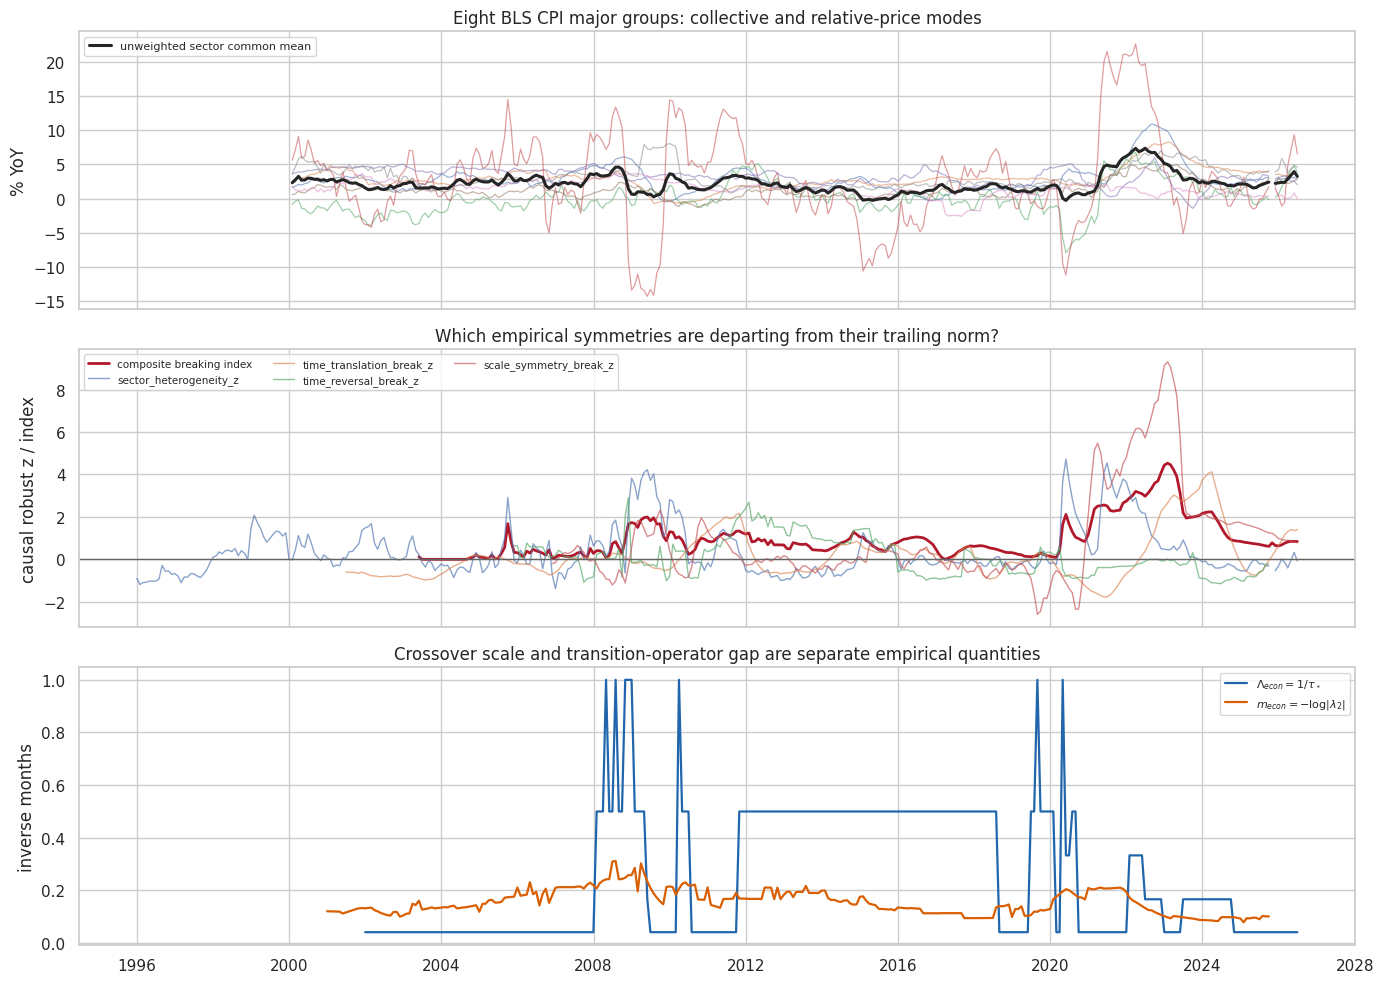

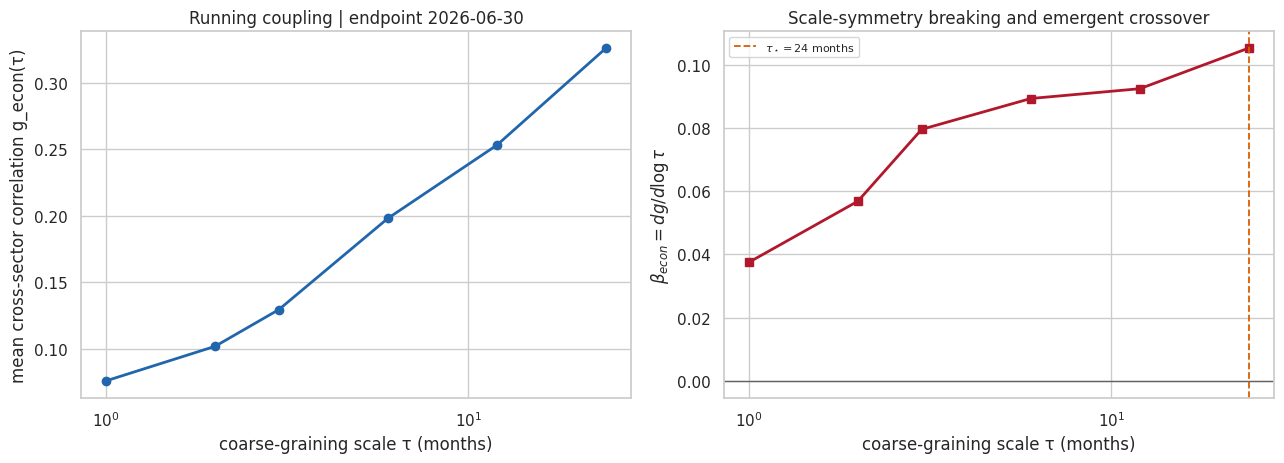

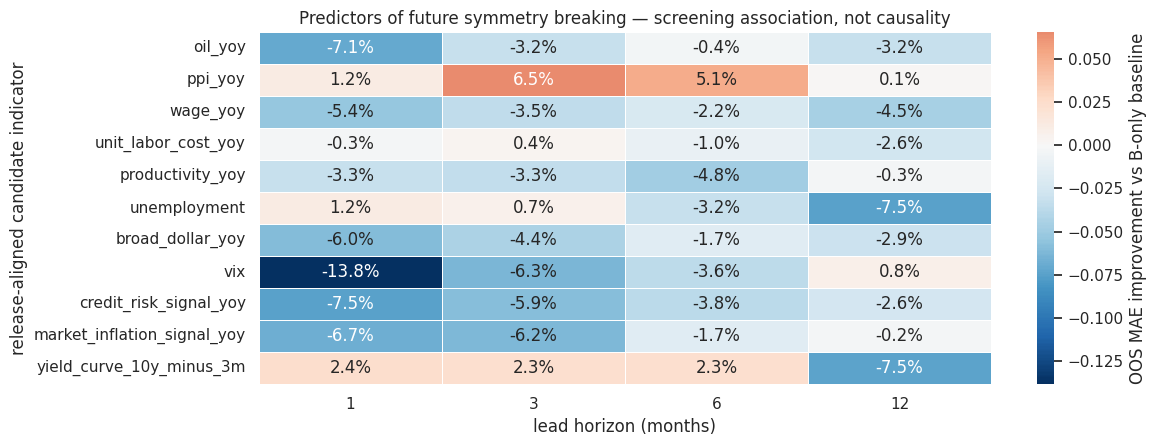

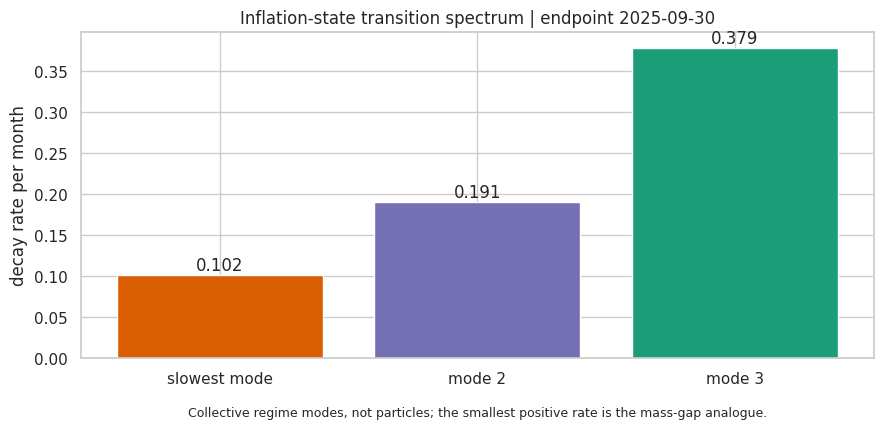

In [ ]:
# Figure 8 — sector symmetry and aggregate breaking order parameter.
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
_plot_start = max(pd.Timestamp("2000-01-31"), sector_yoy.index.min())
for column in sector_yoy.columns:
    axes[0].plot(
        sector_yoy.loc[_plot_start:, column].index,
        sector_yoy.loc[_plot_start:, column],
        lw=.9, alpha=.55,
    )
axes[0].plot(
    sector_common_mean.loc[_plot_start:].index,
    sector_common_mean.loc[_plot_start:],
    color="#252525", lw=2.2, label="unweighted sector common mean",
)
axes[0].set_ylabel("% YoY")
axes[0].set_title("Eight BLS CPI major groups: collective and relative-price modes")
axes[0].legend(fontsize=8)

axes[1].plot(
    symmetry_metrics.index,
    symmetry_metrics["symmetry_breaking_index"],
    color="#b2182b", lw=2.0, label="composite breaking index",
)
for column in [
    "sector_heterogeneity_z",
    "time_translation_break_z",
    "time_reversal_break_z",
    "scale_symmetry_break_z",
]:
    if column in symmetry_metrics:
        axes[1].plot(
            symmetry_metrics.index,
            symmetry_metrics[column],
            lw=1.0, alpha=.65, label=column,
        )
axes[1].axhline(0, color="#636363", lw=1)
axes[1].set_ylabel("causal robust z / index")
axes[1].set_title("Which empirical symmetries are departing from their trailing norm?")
axes[1].legend(fontsize=7.5, ncol=3)

axes[2].plot(
    economic_scales.index,
    economic_scales["lambda_econ_per_month"],
    color="#2166ac", lw=1.6, label=r"$\Lambda_{econ}=1/\tau_\star$",
)
axes[2].plot(
    economic_scales.index,
    economic_scales["mass_gap_analog_per_month"],
    color="#d95f02", lw=1.6, label=r"$m_{econ}=-\log|\lambda_2|$",
)
axes[2].set_ylabel("inverse months")
axes[2].set_title(
    "Crossover scale and transition-operator gap are separate empirical quantities"
)
axes[2].legend(fontsize=8)
fig.tight_layout()
save_presentation_figure(fig, "presentation_08_symmetry_order_parameters.png")
plt.show()


# Figure 9 — running coupling and beta at the latest complete multiscale endpoint.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
if not multiscale_coupling_metrics.empty:
    _latest_scale_date = multiscale_coupling_metrics.index.max()
    _scale_block = sector_yoy.loc[:_latest_scale_date].tail(ECONOMIC_RG_WINDOW)
    latest_coupling_curve = multiscale_coupling_curve(
        _scale_block,
        ECONOMIC_SCALES_MONTHS,
        min_complete=max(48, ECONOMIC_RG_WINDOW // 2),
    )
    axes[0].plot(
        latest_coupling_curve["scale_months"],
        latest_coupling_curve["coupling"],
        marker="o", lw=2, color="#2166ac",
    )
    axes[0].set_xscale("log")
    axes[0].set_xlabel("coarse-graining scale τ (months)")
    axes[0].set_ylabel("mean cross-sector correlation g_econ(τ)")
    axes[0].set_title(f"Running coupling | endpoint {_latest_scale_date.date()}")
    axes[1].plot(
        latest_coupling_curve["scale_months"],
        latest_coupling_curve["beta_econ"],
        marker="s", lw=2, color="#b2182b",
    )
    axes[1].axhline(0, color="#636363", lw=1)
    _tau = float(
        multiscale_coupling_metrics.loc[
            _latest_scale_date, "crossover_scale_months"
        ]
    )
    axes[1].axvline(
        _tau, color="#d95f02", ls="--", lw=1.3,
        label=fr"$\tau_\star={_tau:g}$ months",
    )
    axes[1].set_xscale("log")
    axes[1].set_xlabel("coarse-graining scale τ (months)")
    axes[1].set_ylabel(r"$\beta_{econ}=dg/d\log\tau$")
    axes[1].set_title("Scale-symmetry breaking and emergent crossover")
    axes[1].legend(fontsize=8)
else:
    latest_coupling_curve = pd.DataFrame()
    for ax in axes:
        ax.text(.5, .5, "No complete multiscale window", ha="center", va="center")
fig.tight_layout()
save_presentation_figure(fig, "presentation_09_economic_running_coupling.png")
plt.show()


# Figure 10 — candidate indicators that lead the breaking index out of sample.
fig, ax = plt.subplots(figsize=(12, max(4.5, .42 * max(1, len(TRIGGER_CANDIDATES)))))
if not trigger_screen_summary.empty:
    _trigger_heat = trigger_screen_summary.pivot(
        index="feature", columns="horizon", values="relative_mae_improvement"
    ).reindex(TRIGGER_CANDIDATES)
    sns.heatmap(
        _trigger_heat,
        cmap="RdBu_r",
        center=0,
        annot=True,
        fmt=".1%",
        linewidths=.4,
        cbar_kws={"label": "OOS MAE improvement vs B-only baseline"},
        ax=ax,
    )
    ax.set_xlabel("lead horizon (months)")
    ax.set_ylabel("release-aligned candidate indicator")
    ax.set_title(
        "Predictors of future symmetry breaking — screening association, not causality"
    )
else:
    ax.text(.5, .5, "No trigger candidate met the expanding-window sample rule", ha="center", va="center")
    ax.set_axis_off()
fig.tight_layout()
save_presentation_figure(fig, "presentation_10_symmetry_trigger_screen.png")
plt.show()


# Figure 11 — finite collective relaxation modes, the closest glueball-spectrum analogy.
fig, ax = plt.subplots(figsize=(9, 4.5))
_complete_markov_modes = (
    markov_spectrum.dropna(
        subset=["mode_1_rate", "mode_2_rate", "mode_3_rate"]
    )
    if not markov_spectrum.empty else pd.DataFrame()
)
if not _complete_markov_modes.empty:
    _latest_markov = _complete_markov_modes.iloc[-1]
    _mode_values = [
        _latest_markov["mode_1_rate"],
        _latest_markov["mode_2_rate"],
        _latest_markov["mode_3_rate"],
    ]
    bars = ax.bar(
        ["slowest mode", "mode 2", "mode 3"],
        _mode_values,
        color=["#d95f02", "#7570b3", "#1b9e77"],
    )
    ax.bar_label(bars, fmt="%.3f")
    ax.set_ylabel("decay rate per month")
    ax.set_title(
        f"Inflation-state transition spectrum | endpoint {markov_spectrum.index[-1].date()}"
    )
    ax.text(
        .5, -.18,
        "Collective regime modes, not particles; the smallest positive rate is the mass-gap analogue.",
        transform=ax.transAxes, ha="center", fontsize=9,
    )
else:
    ax.text(.5, .5, "No complete Markov window", ha="center", va="center")
    ax.set_axis_off()
fig.tight_layout()
save_presentation_figure(fig, "presentation_11_collective_mode_spectrum.png")
plt.show()


## 12. Run-scoped 산출물과 prospective commitment

각 실행의 표·그림·manifest는 `research_artifacts/<RUN_ID>/`에 분리한다.
예측은 `forecast_commitment_<RUN_ID>.json`에 canonical JSON으로 최초 한 번만 쓰며,
body SHA-256과 직전 파일 SHA-256을 연결한다. 기존 파일의 바이트가 다르면 덮어쓰지 않고
중단한다.

`live_forecast_registry.csv`는 commitment들을 읽어 최초 authoritative record만 남겨
매번 재생성하는 **파생 index**다. 같은 권위 key의 다른 예측은 conflict log로 격리한다.
실현치는 commitment를 수정하지 않고 별도 outcome ledger와 scorecard에 결합한다.

이 연결고리는 로컬 tamper-evidence이지 디지털 서명이나 외부 불변 원장이 아니다.
`/content`는 일시적이므로 `CFG.use_google_drive=False` 실행은 prospective 증거로
인정하지 않는다. Drive를 쓰더라도 application-level write-once일 뿐 암호학적 불변성을
주장하지 않는다.


In [ ]:
def package_version(name: str) -> Optional[str]:
    try:
        return importlib_metadata.version(name)
    except importlib_metadata.PackageNotFoundError:
        return None


def json_safe(value):
    if isinstance(value, dict):
        return {str(k): json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_safe(v) for v in value]
    if isinstance(value, np.generic):
        value = value.item()
    if isinstance(value, float) and not np.isfinite(value):
        return None
    if isinstance(value, (pd.Timestamp, datetime, Path)):
        return str(value)
    if pd.isna(value) if not isinstance(value, (str, bytes, bool, int)) else False:
        return None
    return value


def canonical_json_bytes(value) -> bytes:
    return json.dumps(
        json_safe(value),
        ensure_ascii=False,
        sort_keys=True,
        separators=(",", ":"),
        allow_nan=False,
    ).encode("utf-8")


def commitment_body_sha256(body: dict) -> str:
    return sha256_bytes(canonical_json_bytes(body))


def verify_commitment_chain(commitment_dir: Path) -> pd.DataFrame:
    columns = [
        "file", "sequence_number", "file_sha256", "body_hash_valid",
        "previous_link_valid", "sequence_valid", "valid", "error",
    ]
    rows = []
    expected_previous_sha = None
    expected_sequence = 1
    for path in sorted(commitment_dir.glob("forecast_commitment_*.json")):
        raw = path.read_bytes()
        file_sha = sha256_bytes(raw)
        try:
            envelope = json.loads(raw)
            body = envelope["body"]
            sequence = int(body["sequence_number"])
            body_hash_ok = (
                envelope["body_sha256"] == commitment_body_sha256(body)
            )
            link_ok = (
                body.get("previous_commitment_sha256")
                == expected_previous_sha
            )
            sequence_ok = sequence == expected_sequence
            valid = bool(body_hash_ok and link_ok and sequence_ok)
            error = None
        except Exception as exc:
            body_hash_ok = link_ok = sequence_ok = valid = False
            sequence = np.nan
            error = f"{type(exc).__name__}: {exc}"
        rows.append({
            "file": path.name,
            "sequence_number": sequence,
            "file_sha256": file_sha,
            "body_hash_valid": body_hash_ok,
            "previous_link_valid": link_ok,
            "sequence_valid": sequence_ok,
            "valid": valid,
            "error": error,
        })
        expected_previous_sha = file_sha
        expected_sequence += 1
    return pd.DataFrame(rows, columns=columns)


def target_outcome_status(
    target_month: pd.Timestamp,
    target: str,
    level_df: pd.DataFrame,
    target_df: pd.DataFrame,
) -> Tuple[float, str]:
    level_column = TARGET_TO_LEVEL[target]
    target_month = pd.Timestamp(target_month).to_period("M").to_timestamp(how="end").normalize()
    base_month = month_add(target_month, -12)
    level_series = level_df[level_column]
    base_value = level_series.get(base_month, np.nan)
    numerator_value = level_series.get(target_month, np.nan)
    last_level_month = level_series.last_valid_index()
    if not np.isfinite(base_value):
        return np.nan, "permanently_unscorable_missing_12m_base"
    if last_level_month is None or target_month > last_level_month:
        return np.nan, "pending_target_release"
    if not np.isfinite(numerator_value):
        return np.nan, "permanently_unscorable_missing_target_level"
    actual = target_df[target].get(target_month, np.nan)
    if not np.isfinite(actual):
        return np.nan, "target_unavailable_after_release"
    return float(actual), "realized"


source_hashes = {
    key: meta.get("sha256") for key, meta in source_meta.items()
}
protocol_definition = {
    "research_protocol_version": CFG.research_protocol_version,
    "target_protocol_version": CFG.target_protocol_version,
    "target_gap_policy": "complete_calendar_native_nan_no_positional_compression",
    "chronos_target_gap_policy": "native_nan_mask",
    "chronos_covariate_policy": (
        "macro_h1_issue_month_only_else_nan+calendar_known_all_horizons"
    ),
    "selection": "DEV-only equal-origin-weight horizon-band common-grid",
    "locked_use": "descriptive_only_no_switching",
    "live_interval": "rolling_past_only_marginal_conformal",
}
protocol_sha256 = sha256_bytes(canonical_json_bytes(protocol_definition))
config_sha256 = sha256_bytes(canonical_json_bytes(asdict(CFG)))

manifest = {
    "run_id": RUN_ID,
    "run_utc": RUN_UTC.isoformat(),
    "as_of_date": str(AS_OF_DATE.date()),
    "as_of_timezone": AS_OF_TIMEZONE,
    "objective": "US headline/core CPI current-month nowcast and 12-month forecast",
    "research_protocol_version": CFG.research_protocol_version,
    "target_protocol_version": CFG.target_protocol_version,
    "protocol_sha256": protocol_sha256,
    "config_sha256": config_sha256,
    "protocol_amended_after_prior_locked_inspection": True,
    "strict_ex_ante_claim_allowed": False,
    "locked_used_for_model_selection": False,
    "locked_used_for_model_switching": False,
    "prospective_validation_status": "pending",
    "superseded_runs": [{
        "run_id": "20260727T093019Z",
        "reason": (
            "invalid target calendar: positional 12-row shift crossed the "
            "missing October-2025 CPI level"
        ),
    }],
    "vintage_status": {
        "overall": "current-vintage pseudo-real-time; not strict real-time",
        "bls": "current published history, not origin-by-origin vintage archive",
        "yahoo": "download-time adjusted-price snapshot; historical adjustments may revise",
        "world_bank": (
            "current/revised annual history; excluded from operational predictive panel"
        ),
    },
    "authentication_required": False,
    "pretraining_contamination_caveat": (
        "Chronos-2 pretraining exclusion of all evaluated macro series is not established; "
        "historical results are not clean ex-ante OOS evidence."
    ),
    "model_id": CFG.model_id,
    "model_revision_sha": CHRONOS_MODEL_SHA,
    "chronos_load_error": chronos_load_error,
    "chronos_native_nan_supported": CHRONOS_NATIVE_NAN_SUPPORTED,
    "chronos_nan_probe_message": CHRONOS_NAN_PROBE_MESSAGE,
    "chronos_feature_schema_sha256": CHRONOS_FEATURE_SCHEMA_SHA,
    "chronos_target_gap_policy": "native_nan_mask",
    "chronos_covariate_policy": (
        "macro_h1_issue_month_only_else_nan+calendar_known_all_horizons"
    ),
    "chronos_backtest_origin_success_rate": CHRONOS_BACKTEST_SUCCESS_RATE,
    "chronos_cell_coverage_by_split": CHRONOS_CELL_COVERAGE_BY_SPLIT,
    "chronos_gap_stress_passed": CHRONOS_GAP_STRESS_PASSED,
    "chronos_gap_stress_summary": {
        "n_origins": (
            int(chronos_gap_stress_audit["origin"].nunique())
            if not chronos_gap_stress_audit.empty else 0
        ),
        "median_abs_q50_shift": (
            float(chronos_gap_stress_audit["abs_q50_shift"].median())
            if not chronos_gap_stress_audit.empty else None
        ),
        "median_interval_width_ratio": (
            float(chronos_gap_stress_audit["interval_width_ratio"].median())
            if not chronos_gap_stress_audit.empty else None
        ),
    },
    "best_classical_components_dev": BEST_CLASSICAL_BY_BAND,
    "research_components_dev": RESEARCH_BAND_COMPONENTS,
    "research_recipe": RESEARCH_RECIPE,
    "live_requested_recipe": LIVE_REQUESTED_RECIPE,
    "live_deployed_recipe": LIVE_DEPLOYED_RECIPE,
    "live_deployed_components": LIVE_DEPLOYED_COMPONENTS,
    "live_fallback_reasons": LIVE_FALLBACK_REASONS,
    "live_model_fallback_triggered": LIVE_MODEL_FALLBACK_TRIGGERED,
    "live_chronos_available": LIVE_CHRONOS_AVAILABLE,
    "live_chronos_validation": LIVE_CHRONOS_VALIDATION_MESSAGE,
    "live_forecast_validation": live_validation_message,
    "last_published_target_month": str(last_target_month.date()),
    "current_nowcast_month": str(current_origin.date()),
    "information_cutoff_date": str(AS_OF_DATE.date()),
    "target_definition": (
        "BLS CUUR0000SA0 and CUUR0000SA0L1E exact same-calendar-month "
        "12-month percent change (NSA)"
    ),
    "target_gap_months": [str(stamp.date()) for stamp in target_gap_months],
    "structurally_unscorable_forecast_cells": (
        final_forecast.loc[
            ~final_forecast["official_target_observable"],
            ["target_month", "target", "horizon", "base_month", "base_status"],
        ].to_dict(orient="records")
    ),
    "feature_columns": list(feature_panel.columns),
    "world_bank_predictive_use": False,
    "config": asdict(CFG),
    "source_sha256": source_hashes,
    "partial_month_audit": partial_month_audit.to_dict(orient="records"),
    "presentation_figures": {
        name: Path(path).name for name, path in presentation_figures.items()
    },
    "symmetry_diagnostic": {
        "interpretation": (
            "Inflation is an observable, not the mass gap. "
            "The primary gap analogue is the inverse decay time from the "
            "second eigenvalue of a coarse-grained transition operator."
        ),
        "symmetries": symmetry_dictionary.to_dict(orient="records"),
        "sector_cpi_series": {
            spec.key: spec.source_id for spec in SYMMETRY_SECTOR_SPECS
        },
        "sector_series_used": list(sector_yoy.columns),
        "numeraire_invariance_max_error": NUMERAIRE_INVARIANCE_MAX_ERROR,
        "economic_running_coupling": (
            "mean pairwise correlation of sector-inflation increments at scale tau"
        ),
        "beta_definition": "d g_econ / d log(tau)",
        "lambda_econ_definition": "1 / argmax_tau |beta_econ(tau)|",
        "mass_gap_analog_definition": "-log(abs(lambda_2(K))) per month",
        "glueball_analogy": (
            "nontrivial collective regime relaxation modes; not particles"
        ),
        "order_parameter_components": list(order_parameter_raw.columns),
        "order_parameter_composite": (
            "root-mean-square of positive causal trailing robust z-scores; "
            "requires at least three components"
        ),
        "trigger_screen": (
            "expanding-window incremental OOS MAE versus B-only autoregression; "
            "screening association, not causal identification"
        ),
        "trigger_candidates": TRIGGER_CANDIDATES,
        "financial_no_arbitrage_symmetry": (
            "conceptual only; synchronized tradable high-frequency data required"
        ),
        "physical_yang_mills_claim": False,
    },
    "relaxation_diagnostic": {
        "primary_variant": "strict_observed_targets_no_bridge",
        "signed_rate_definition": "-log(spectral_radius)",
        "unstable_values_clipped_to_zero": False,
        "positive_gap_defined_only_when_rho_below_one": True,
        "bridge_variant": "research_only_sensitivity",
        "bridge_dependency_rule": "imputed level g affects YoY g and g+12",
        "state_columns": RELAXATION_STATE,
        "window_grid": list(RELAXATION_WINDOWS),
        "ridge_alpha_grid": list(RELAXATION_RIDGE_ALPHAS),
        "bootstrap_audit": relaxation_bootstrap_audit,
        "physical_mass_gap_claim": False,
    },
    "prospective_evidence": {
        "storage_persistent": bool(CFG.use_google_drive),
        "status": (
            "local_tamper_evident_prospective_record"
            if CFG.use_google_drive
            else "ephemeral_not_prospective_evidence"
        ),
        "cryptographically_signed": False,
        "registry_is_derived_index": True,
        "commitments_are_application_write_once": True,
    },
    "packages": {
        "python": platform.python_version(),
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "scikit-learn": sklearn.__version__,
        "torch": torch.__version__,
        "chronos-forecasting": package_version("chronos-forecasting"),
        "huggingface-hub": package_version("huggingface-hub"),
        "transformers": package_version("transformers"),
        "yfinance": package_version("yfinance"),
        "pyarrow": package_version("pyarrow"),
    },
    "hardware": {
        "cuda_available": torch.cuda.is_available(),
        "torch_cuda_version": torch.version.cuda,
        "gpu_name": (
            torch.cuda.get_device_name(0) if torch.cuda.is_available() else None
        ),
        "gpu_capability": (
            ".".join(map(str, torch.cuda.get_device_capability(0)))
            if torch.cuda.is_available() else None
        ),
    },
}

paths = {
    "source_audit": ARTIFACT_DIR / "source_audit.csv",
    "feature_audit": ARTIFACT_DIR / "feature_availability_audit.csv",
    "high_frequency_protocol": ARTIFACT_DIR / "high_frequency_protocol_audit.csv",
    "targets": ARTIFACT_DIR / "inflation_targets_current_vintage.csv",
    "target_gaps": ARTIFACT_DIR / "target_gap_audit.csv",
    "observability": ARTIFACT_DIR / "forecast_target_observability.csv",
    "symmetry_dictionary": ARTIFACT_DIR / "symmetry_dictionary.csv",
    "sector_yoy": ARTIFACT_DIR / "cpi_major_group_yoy.csv",
    "symmetry_base": ARTIFACT_DIR / "symmetry_base_metrics.csv",
    "symmetry_metrics": ARTIFACT_DIR / "symmetry_order_parameters.csv",
    "multiscale_coupling": ARTIFACT_DIR / "economic_running_coupling.csv",
    "latest_coupling_curve": ARTIFACT_DIR / "latest_running_coupling_curve.csv",
    "markov_spectrum": ARTIFACT_DIR / "inflation_markov_spectrum.csv",
    "economic_scales": ARTIFACT_DIR / "economic_crossover_and_gap_scales.csv",
    "trigger_predictions": ARTIFACT_DIR / "symmetry_trigger_oos_predictions.csv",
    "trigger_screen": ARTIFACT_DIR / "symmetry_trigger_screen.csv",
    "trigger_ranking": ARTIFACT_DIR / "symmetry_trigger_ranking.csv",
    "splits": ARTIFACT_DIR / "split_origin_audit.csv",
    "backtest": ARTIFACT_DIR / "backtest_predictions.csv",
    "metrics": ARTIFACT_DIR / "metrics_by_target_horizon.csv",
    "aggregate_metrics": ARTIFACT_DIR / "aggregate_metrics.csv",
    "selection": ARTIFACT_DIR / "model_selection_audit.csv",
    "conformal": ARTIFACT_DIR / "conformal_widths.csv",
    "locked_conformal": ARTIFACT_DIR / "locked_test_conformal_coverage.csv",
    "gap_stress": ARTIFACT_DIR / "chronos_gap_stress_audit.csv",
    "final": ARTIFACT_DIR / "final_inflation_forecast.csv",
    "relaxation_strict": ARTIFACT_DIR / "relaxation_proxy_strict.csv",
    "relaxation_bridge": ARTIFACT_DIR / "relaxation_proxy_bridge_sensitivity.csv",
    "relaxation_grid": ARTIFACT_DIR / "relaxation_sensitivity_grid.csv",
    "bridge_dependency": ARTIFACT_DIR / "bridge_dependency_audit.csv",
    "manifest": ARTIFACT_DIR / "run_manifest.json",
    "readme": ARTIFACT_DIR / "README.md",
}


def write_frame(frame: pd.DataFrame, path: Path, **kwargs) -> None:
    frame.to_csv(path, index=False, **kwargs)


write_frame(source_audit, paths["source_audit"])
write_frame(feature_audit, paths["feature_audit"])
write_frame(high_frequency_protocol_audit, paths["high_frequency_protocol"])
targets.reset_index(names="observation_month").to_csv(paths["targets"], index=False)
target_gap_audit.reset_index().to_csv(paths["target_gaps"], index=False)
write_frame(forecast_observability, paths["observability"])
write_frame(symmetry_dictionary, paths["symmetry_dictionary"])
write_frame(
    sector_yoy.rename_axis("observation_month").reset_index(),
    paths["sector_yoy"],
)
write_frame(
    symmetry_base_metrics.rename_axis("date").reset_index(),
    paths["symmetry_base"],
)
write_frame(
    symmetry_metrics.rename_axis("date").reset_index(),
    paths["symmetry_metrics"],
)
write_frame(
    multiscale_coupling_metrics.rename_axis("date").reset_index(),
    paths["multiscale_coupling"],
)
write_frame(latest_coupling_curve, paths["latest_coupling_curve"])
write_frame(
    markov_spectrum.rename_axis("date").reset_index(),
    paths["markov_spectrum"],
)
write_frame(
    economic_scales.rename_axis("date").reset_index(),
    paths["economic_scales"],
)
write_frame(trigger_predictions, paths["trigger_predictions"])
write_frame(trigger_screen_summary, paths["trigger_screen"])
write_frame(trigger_ranking, paths["trigger_ranking"])
write_frame(split_origin_audit, paths["splits"])
write_frame(bt, paths["backtest"])
write_frame(metrics, paths["metrics"])
write_frame(aggregate_metrics, paths["aggregate_metrics"])
write_frame(selection_table, paths["selection"])
write_frame(conformal_export, paths["conformal"])
write_frame(locked_conformal_coverage, paths["locked_conformal"])
write_frame(chronos_gap_stress_audit, paths["gap_stress"])
write_frame(final_forecast, paths["final"])
spectral_proxy_strict.reset_index().to_csv(paths["relaxation_strict"], index=False)
spectral_proxy_bridge.reset_index().to_csv(paths["relaxation_bridge"], index=False)
write_frame(relaxation_sensitivity_grid, paths["relaxation_grid"])
write_frame(bridge_dependency_audit, paths["bridge_dependency"])

private_feature_panel_path = (
    OUTPUT_DIR / f"release_aligned_feature_panel_private_yahoo_{RUN_ID}.csv"
)
feature_panel.to_csv(
    private_feature_panel_path, index_label="availability_month"
)

# Create a write-once, hash-linked forecast commitment.
commitment_path = COMMITMENT_DIR / f"forecast_commitment_{RUN_ID}.json"
existing_other = sorted(
    path for path in COMMITMENT_DIR.glob("forecast_commitment_*.json")
    if path != commitment_path
)
if existing_other:
    _pre_chain = verify_commitment_chain(COMMITMENT_DIR)
    _pre_chain = _pre_chain.loc[_pre_chain["file"] != commitment_path.name]
    if not _pre_chain.empty and not _pre_chain["valid"].all():
        display(_pre_chain)
        raise RuntimeError("Existing forecast commitment chain is invalid")
previous_file_sha256 = (
    sha256_bytes(existing_other[-1].read_bytes()) if existing_other else None
)

commitment_fields = [
    "run_id", "as_of_date", "origin", "target_month", "target", "horizon",
    "forecast_type", "requested_recipe", "requested_component",
    "deployed_recipe", "deployed_component", "model_output_yoy", "forecast_yoy",
    "lower80_conformal", "upper80_conformal", "interval_method",
    "n_calibration", "official_target_observable", "forecast_status",
    "score_eligible", "target_protocol_version",
]
forecast_records = json_safe(
    final_forecast.sort_values(["target", "horizon"])[commitment_fields]
    .to_dict(orient="records")
)
commitment_body = {
    "schema_version": "inflation-forecast-commitment/2.0",
    "sequence_number": len(existing_other) + 1,
    "run_id": RUN_ID,
    "recorded_at_utc": RUN_UTC.isoformat(),
    "as_of_date": str(AS_OF_DATE.date()),
    "origin": str(current_origin.date()),
    "target_protocol_version": CFG.target_protocol_version,
    "research_protocol_version": CFG.research_protocol_version,
    "protocol_sha256": protocol_sha256,
    "config_sha256": config_sha256,
    "source_sha256": source_hashes,
    "model_id": CFG.model_id,
    "model_revision_sha": CHRONOS_MODEL_SHA,
    "storage_status": (
        "persistent_application_guarded_hash_chain"
        if CFG.use_google_drive else "ephemeral_not_prospective_evidence"
    ),
    "previous_commitment_sha256": previous_file_sha256,
    "forecast_payload_sha256": sha256_bytes(
        canonical_json_bytes(forecast_records)
    ),
    "forecasts": forecast_records,
}
commitment_envelope = {
    "body": commitment_body,
    "body_sha256": commitment_body_sha256(commitment_body),
}
candidate_bytes = canonical_json_bytes(commitment_envelope) + b"\n"
if commitment_path.exists():
    if commitment_path.read_bytes() != candidate_bytes:
        raise RuntimeError(
            "Existing immutable commitment differs from this run; refusing overwrite"
        )
else:
    with commitment_path.open("xb") as handle:
        handle.write(candidate_bytes)

chain_audit = verify_commitment_chain(COMMITMENT_DIR)
if chain_audit.empty or not chain_audit["valid"].all():
    display(chain_audit)
    raise RuntimeError("Forecast commitment chain validation failed")
chain_audit_path = ARTIFACT_DIR / "forecast_commitment_chain_audit.csv"
write_frame(chain_audit, chain_audit_path)
(ARTIFACT_DIR / commitment_path.name).write_bytes(commitment_path.read_bytes())


def build_registry_from_commitments(
    commitment_dir: Path,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    authoritative, conflicts, seen = [], [], {}
    for path in sorted(commitment_dir.glob("forecast_commitment_*.json")):
        raw = path.read_bytes()
        envelope = json.loads(raw)
        body = envelope["body"]
        for record in body.get("forecasts", []):
            row = {
                **record,
                "commitment_run_id": body["run_id"],
                "recorded_at_utc": body["recorded_at_utc"],
                "commitment_file": path.name,
                "commitment_file_sha256": sha256_bytes(raw),
            }
            key = (
                str(record.get("as_of_date")),
                str(record.get("origin")),
                str(record.get("target")),
                int(record.get("horizon")),
                str(record.get("target_protocol_version")),
            )
            compare_record = {
                k: v for k, v in record.items() if k != "run_id"
            }
            compare_hash = sha256_bytes(canonical_json_bytes(compare_record))
            if key not in seen:
                seen[key] = {
                    "compare_hash": compare_hash,
                    "file": path.name,
                }
                authoritative.append(row)
            else:
                identical = compare_hash == seen[key]["compare_hash"]
                conflicts.append({
                    "key": repr(key),
                    "first_authoritative_file": seen[key]["file"],
                    "later_file": path.name,
                    "status": (
                        "duplicate_identical"
                        if identical
                        else "duplicate_conflict_non_authoritative"
                    ),
                })
    return pd.DataFrame(authoritative), pd.DataFrame(
        conflicts,
        columns=[
            "key", "first_authoritative_file", "later_file", "status"
        ],
    )


registry, commitment_conflicts = build_registry_from_commitments(COMMITMENT_DIR)
registry_path = OUTPUT_DIR / "live_forecast_registry.csv"
registry.to_csv(registry_path, index=False)
registry_snapshot_path = ARTIFACT_DIR / "live_forecast_registry_derived_snapshot.csv"
registry.to_csv(registry_snapshot_path, index=False)
conflict_path = ARTIFACT_DIR / "forecast_commitment_conflicts.csv"
commitment_conflicts.to_csv(conflict_path, index=False)

# Outcomes are evaluated in a separate derived ledger; commitments remain untouched.
ledger_rows = []
for _, row in registry.iterrows():
    actual, outcome_status = target_outcome_status(
        pd.Timestamp(row["target_month"]),
        str(row["target"]),
        target_levels,
        targets,
    )
    forecast = pd.to_numeric(
        pd.Series([row.get("forecast_yoy")]), errors="coerce"
    ).iloc[0]
    lower = pd.to_numeric(
        pd.Series([row.get("lower80_conformal")]), errors="coerce"
    ).iloc[0]
    upper = pd.to_numeric(
        pd.Series([row.get("upper80_conformal")]), errors="coerce"
    ).iloc[0]
    realized = outcome_status == "realized" and np.isfinite(forecast)
    ledger_rows.append({
        "commitment_file_sha256": row.get("commitment_file_sha256"),
        "run_id": row.get("commitment_run_id"),
        "recorded_at_utc": row.get("recorded_at_utc"),
        "as_of_date": row.get("as_of_date"),
        "origin": row.get("origin"),
        "target_month": row.get("target_month"),
        "target": row.get("target"),
        "horizon": row.get("horizon"),
        "deployed_model": row.get("deployed_component"),
        "forecast_yoy": forecast if np.isfinite(forecast) else np.nan,
        "lower80_conformal": lower if np.isfinite(lower) else np.nan,
        "upper80_conformal": upper if np.isfinite(upper) else np.nan,
        "actual_yoy": actual,
        "error": forecast - actual if realized else np.nan,
        "abs_error": abs(forecast - actual) if realized else np.nan,
        "interval_hit": (
            bool(lower <= actual <= upper)
            if realized and np.isfinite(lower) and np.isfinite(upper) else np.nan
        ),
        "outcome_status": outcome_status,
        "evaluated_at_utc": datetime.now(timezone.utc).isoformat(),
        "actual_vintage_status": (
            "current_published_history_at_evaluation_not_release_vintage"
        ),
    })
ledger_columns = [
    "commitment_file_sha256", "run_id", "recorded_at_utc", "as_of_date",
    "origin", "target_month", "target", "horizon", "deployed_model",
    "forecast_yoy", "lower80_conformal", "upper80_conformal", "actual_yoy",
    "error", "abs_error", "interval_hit", "outcome_status",
    "evaluated_at_utc", "actual_vintage_status",
]
forecast_outcome_ledger = pd.DataFrame(ledger_rows, columns=ledger_columns)
ledger_path = ARTIFACT_DIR / "forecast_outcome_ledger.csv"
forecast_outcome_ledger.to_csv(ledger_path, index=False)
_realized_ledger = forecast_outcome_ledger.loc[
    forecast_outcome_ledger["outcome_status"].eq("realized")
]
if _realized_ledger.empty:
    prospective_scorecard = pd.DataFrame(
        columns=["target", "deployed_model", "n", "MAE", "bias", "coverage80"]
    )
else:
    prospective_scorecard = (
        _realized_ledger.groupby(["target", "deployed_model"], dropna=False)
        .agg(
            n=("abs_error", "size"),
            MAE=("abs_error", "mean"),
            bias=("error", "mean"),
            coverage80=("interval_hit", "mean"),
        )
        .reset_index()
    )
scorecard_path = ARTIFACT_DIR / "prospective_scorecard.csv"
prospective_scorecard.to_csv(scorecard_path, index=False)

manifest["prospective_registry"] = {
    "commitment_path": str(commitment_path),
    "commitment_file_sha256": sha256_bytes(commitment_path.read_bytes()),
    "previous_commitment_sha256": previous_file_sha256,
    "sequence_number": commitment_body["sequence_number"],
    "chain_all_valid": bool(chain_audit["valid"].all()),
    "derived_registry_path": str(registry_path),
    "derived_registry_snapshot_path": str(registry_snapshot_path),
    "duplicate_conflict_rows": int(
        commitment_conflicts["status"].eq(
            "duplicate_conflict_non_authoritative"
        ).sum()
    ) if not commitment_conflicts.empty else 0,
    "outcome_ledger_path": str(ledger_path),
    "registry_is_immutable_evidence": False,
    "commitments_are_digitally_signed": False,
}

# Independent chain regression test: tampering must invalidate body and successor link.
with TemporaryDirectory() as _chain_test_dir:
    _td = Path(_chain_test_dir)
    _previous = None
    for _seq in (1, 2):
        _body = {
            "sequence_number": _seq,
            "previous_commitment_sha256": _previous,
            "forecasts": [],
        }
        _env = {
            "body": _body,
            "body_sha256": commitment_body_sha256(_body),
        }
        _raw = canonical_json_bytes(_env) + b"\n"
        _path = _td / f"forecast_commitment_2020010{_seq}T000000Z.json"
        _path.write_bytes(_raw)
        _previous = sha256_bytes(_raw)
    _good = verify_commitment_chain(_td)
    assert _good["valid"].all()
    _first = sorted(_td.glob("forecast_commitment_*.json"))[0]
    _tampered = _first.read_bytes().replace(
        b'"sequence_number":1', b'"sequence_number":9'
    )
    _first.write_bytes(_tampered)
    _bad = verify_commitment_chain(_td)
    assert not _bad["valid"].all()
    assert not bool(_bad.iloc[0]["body_hash_valid"])
    assert not bool(_bad.iloc[1]["previous_link_valid"])
print("Write-once commitment/hash-chain tamper test: PASS")


def _safe_nowcast(target: str) -> Optional[pd.Series]:
    rows = final_forecast.loc[
        final_forecast["target"].eq(target)
        & final_forecast["horizon"].eq(1)
    ]
    return rows.iloc[0] if not rows.empty else None


def _fmt(value, digits=3) -> str:
    return f"{float(value):.{digits}f}" if value is not None and np.isfinite(value) else "N/A"


headline_nowcast = _safe_nowcast("headline_yoy")
core_nowcast = _safe_nowcast("core_yoy")
_locked_rows = aggregate_metrics.loc[
    aggregate_metrics["split"].eq("locked_test")
    & aggregate_metrics["model"].eq(RESEARCH_RECIPE)
]
_locked_text = (
    f"{_locked_rows.iloc[0]['MAE']:.3f} pp across "
    f"{int(_locked_rows.iloc[0]['n_origins'])} origins"
    if not _locked_rows.empty else "not available"
)
_structural_count = int((~final_forecast["official_target_observable"]).sum())
readme_text = f'''# US Inflation Symmetry & Spectral-Gap Lab v3 — run {RUN_ID}

## Live result

- Information date: {AS_OF_DATE.date()}
- DEV-selected components: {RESEARCH_BAND_COMPONENTS}
- Live deployed components: {LIVE_DEPLOYED_COMPONENTS}
- Availability/robustness fallback: {LIVE_MODEL_FALLBACK_TRIGGERED}
- Headline CPI nowcast: {_fmt(headline_nowcast['forecast_yoy'] if headline_nowcast is not None else np.nan)}% YoY
  (80% interval {_fmt(headline_nowcast['lower80_conformal'] if headline_nowcast is not None else np.nan)}
  to {_fmt(headline_nowcast['upper80_conformal'] if headline_nowcast is not None else np.nan)})
- Core CPI nowcast: {_fmt(core_nowcast['forecast_yoy'] if core_nowcast is not None else np.nan)}% YoY
  (80% interval {_fmt(core_nowcast['lower80_conformal'] if core_nowcast is not None else np.nan)}
  to {_fmt(core_nowcast['upper80_conformal'] if core_nowcast is not None else np.nan)})
- Descriptive locked aggregate MAE for the amended recipe: {_locked_text}
- Structurally unscorable exact-YoY forecast cells: {_structural_count}

## Guardrails

1. This is current-vintage pseudo-real-time, not a reconstructed real-time vintage test.
2. Calendar gaps are retained. A forecast whose exact 12-month base is missing is masked from the official forecast and score.
3. Model selection uses DEV only, equal common-grid cells within each origin, and separate horizon bands.
4. Locked results are descriptive because this protocol was amended after prior locked inspection.
5. Live intervals use rolling past-only residuals; their prospective coverage remains pending.
6. Chronos-2 internal NaNs use the native mask and a pinned model revision.
7. The relaxation proxy is exploratory economics, not a physical Yang–Mills mass gap or causal estimate.
8. The local hash chain is tamper-evident but not digitally signed or externally immutable.

## Symmetry and spectral-gap extension

- Inflation itself is not identified with a mass gap.
- The crossover scale is `lambda_econ_per_month = 1/tau_star`.
- The gap analogue is `mass_gap_analog_per_month = -log(abs(lambda_2))`.
- Trigger rankings are expanding-window predictive screens, not causal claims.
- Constant nominal-unit rescaling invariance is checked algebraically.

## Presentation figures

{chr(10).join(f"- {name}" for name in sorted(presentation_figures))}

See `run_manifest.json`, the selection audit, observability table, commitment chain audit,
and outcome ledger for the full evidence trail.
'''
paths["readme"].write_text(readme_text, encoding="utf-8")
paths["manifest"].write_text(
    json.dumps(
        json_safe(manifest),
        indent=2,
        ensure_ascii=False,
        sort_keys=True,
        allow_nan=False,
    ),
    encoding="utf-8",
)

zip_base = OUTPUT_DIR.parent / f"inflation_trigger_lab_v2_{RUN_ID}"
zip_path = Path(
    shutil.make_archive(str(zip_base), "zip", root_dir=ARTIFACT_DIR)
)
artifact_files = sorted(
    path.name for path in ARTIFACT_DIR.iterdir() if path.is_file()
)
print("Saved", len(artifact_files), "run-scoped research artifacts")
print("Private, non-bundled feature panel:", private_feature_panel_path)
print("Write-once commitment:", commitment_path)
print("Derived registry:", registry_path)
print("Bundle:", zip_path)

try:
    from google.colab import files
    files.download(str(zip_path))
except Exception:
    pass


Write-once commitment/hash-chain tamper test: PASS
Saved 60 run-scoped research artifacts
Private, non-bundled feature panel: /content/inflation_symmetry_gap_lab_v3/release_aligned_feature_panel_private_yahoo_20260727T151146Z.csv
Write-once commitment: /content/inflation_symmetry_gap_lab_v3/forecast_commitments/forecast_commitment_20260727T151146Z.json
Derived registry: /content/inflation_symmetry_gap_lab_v3/live_forecast_registry.csv
Bundle: /content/inflation_trigger_lab_v2_20260727T151146Z.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 결과 해석 원칙

이 노트북이 산출하는 것은 세 층으로 분리된다.

1. **예측 결과**: headline/core CPI의 nowcast와 12개월 전망이다. `forecast_yoy`는
   정확한 12개월 전 분모가 존재하는 공식 표적에만 기록된다. 구조적 결측 셀에서는
   `model_output_yoy`만 진단용으로 보존되고 성과평가에서 제외된다.
2. **모형 감사**: DEV 동일 grid의 horizon-band 선택, calibration-only locked 구간,
   live rolling interval, Chronos missing-gap stress를 각각 분리한다. 이전 locked 결과를
   본 뒤 protocol을 수정했으므로 새 확증 주장은 prospective ledger가 쌓인 뒤에만 가능하다.
3. **경제적 relaxation 진단**: 고정 5차원 선형 근사의 spectral radius를 사용한
   탐색적 기술통계다. `signed_decay_rate=-log(rho)`는 수축이면 양수, 폭발이면 음수다.
   이는 양–밀스 질량간극의 수학적 증명이나 물리량 측정이 아니다.

전문가에게 결과를 제시할 때에는 점예측만 떼어내지 말고, 데이터 빈티지 한계,
동일-grid coverage, 예측구간 폭, 구조적 평가 불가능성, prospective 상태를 함께 제시한다.


4. **대칭 진단**: 명목단위 불변성은 정확한 항등식으로 확인하고, 부문교환·시간병진·
   시간반전·척도대칭은 각각 다른 order parameter로 검정한다. 이를 하나의 물리 법칙으로
   합치지 않는다.
5. **척도의 분리**: \(\Lambda_{\rm econ}=1/\tau_\star\)는 running coupling의 crossover,
   \(m_{\rm econ}=-\log|\lambda_2|\)는 전이연산자의 완화율이다. 두 값이 비례하는지는
   데이터가 검정할 가설이지 정의가 아니다.
6. **trigger 표**: oil, PPI, wages, unemployment, dollar, VIX, credit, yield curve 등이
   미래 order parameter를 추가로 예측하는지를 screening한다. 양의 결과도 인과적
   대칭 깨짐의 증명이 아니다.
